# Sarcasm Classification — Complete Pipeline

**Sections**:
1. Setup & Data Preparation
2. TF-IDF + Logistic Regression Baseline
3. Naive Bayes Baseline
4. BERT / DistilBERT Classification
5. Error Analysis & Model Comparison

**Run all cells in order (Runtime → Run all).**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# SETUP — imports, file upload, paths
# ============================================================
from __future__ import annotations
import json, hashlib, random, os, warnings, shutil
from dataclasses import dataclass
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Locate or upload the JSONL data file ─────────────────────────────────
FILENAME = "sarcasm_pairs_step35_clean.jsonl"

def _locate_file(filename: str) -> Path | None:
    """Search for filename in standard local paths. Returns first match or None."""
    candidates = [
        Path("/content") / filename,      # Colab: Files-panel upload or prior session
        Path.cwd() / filename,            # local Jupyter / same dir as notebook
        Path.cwd().parent / filename,     # one level up
        Path("/mnt/data") / filename,     # Kaggle / other cloud envs
    ]
    for p in candidates:
        if p.is_file():
            print(f"Found locally: {p}")
            return p

    content = Path("/content")
    if content.exists():
        for p in content.rglob(filename):
            if p.is_file():
                print(f"Found locally (rglob): {p}")
                return p
    return None

print(f"cwd: {Path.cwd()}")
print(f"files in cwd: {[p.name for p in Path.cwd().iterdir()][:10]}")

DATA_FILE = _locate_file(FILENAME)
if DATA_FILE is None:
    try:
        from google.colab import files as _cf
        print(f"\nFile not found locally. Upload {FILENAME!r}:")
        _up = _cf.upload()
        if not _up:
            raise RuntimeError("No file uploaded.")

        _name = list(_up.keys())[0]
        DATA_FILE = Path("/content") / FILENAME
        if Path(_name) != DATA_FILE:
            shutil.move(_name, str(DATA_FILE))

        print(f"Saved to {DATA_FILE}")
    except ImportError:
        raise FileNotFoundError(
            f"Cannot find {FILENAME!r}. Place it in the same folder as this notebook."
        )

# ── Project root + all output directories ────────────────────────────────
def _find_root(data_file):
    for parent in [data_file.parent] + list(data_file.parents):
        if any((parent / m).exists() for m in ["outputs", "notebooks", "data"]):
            return parent
    return data_file.parent

LOCAL_ROOT = _find_root(DATA_FILE)

# In Colab, write artifacts directly into Google Drive so checkpoints survive
# runtime restarts/disconnects. Change GOOGLE_DRIVE_PROJECT_DIR if needed.
USE_GOOGLE_DRIVE_ARTIFACTS = True
GOOGLE_DRIVE_PROJECT_DIR = "cs4248"

def _resolve_artifact_root(local_root: Path) -> Path:
    if not USE_GOOGLE_DRIVE_ARTIFACTS:
        return local_root

    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive", force_remount=False)
        drive_root = Path("/content/drive/MyDrive") / GOOGLE_DRIVE_PROJECT_DIR
        drive_root.mkdir(parents=True, exist_ok=True)
        print(f"Artifacts will be written to Google Drive: {drive_root}")
        return drive_root
    except Exception as e:
        print(f"[WARNING] Google Drive mount unavailable. Falling back to local root. ({e})")
        return local_root

ROOT = _resolve_artifact_root(LOCAL_ROOT)

OUT_DATASETS  = ROOT / "outputs" / "datasets"
OUT_SPLITS    = ROOT / "outputs" / "splits"
OUT_TFIDF     = ROOT / "outputs" / "classical" / "tfidf_lr"
OUT_NB        = ROOT / "outputs" / "classical" / "naive_bayes"
BERT_OUT      = ROOT / "outputs" / "bert"
REPORTS_DIR   = ROOT / "outputs" / "reports"
SPLITS        = OUT_SPLITS

for d in [OUT_DATASETS, OUT_SPLITS, OUT_TFIDF, OUT_NB, BERT_OUT, REPORTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Data file      : {DATA_FILE}")
print(f"Local root     : {LOCAL_ROOT}")
print(f"Artifact root  : {ROOT}")
print(f"Outputs folder : {ROOT / 'outputs'}")

cwd: /content
files in cwd: ['.config', 'drive', 'sample_data']

File not found locally. Upload 'sarcasm_pairs_step35_clean.jsonl':


Saving sarcasm_pairs_step35_clean (3).jsonl to sarcasm_pairs_step35_clean (3).jsonl
Saved to /content/sarcasm_pairs_step35_clean.jsonl
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifacts will be written to Google Drive: /content/drive/MyDrive/cs4248
Data file      : /content/sarcasm_pairs_step35_clean.jsonl
Local root     : /content
Artifact root  : /content/drive/MyDrive/cs4248
Outputs folder : /content/drive/MyDrive/cs4248/outputs


---
# Part 1 — Data Preparation

# Notebook 01 — Data Preparation

**Purpose**: Parse JSONL dataset, derive binary and type labels, perform audit checks, generate group-safe train/val/test splits.

**Outputs**:
- `outputs/datasets/binary_dataset.csv`
- `outputs/datasets/type_dataset.csv`
- `outputs/splits/train_binary.csv`, `val_binary.csv`, `test_binary.csv`
- `outputs/splits/train_type.csv`, `val_type.csv`, `test_type.csv`
- `outputs/splits/split_metadata.json`

## 1. Load and Validate Raw Data

In [ ]:
REQUIRED_FIELDS = {"original_headline", "generated_headline", "strategy", "type", "model_used", "article_link"}
ALLOWED_TYPES   = {"sarcastic_to_non", "non_to_sarcastic"}
ALLOWED_STRATS  = {"irony", "overstatement", "rhetorical_question", "sarcasm", "satire", "understatement"}

raw_rows = []
errors   = []

with open(DATA_FILE, "r", encoding="utf-8") as f:
    for line_num, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            row = json.loads(line)
        except json.JSONDecodeError as e:
            errors.append((line_num, f"JSON parse error: {e}"))
            continue

        # Schema check
        missing = REQUIRED_FIELDS - set(row.keys())
        if missing:
            errors.append((line_num, f"Missing fields: {missing}"))
            continue

        # Value checks
        if row["type"] not in ALLOWED_TYPES:
            errors.append((line_num, f"Unknown type: {row['type']!r}"))
            continue
        if row["strategy"] not in ALLOWED_STRATS:
            errors.append((line_num, f"Unknown strategy: {row['strategy']!r}"))
            continue

        row["_line_num"] = line_num
        raw_rows.append(row)

print(f"Loaded rows : {len(raw_rows):,}")
print(f"Error rows  : {len(errors)}")
if errors:
    for ln, msg in errors[:5]:
        print(f"  Line {ln}: {msg}")

Loaded rows : 28,570
Error rows  : 0


## 2. Dataset Audit

In [ ]:
# ── Type and Strategy distributions ──────────────────────────────────────────
type_counts     = Counter(r["type"]     for r in raw_rows)
strategy_counts = Counter(r["strategy"] for r in raw_rows)
model_counts    = Counter(r["model_used"] for r in raw_rows)

print("=== Type distribution ===")
for k, v in type_counts.most_common():
    print(f"  {k}: {v:,} ({v/len(raw_rows)*100:.1f}%)")

print("\n=== Strategy distribution ===")
for k, v in strategy_counts.most_common():
    print(f"  {k}: {v:,} ({v/len(raw_rows)*100:.1f}%)")

print("\n=== Model distribution ===")
for k, v in model_counts.most_common():
    print(f"  {k}: {v:,}")

=== Type distribution ===
  non_to_sarcastic: 14,982 (52.4%)
  sarcastic_to_non: 13,588 (47.6%)

=== Strategy distribution ===
  sarcasm: 8,832 (30.9%)
  irony: 6,139 (21.5%)
  satire: 5,250 (18.4%)
  overstatement: 4,010 (14.0%)
  understatement: 3,298 (11.5%)
  rhetorical_question: 1,041 (3.6%)

=== Model distribution ===
  stepfun/step-3.5-flash:free: 28,564
  human/nus-student-camille: 6


In [ ]:
# ── Duplicate checks ──────────────────────────────────────────────────────────
orig_headlines  = [r["original_headline"]  for r in raw_rows]
gen_headlines   = [r["generated_headline"] for r in raw_rows]
article_links   = [r["article_link"]       for r in raw_rows]

dup_orig    = len(orig_headlines) - len(set(orig_headlines))
dup_gen     = len(gen_headlines)  - len(set(gen_headlines))
dup_article = len(article_links)  - len(set(article_links))

print(f"Duplicate original_headlines : {dup_orig}")
print(f"Duplicate generated_headlines: {dup_gen}")
print(f"Duplicate article_links      : {dup_article}")

Duplicate original_headlines : 70
Duplicate generated_headlines: 1
Duplicate article_links      : 2


In [ ]:
# ── Null / empty checks ───────────────────────────────────────────────────────
for field in ["original_headline", "generated_headline", "strategy", "type", "model_used", "article_link"]:
    null_count  = sum(1 for r in raw_rows if r.get(field) is None)
    empty_count = sum(1 for r in raw_rows if r.get(field) == "")
    print(f"{field:25s}: {null_count} nulls, {empty_count} empty strings")

original_headline        : 0 nulls, 0 empty strings
generated_headline       : 0 nulls, 0 empty strings
strategy                 : 0 nulls, 0 empty strings
type                     : 0 nulls, 0 empty strings
model_used               : 0 nulls, 0 empty strings
article_link             : 0 nulls, 0 empty strings


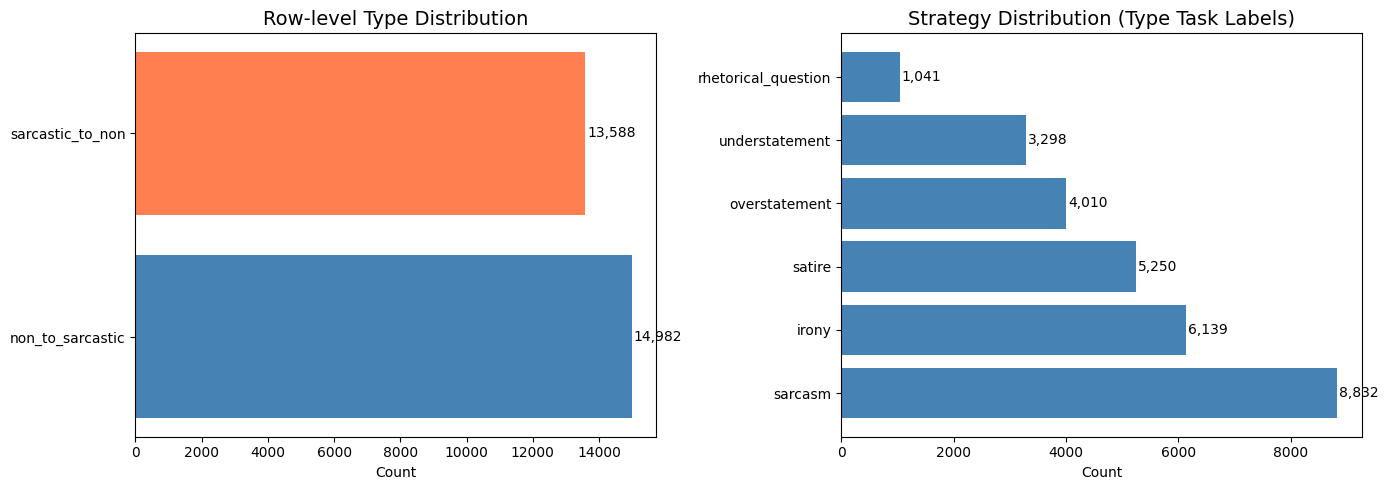

Saved: outputs/datasets/distributions.png


In [ ]:
# ── Strategy distribution plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Type dist
ax = axes[0]
labels, counts = zip(*sorted(type_counts.items(), key=lambda x: -x[1]))
ax.barh(labels, counts, color=["steelblue", "coral"])
ax.set_title("Row-level Type Distribution", fontsize=14)
ax.set_xlabel("Count")
for i, c in enumerate(counts):
    ax.text(c + 50, i, f"{c:,}", va="center")

# Strategy dist
ax = axes[1]
labels2, counts2 = zip(*sorted(strategy_counts.items(), key=lambda x: -x[1]))
ax.barh(labels2, counts2, color="steelblue")
ax.set_title("Strategy Distribution (Type Task Labels)", fontsize=14)
ax.set_xlabel("Count")
for i, c in enumerate(counts2):
    ax.text(c + 30, i, f"{c:,}", va="center")

plt.tight_layout()
plt.savefig(OUT_DATASETS / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/datasets/distributions.png")

## 3. Label Derivation and Dataset Expansion

In [ ]:
from __future__ import annotations
from urllib.parse import urlparse


def normalize_url(url: str) -> str:
    """Lowercase and strip scheme/trailing slash for stable group IDs."""
    url = url.strip().lower()
    parsed = urlparse(url)
    normalized = (parsed.netloc + parsed.path).rstrip("/")
    return normalized if normalized else url


def derive_labels(raw_rows):
    """
    Expand each JSONL row into 2 samples (sarcastic + non-sarcastic).

    Rules:
      sarcastic_to_non -> original=sarcastic(1), generated=non-sarcastic(0)
      non_to_sarcastic -> original=non-sarcastic(0), generated=sarcastic(1)

    Returns binary_df, type_df
    """
    binary_records = []
    sample_id = 0

    for pair_id, row in enumerate(raw_rows):
        group_id   = normalize_url(row["article_link"]) if row["article_link"] else str(pair_id)
        row_type   = row["type"]
        strategy   = row["strategy"]
        model_used = row["model_used"]
        article    = row["article_link"]

        if row_type == "sarcastic_to_non":
            orig_label, orig_strat = 1, strategy
            gen_label,  gen_strat  = 0, None
        else:
            orig_label, orig_strat = 0, None
            gen_label,  gen_strat  = 1, strategy

        binary_records.append({
            "sample_id"    : sample_id,
            "pair_id"      : pair_id,
            "group_id"     : group_id,
            "text"         : row["original_headline"],
            "binary_label" : orig_label,
            "is_generated" : 0,
            "strategy"     : orig_strat,
            "source_type"  : row_type,
            "article_link" : article,
            "model_used"   : model_used,
        })
        sample_id += 1

        binary_records.append({
            "sample_id"    : sample_id,
            "pair_id"      : pair_id,
            "group_id"     : group_id,
            "text"         : row["generated_headline"],
            "binary_label" : gen_label,
            "is_generated" : 1,
            "strategy"     : gen_strat,
            "source_type"  : row_type,
            "article_link" : article,
            "model_used"   : model_used,
        })
        sample_id += 1

    binary_df = pd.DataFrame(binary_records)

    # Validate counts
    counts = binary_df["binary_label"].value_counts().to_dict()
    n_expected = len(raw_rows)
    n0 = int(counts.get(0, 0))
    n1 = int(counts.get(1, 0))
    if n0 != n_expected or n1 != n_expected:
        raise ValueError(
            f"Label count mismatch!\n"
            f"  Expected {n_expected} per class\n"
            f"  Got: sarcastic(1)={n1}, non-sarcastic(0)={n0}"
        )

    # Type dataset: sarcastic only
    type_df = binary_df[binary_df["binary_label"] == 1].copy()
    type_df = type_df.rename(columns={"strategy": "type_label"})
    type_df = type_df[["sample_id", "pair_id", "group_id", "text",
                        "type_label", "is_generated", "source_type",
                        "article_link", "model_used"]]

    missing = type_df["type_label"].isna().sum()
    if missing > 0:
        raise ValueError(f"{missing} sarcastic samples have no type_label!")

    return binary_df, type_df


binary_df, type_df = derive_labels(raw_rows)

print(f"Binary dataset : {len(binary_df):,} samples")
print(f"  sarcastic (1): {(binary_df['binary_label']==1).sum():,}")
print(f"  non-sarc  (0): {(binary_df['binary_label']==0).sum():,}")
print()
print(f"Type dataset   : {len(type_df):,} samples")
print(type_df["type_label"].value_counts().to_string())


Binary dataset : 57,140 samples
  sarcastic (1): 28,570
  non-sarc  (0): 28,570

Type dataset   : 28,570 samples
type_label
sarcasm                8832
irony                  6139
satire                 5250
overstatement          4010
understatement         3298
rhetorical_question    1041


In [ ]:
# Save full datasets
binary_df.to_csv(OUT_DATASETS / "binary_dataset.csv", index=False)
type_df.to_csv(  OUT_DATASETS / "type_dataset.csv",   index=False)
print("Saved: outputs/datasets/binary_dataset.csv")
print("Saved: outputs/datasets/type_dataset.csv")

Saved: outputs/datasets/binary_dataset.csv
Saved: outputs/datasets/type_dataset.csv


## 4. Group-Aware Train / Val / Test Split

In [ ]:
def group_aware_split(
    df: pd.DataFrame,
    group_col: str = "group_id",
    train_frac: float = 0.70,
    val_frac:   float = 0.15,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split df into train/val/test at the group level.
    All rows sharing a group_id go to exactly one split.
    """
    groups = df[group_col].unique().tolist()
    rng = np.random.default_rng(seed)
    rng.shuffle(groups)

    n = len(groups)
    n_train = int(n * train_frac)
    n_val   = int(n * val_frac)

    train_groups = set(groups[:n_train])
    val_groups   = set(groups[n_train : n_train + n_val])
    test_groups  = set(groups[n_train + n_val :])

    train_df = df[df[group_col].isin(train_groups)].copy()
    val_df   = df[df[group_col].isin(val_groups)].copy()
    test_df  = df[df[group_col].isin(test_groups)].copy()

    # Sanity: no overlap
    assert train_groups.isdisjoint(val_groups),  "Train/val group overlap!"
    assert train_groups.isdisjoint(test_groups), "Train/test group overlap!"
    assert val_groups.isdisjoint(test_groups),   "Val/test group overlap!"

    return train_df, val_df, test_df


# ── Binary splits ─────────────────────────────────────────────────────────────
train_bin, val_bin, test_bin = group_aware_split(binary_df)

print("=== Binary splits ===")
for name, df in [("train", train_bin), ("val", val_bin), ("test", test_bin)]:
    dist = df["binary_label"].value_counts().to_dict()
    print(f"  {name:5s}: {len(df):,} samples | sarcastic={dist.get(1,0):,} non={dist.get(0,0):,}")

# ── Type splits ───────────────────────────────────────────────────────────────
train_type, val_type, test_type = group_aware_split(type_df)

print("\n=== Type splits ===")
for name, df in [("train", train_type), ("val", val_type), ("test", test_type)]:
    print(f"  {name:5s}: {len(df):,} samples")
    dist = df["type_label"].value_counts()
    for label, cnt in dist.items():
        print(f"    {label}: {cnt:,}")

NameError: name 'SEED' is not defined

In [ ]:
# ── Verify no pair crosses split boundary ─────────────────────────────────────
# A pair_id should appear in at most ONE binary split
train_pairs = set(train_bin["pair_id"])
val_pairs   = set(val_bin["pair_id"])
test_pairs  = set(test_bin["pair_id"])

tv_overlap  = train_pairs & val_pairs
tt_overlap  = train_pairs & test_pairs
vt_overlap  = val_pairs   & test_pairs

print(f"Train/Val pair_id overlap  : {len(tv_overlap)} (must be 0)")
print(f"Train/Test pair_id overlap : {len(tt_overlap)} (must be 0)")
print(f"Val/Test pair_id overlap   : {len(vt_overlap)} (must be 0)")

assert len(tv_overlap) == 0 and len(tt_overlap) == 0 and len(vt_overlap) == 0, \
    "Leakage detected: pairs crossing split boundaries!"
print("\nLeakage check PASSED: No pair_id crosses split boundaries.")

Train/Val pair_id overlap  : 0 (must be 0)
Train/Test pair_id overlap : 0 (must be 0)
Val/Test pair_id overlap   : 0 (must be 0)

Leakage check PASSED: No pair_id crosses split boundaries.


In [ ]:
# ── Save splits ───────────────────────────────────────────────────────────────
split_files = {
    "train_binary": train_bin,
    "val_binary"  : val_bin,
    "test_binary" : test_bin,
    "train_type"  : train_type,
    "val_type"    : val_type,
    "test_type"   : test_type,
}
for fname, df in split_files.items():
    path = OUT_SPLITS / f"{fname}.csv"
    df.to_csv(path, index=False)
    print(f"Saved: {path.relative_to(ROOT)}")

# Metadata
import json as _json
metadata = {
    "seed": SEED,
    "train_frac": 0.70,
    "val_frac": 0.15,
    "test_frac": 0.15,
    "group_col": "group_id",
    "total_pairs": len(raw_rows),
    "binary": {
        "train": len(train_bin), "val": len(val_bin), "test": len(test_bin)
    },
    "type": {
        "train": len(train_type), "val": len(val_type), "test": len(test_type)
    },
}
with open(OUT_SPLITS / "split_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)
print("\nSaved: outputs/splits/split_metadata.json")

Saved: outputs/splits/train_binary.csv
Saved: outputs/splits/val_binary.csv
Saved: outputs/splits/test_binary.csv
Saved: outputs/splits/train_type.csv
Saved: outputs/splits/val_type.csv
Saved: outputs/splits/test_type.csv

Saved: outputs/splits/split_metadata.json


## 5. Split Distribution Visualization

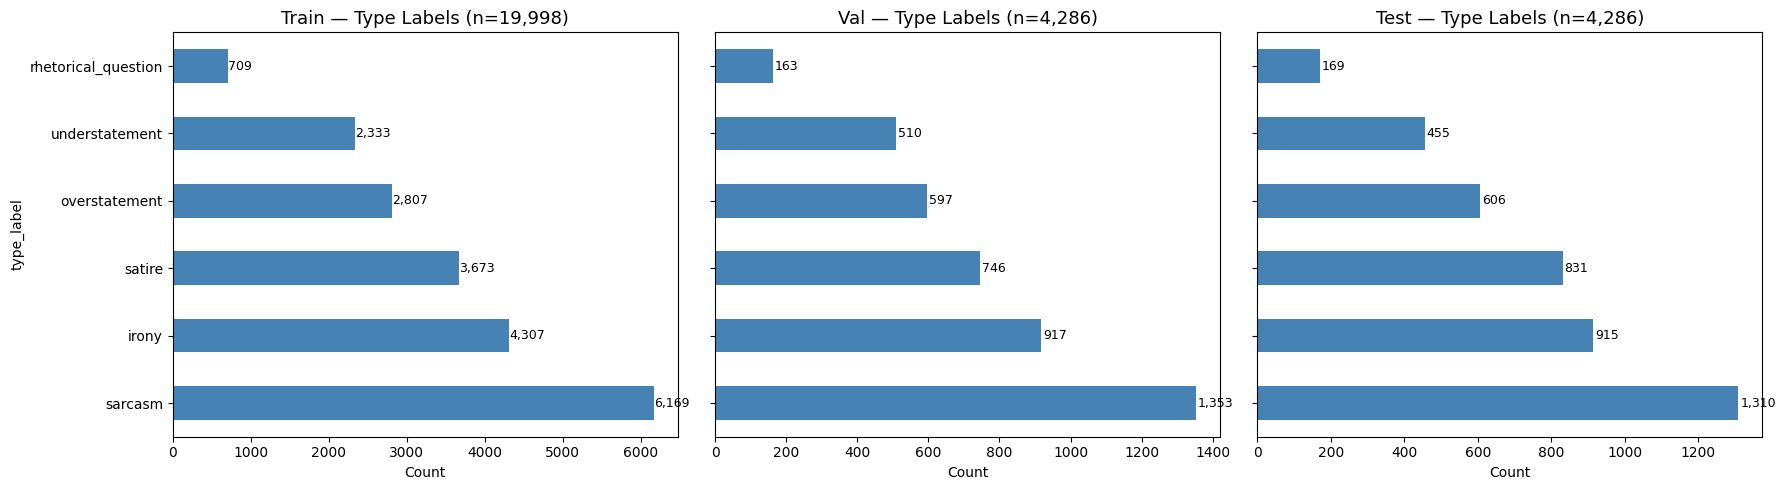

Saved: outputs/splits/type_split_distribution.png


In [ ]:
# Type label distribution per split
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
split_dfs = [("Train", train_type), ("Val", val_type), ("Test", test_type)]

for ax, (name, df) in zip(axes, split_dfs):
    dist = df["type_label"].value_counts()
    dist.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(f"{name} — Type Labels (n={len(df):,})", fontsize=13)
    ax.set_xlabel("Count")
    for i, (label, cnt) in enumerate(dist.items()):
        ax.text(cnt + 5, i, f"{cnt:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_SPLITS / "type_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/splits/type_split_distribution.png")

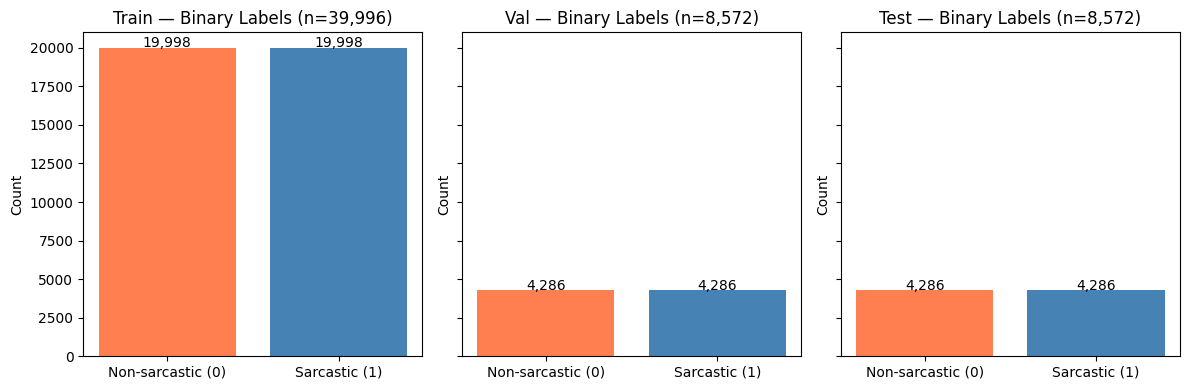

Saved: outputs/splits/binary_split_distribution.png


In [ ]:
# Binary label distribution per split
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
split_dfs_bin = [("Train", train_bin), ("Val", val_bin), ("Test", test_bin)]

for ax, (name, df) in zip(axes, split_dfs_bin):
    dist = df["binary_label"].value_counts().sort_index()
    ax.bar(["Non-sarcastic (0)", "Sarcastic (1)"], dist.values, color=["coral", "steelblue"])
    ax.set_title(f"{name} — Binary Labels (n={len(df):,})", fontsize=12)
    ax.set_ylabel("Count")
    for i, v in enumerate(dist.values):
        ax.text(i, v + 20, f"{v:,}", ha="center")

plt.tight_layout()
plt.savefig(OUT_SPLITS / "binary_split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/splits/binary_split_distribution.png")

In [ ]:
print("\n=== Data Preparation Complete ===")
print(f"Binary dataset : {len(binary_df):,} samples (balanced)")
print(f"Type dataset   : {len(type_df):,} samples (imbalanced, 6 classes)")
print(f"Splits saved to: outputs/splits/")
print(f"Datasets saved : outputs/datasets/")
print("\nReady for classical baseline training (Notebooks 02 and 03).")


=== Data Preparation Complete ===
Binary dataset : 57,140 samples (balanced)
Type dataset   : 28,570 samples (imbalanced, 6 classes)
Splits saved to: outputs/splits/
Datasets saved : outputs/datasets/

Ready for classical baseline training (Notebooks 02 and 03).


---
# Part 2 — TF-IDF + Logistic Regression Baseline

# Notebook 02 — TF-IDF + Logistic Regression Baseline

**Purpose**: Train and evaluate TF-IDF + Logistic Regression pipelines for:
- Task A: Binary classification (sarcastic vs non-sarcastic)
- Task B: Sarcasm type classification (6-class)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs**:
- `outputs/classical/tfidf_lr/best_config_binary.json`
- `outputs/classical/tfidf_lr/best_config_type.json`
- `outputs/classical/tfidf_lr/metrics_binary.json`
- `outputs/classical/tfidf_lr/metrics_type.json`
- Predictions CSV + confusion matrices PNG

## Helper Functions

In [ ]:
def load_splits(task: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Load train/val/test CSVs for a given task ('binary' or 'type')."""
    train = pd.read_csv(SPLITS / f"train_{task}.csv")
    val   = pd.read_csv(SPLITS / f"val_{task}.csv")
    test  = pd.read_csv(SPLITS / f"test_{task}.csv")
    return train, val, test


def evaluate(
    model,
    X: list[str],
    y_true: list,
    label_names: list[str] | None = None,
    split_name: str = "",
) -> dict:
    """Compute classification metrics and return as dict."""
    y_pred = model.predict(X)
    metrics = {
        "split"           : split_name,
        "accuracy"        : accuracy_score(y_true, y_pred),
        "precision_macro" : precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro"    : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro"        : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "report"          : classification_report(y_true, y_pred, target_names=label_names,
                                                  zero_division=0, output_dict=True),
    }
    print(f"\n[{split_name}] Accuracy={metrics['accuracy']:.4f}  "
          f"Macro-F1={metrics['f1_macro']:.4f}  Weighted-F1={metrics['f1_weighted']:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return metrics, y_pred


def save_confusion_matrix(
    y_true, y_pred, label_names: list[str], out_path: Path, title: str = ""
) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_names, yticklabels=label_names, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.relative_to(ROOT)}")


def save_predictions(
    df: pd.DataFrame, y_pred, label_col: str, out_path: Path
) -> None:
    out = df[["sample_id", "pair_id", "group_id", "text", label_col]].copy()
    out["predicted"] = y_pred
    out["correct"]   = (out[label_col] == out["predicted"]).astype(int)
    out.to_csv(out_path, index=False)
    print(f"Saved: {out_path.relative_to(ROOT)}")

## Task A — Binary Classification

In [ ]:
# ── Load binary splits ────────────────────────────────────────────────────────
train_bin, val_bin, test_bin = load_splits("binary")

# Combine train+val for cross-validation, keep test for final eval
trainval_bin = pd.concat([train_bin, val_bin], ignore_index=True)

X_trainval = trainval_bin["text"].tolist()
y_trainval = trainval_bin["binary_label"].tolist()
groups_tv  = trainval_bin["group_id"].tolist()

X_train = train_bin["text"].tolist()
y_train = train_bin["binary_label"].tolist()

X_val   = val_bin["text"].tolist()
y_val   = val_bin["binary_label"].tolist()

X_test  = test_bin["text"].tolist()
y_test  = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Train+Val: {len(X_trainval):,}  |  Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train+Val: 48,568  |  Train: 39,996  Val: 8,572  Test: 8,572


In [ ]:
# ── Define pipeline and grid ──────────────────────────────────────────────────
pipe_bin = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, lowercase=True)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs")),
])

param_grid_bin = {
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "tfidf__min_df"      : [2, 3, 5],
    "tfidf__max_features": [None, 50_000],
    "lr__C"              : [0.1, 1.0, 3.0],
}

cv_bin = GroupKFold(n_splits=5)

gs_bin = GridSearchCV(
    pipe_bin, param_grid_bin,
    cv=cv_bin, scoring="f1_macro",
    n_jobs=-1, verbose=1, refit=True,
)

print(f"Grid size: {len(gs_bin.param_grid)} param combos → {5 * 2*3*2*3} fits")
print("Running grid search...")
gs_bin.fit(X_trainval, y_trainval, groups=groups_tv)

print(f"\nBest params  : {gs_bin.best_params_}")
print(f"Best CV F1   : {gs_bin.best_score_:.4f}")

Grid size: 4 param combos → 180 fits
Running grid search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params  : {'lr__C': 3.0, 'tfidf__max_features': None, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
Best CV F1   : 0.8149


In [ ]:
# ── Save best config ──────────────────────────────────────────────────────────
best_cfg_bin = {"task": "binary", "model": "TF-IDF + LR", "seed": SEED,
                "best_params": gs_bin.best_params_, "cv_f1_macro": gs_bin.best_score_}
with open(OUT_TFIDF / "best_config_binary.json", "w") as f:
    json.dump(best_cfg_bin, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/best_config_binary.json")

Saved: outputs/classical/tfidf_lr/best_config_binary.json


In [ ]:
# ── Evaluate on val and test ──────────────────────────────────────────────────
best_bin = gs_bin.best_estimator_

val_metrics_bin,  y_val_pred_bin  = evaluate(best_bin, X_val,  y_val,  label_names_bin, "Val")
test_metrics_bin, y_test_pred_bin = evaluate(best_bin, X_test, y_test, label_names_bin, "Test")

all_metrics_bin = {"val": val_metrics_bin, "test": test_metrics_bin}

# Remove classification_report dict (too nested for JSON)
for split_m in all_metrics_bin.values():
    split_m.pop("report", None)

with open(OUT_TFIDF / "metrics_binary.json", "w") as f:
    json.dump(all_metrics_bin, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/metrics_binary.json")


[Val] Accuracy=0.9202  Macro-F1=0.9202  Weighted-F1=0.9202
               precision    recall  f1-score   support

non-sarcastic       0.91      0.93      0.92      4286
    sarcastic       0.93      0.91      0.92      4286

     accuracy                           0.92      8572
    macro avg       0.92      0.92      0.92      8572
 weighted avg       0.92      0.92      0.92      8572


[Test] Accuracy=0.8187  Macro-F1=0.8187  Weighted-F1=0.8187
               precision    recall  f1-score   support

non-sarcastic       0.82      0.82      0.82      4286
    sarcastic       0.82      0.82      0.82      4286

     accuracy                           0.82      8572
    macro avg       0.82      0.82      0.82      8572
 weighted avg       0.82      0.82      0.82      8572

Saved: outputs/classical/tfidf_lr/metrics_binary.json


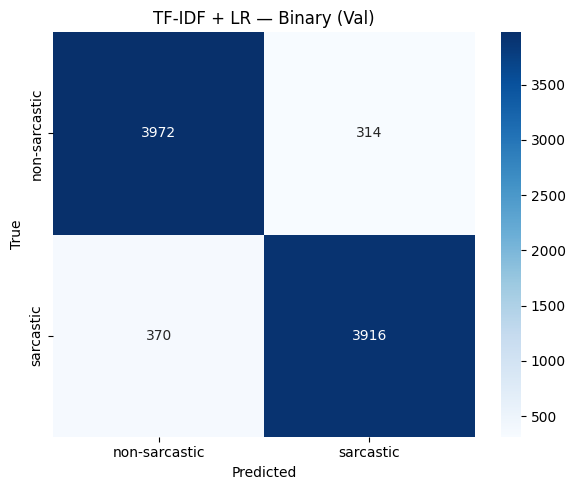

Saved: outputs/classical/tfidf_lr/confusion_matrix_binary_val.png


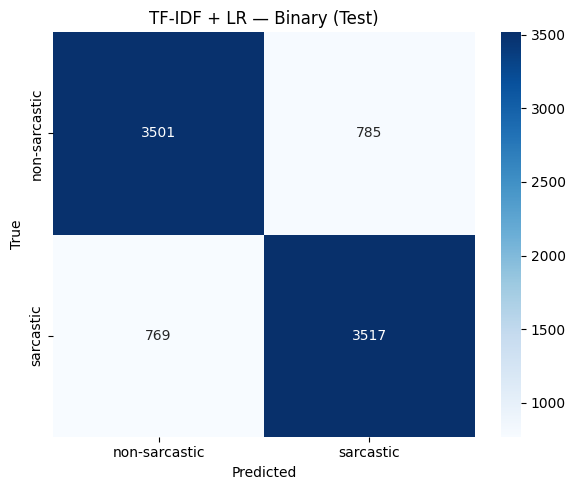

Saved: outputs/classical/tfidf_lr/confusion_matrix_binary_test.png


In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
save_confusion_matrix(
    y_val, y_val_pred_bin, label_names_bin,
    OUT_TFIDF / "confusion_matrix_binary_val.png",
    "TF-IDF + LR — Binary (Val)"
)
save_confusion_matrix(
    y_test, y_test_pred_bin, label_names_bin,
    OUT_TFIDF / "confusion_matrix_binary_test.png",
    "TF-IDF + LR — Binary (Test)"
)

In [ ]:
# ── Save predictions ──────────────────────────────────────────────────────────
save_predictions(val_bin,  y_val_pred_bin,  "binary_label", OUT_TFIDF / "predictions_val_binary.csv")
save_predictions(test_bin, y_test_pred_bin, "binary_label", OUT_TFIDF / "predictions_test_binary.csv")

Saved: outputs/classical/tfidf_lr/predictions_val_binary.csv
Saved: outputs/classical/tfidf_lr/predictions_test_binary.csv


In [ ]:
# ── Feature importance: top discriminative terms ──────────────────────────────
tfidf_vocab = best_bin.named_steps["tfidf"].get_feature_names_out()
lr_coefs    = best_bin.named_steps["lr"].coef_[0]  # binary: shape (n_features,)

n_top = 20
top_pos_idx = np.argsort(lr_coefs)[-n_top:][::-1]
top_neg_idx = np.argsort(lr_coefs)[:n_top]

top_positive = [(tfidf_vocab[i], lr_coefs[i]) for i in top_pos_idx]
top_negative = [(tfidf_vocab[i], lr_coefs[i]) for i in top_neg_idx]

print("Top 20 sarcastic indicators (positive coef):")
for term, coef in top_positive:
    print(f"  {term:35s}  {coef:+.4f}")

print("\nTop 20 non-sarcastic indicators (negative coef):")
for term, coef in top_negative:
    print(f"  {term:35s}  {coef:+.4f}")

Top 20 sarcastic indicators (positive coef):
  because                              +21.8727
  just                                 +9.5567
  obviously                            +9.4497
  finally                              +9.4336
  so                                   +8.8813
  clearly                              +8.6789
  shocking                             +8.6272
  as if                                +8.2086
  proving                              +7.7456
  groundbreaking                       +7.5829
  nation                               +7.3553
  like                                 +7.2835
  shocker                              +6.5819
  never                                +6.5382
  nothing                              +6.3989
  totally                              +6.3672
  sure                                 +6.2581
  always                               +6.1251
  area                                 +6.0996
  who needs                            +6.0413

Top 20 non-sa

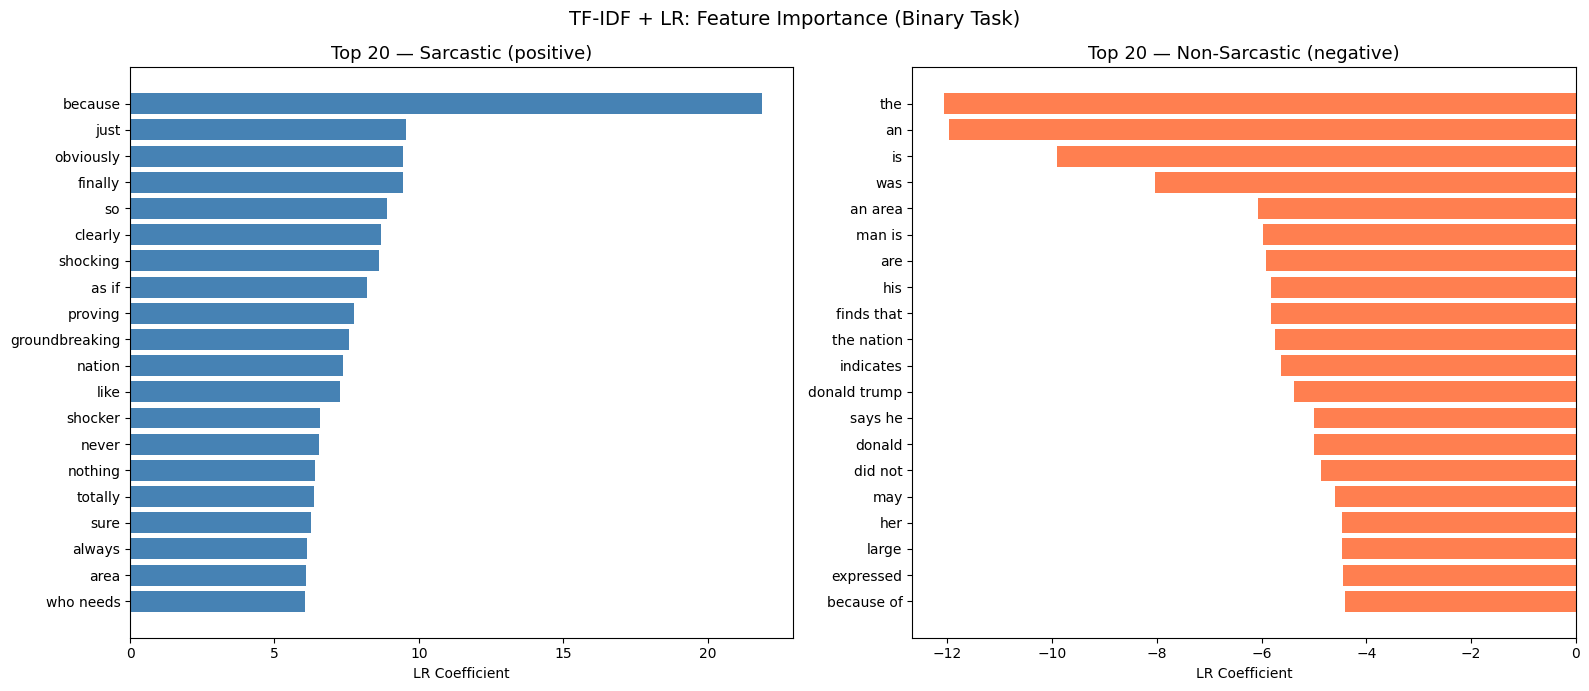

Saved: outputs/classical/tfidf_lr/feature_importance_binary.png


In [ ]:
# ── Feature importance plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

terms_pos, coefs_pos = zip(*top_positive)
axes[0].barh(list(reversed(terms_pos)), list(reversed(coefs_pos)), color="steelblue")
axes[0].set_title("Top 20 — Sarcastic (positive)", fontsize=13)
axes[0].set_xlabel("LR Coefficient")

terms_neg, coefs_neg = zip(*top_negative)
axes[1].barh(list(reversed(terms_neg)), list(reversed(coefs_neg)), color="coral")
axes[1].set_title("Top 20 — Non-Sarcastic (negative)", fontsize=13)
axes[1].set_xlabel("LR Coefficient")

plt.suptitle("TF-IDF + LR: Feature Importance (Binary Task)", fontsize=14)
plt.tight_layout()
plt.savefig(OUT_TFIDF / "feature_importance_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/classical/tfidf_lr/feature_importance_binary.png")

## Task B — Sarcasm Type Classification

In [ ]:
# ── Load type splits ──────────────────────────────────────────────────────────
train_type, val_type, test_type = load_splits("type")

# Encode string labels to integers
STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def encode_labels(df: pd.DataFrame) -> list[int]:
    return [label2id[l] for l in df["type_label"]]

trainval_type = pd.concat([train_type, val_type], ignore_index=True)

X_trainval_t = trainval_type["text"].tolist()
y_trainval_t = encode_labels(trainval_type)
groups_tv_t  = trainval_type["group_id"].tolist()

X_train_t = train_type["text"].tolist()
y_train_t = encode_labels(train_type)
X_val_t   = val_type["text"].tolist()
y_val_t   = encode_labels(val_type)
X_test_t  = test_type["text"].tolist()
y_test_t  = encode_labels(test_type)

print(f"Strategies: {STRATEGY_LABELS}")
print(f"Train+Val: {len(X_trainval_t):,}  Train: {len(X_train_t):,}  Val: {len(X_val_t):,}  Test: {len(X_test_t):,}")

Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']
Train+Val: 24,284  Train: 19,998  Val: 4,286  Test: 4,286


In [ ]:
# ── Define pipeline and grid (with class_weight) ──────────────────────────────
pipe_type = Pipeline([
    ("tfidf", TfidfVectorizer(sublinear_tf=True, lowercase=True)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, solver="lbfgs",
                                 multi_class="auto")),
])

param_grid_type = {
    "tfidf__ngram_range" : [(1, 1), (1, 2)],
    "tfidf__min_df"      : [2, 3, 5],
    "tfidf__max_features": [None, 50_000],
    "lr__C"              : [0.1, 1.0, 3.0],
    "lr__class_weight"   : [None, "balanced"],
}

cv_type = GroupKFold(n_splits=5)

gs_type = GridSearchCV(
    pipe_type, param_grid_type,
    cv=cv_type, scoring="f1_macro",
    n_jobs=-1, verbose=1, refit=True,
)

print("Running grid search for type task...")
gs_type.fit(X_trainval_t, y_trainval_t, groups=groups_tv_t)

print(f"\nBest params  : {gs_type.best_params_}")
print(f"Best CV F1   : {gs_type.best_score_:.4f}")

Running grid search for type task...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best params  : {'lr__C': 3.0, 'lr__class_weight': 'balanced', 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
Best CV F1   : 0.3866


In [ ]:
# ── Save best config ──────────────────────────────────────────────────────────
best_cfg_type = {"task": "type", "model": "TF-IDF + LR", "seed": SEED,
                 "label_names": STRATEGY_LABELS, "label2id": label2id,
                 "best_params": gs_type.best_params_, "cv_f1_macro": gs_type.best_score_}
with open(OUT_TFIDF / "best_config_type.json", "w") as f:
    json.dump(best_cfg_type, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/best_config_type.json")

Saved: outputs/classical/tfidf_lr/best_config_type.json


In [ ]:
# ── Evaluate on val and test ──────────────────────────────────────────────────
best_type = gs_type.best_estimator_

val_metrics_type,  y_val_pred_type  = evaluate(best_type, X_val_t,  y_val_t,  STRATEGY_LABELS, "Val")
test_metrics_type, y_test_pred_type = evaluate(best_type, X_test_t, y_test_t, STRATEGY_LABELS, "Test")

all_metrics_type = {"val": val_metrics_type, "test": test_metrics_type}
for split_m in all_metrics_type.values():
    split_m.pop("report", None)

with open(OUT_TFIDF / "metrics_type.json", "w") as f:
    json.dump(all_metrics_type, f, indent=2)
print("Saved: outputs/classical/tfidf_lr/metrics_type.json")


[Val] Accuracy=0.9001  Macro-F1=0.9017  Weighted-F1=0.8995
                     precision    recall  f1-score   support

              irony       0.91      0.88      0.90       917
      overstatement       0.88      0.97      0.92       597
rhetorical_question       0.79      1.00      0.88       163
            sarcasm       0.95      0.83      0.88      1353
             satire       0.87      0.92      0.90       746
     understatement       0.87      0.99      0.93       510

           accuracy                           0.90      4286
          macro avg       0.88      0.93      0.90      4286
       weighted avg       0.90      0.90      0.90      4286


[Test] Accuracy=0.3920  Macro-F1=0.3986  Weighted-F1=0.3915
                     precision    recall  f1-score   support

              irony       0.34      0.30      0.31       915
      overstatement       0.37      0.42      0.39       606
rhetorical_question       0.40      0.59      0.48       169
            sarcasm  

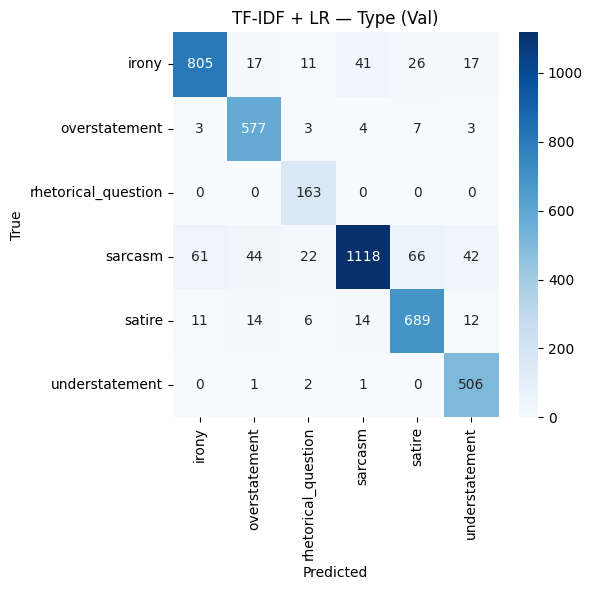

Saved: outputs/classical/tfidf_lr/confusion_matrix_type_val.png


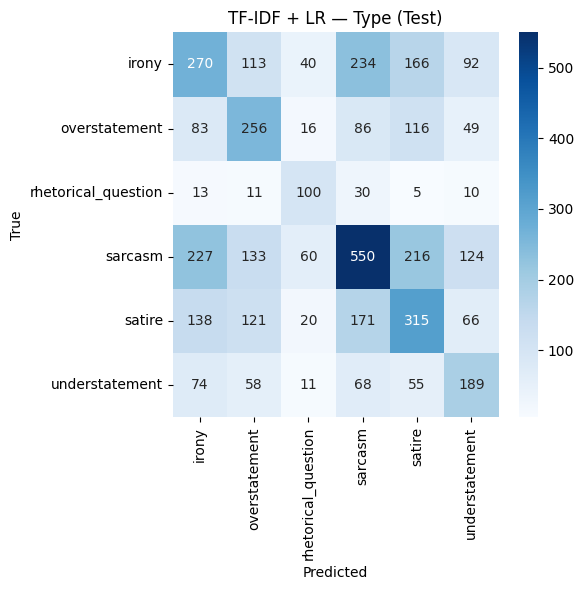

Saved: outputs/classical/tfidf_lr/confusion_matrix_type_test.png


In [ ]:
# ── Confusion matrices ────────────────────────────────────────────────────────
save_confusion_matrix(
    y_val_t, y_val_pred_type, STRATEGY_LABELS,
    OUT_TFIDF / "confusion_matrix_type_val.png",
    "TF-IDF + LR — Type (Val)"
)
save_confusion_matrix(
    y_test_t, y_test_pred_type, STRATEGY_LABELS,
    OUT_TFIDF / "confusion_matrix_type_test.png",
    "TF-IDF + LR — Type (Test)"
)

In [ ]:
# ── Save predictions ──────────────────────────────────────────────────────────
# Decode integer predictions back to string labels
val_type_copy  = val_type.copy();  val_type_copy["type_label"]  = y_val_t
test_type_copy = test_type.copy(); test_type_copy["type_label"] = y_test_t

val_type_copy["predicted_id"]    = y_val_pred_type
val_type_copy["predicted_label"] = [id2label[i] for i in y_val_pred_type]
val_type_copy["true_label"]      = [id2label[i] for i in y_val_t]
val_type_copy["correct"]         = (val_type_copy["type_label"] == val_type_copy["predicted_id"]).astype(int)

test_type_copy["predicted_id"]    = y_test_pred_type
test_type_copy["predicted_label"] = [id2label[i] for i in y_test_pred_type]
test_type_copy["true_label"]      = [id2label[i] for i in y_test_t]
test_type_copy["correct"]         = (test_type_copy["type_label"] == test_type_copy["predicted_id"]).astype(int)

val_type_copy.to_csv( OUT_TFIDF / "predictions_val_type.csv",  index=False)
test_type_copy.to_csv(OUT_TFIDF / "predictions_test_type.csv", index=False)
print("Saved predictions_val_type.csv and predictions_test_type.csv")

Saved predictions_val_type.csv and predictions_test_type.csv


## Char N-gram Variant (Optional)

In [ ]:
# Char n-gram model for binary task (stylistic cues)
pipe_char = Pipeline([
    ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                              sublinear_tf=True, lowercase=True, max_features=50_000)),
    ("lr",    LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)),
])

param_grid_char = {"lr__C": [0.1, 1.0, 3.0]}
gs_char = GridSearchCV(pipe_char, param_grid_char, cv=GroupKFold(5),
                       scoring="f1_macro", n_jobs=-1)
gs_char.fit(X_trainval, y_trainval, groups=groups_tv)

print(f"Char n-gram best C      : {gs_char.best_params_}")
print(f"Char n-gram best CV F1  : {gs_char.best_score_:.4f}")
print(f"Word n-gram best CV F1  : {gs_bin.best_score_:.4f}")
print()
char_metrics, _ = evaluate(gs_char.best_estimator_, X_test, y_test, label_names_bin, "Test (char)")

Char n-gram best C      : {'lr__C': 3.0}
Char n-gram best CV F1  : 0.8283
Word n-gram best CV F1  : 0.8149


[Test (char)] Accuracy=0.8271  Macro-F1=0.8271  Weighted-F1=0.8271
               precision    recall  f1-score   support

non-sarcastic       0.82      0.84      0.83      4286
    sarcastic       0.83      0.82      0.83      4286

     accuracy                           0.83      8572
    macro avg       0.83      0.83      0.83      8572
 weighted avg       0.83      0.83      0.83      8572



## Summary

In [ ]:
print("====== TF-IDF + LR RESULTS SUMMARY ======")
print()
print("Task A — Binary Classification (Test Set):")
print(f"  Accuracy        : {test_metrics_bin['accuracy']:.4f}")
print(f"  Macro-F1        : {test_metrics_bin['f1_macro']:.4f}")
print(f"  Weighted-F1     : {test_metrics_bin['f1_weighted']:.4f}")
print()
print("Task B — Type Classification (Test Set):")
print(f"  Accuracy        : {test_metrics_type['accuracy']:.4f}")
print(f"  Macro-F1        : {test_metrics_type['f1_macro']:.4f}")
print(f"  Weighted-F1     : {test_metrics_type['f1_weighted']:.4f}")
print()
print("Best hyperparameters:")
print("  Binary:", gs_bin.best_params_)
print("  Type:  ", gs_type.best_params_)

====== TF-IDF + LR RESULTS SUMMARY ======

Task A — Binary Classification (Test Set):
  Accuracy        : 0.8187
  Macro-F1        : 0.8187
  Weighted-F1     : 0.8187

Task B — Type Classification (Test Set):
  Accuracy        : 0.3920
  Macro-F1        : 0.3986
  Weighted-F1     : 0.3915

Best hyperparameters:
  Binary: {'lr__C': 3.0, 'tfidf__max_features': None, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}
  Type:   {'lr__C': 3.0, 'lr__class_weight': 'balanced', 'tfidf__max_features': None, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}


---
# Part 3 — Naive Bayes Baseline

# Notebook 03 — Naive Bayes Baseline

**Purpose**: Train and evaluate Naive Bayes classifiers for:
- Task A: Binary classification (sarcastic vs non-sarcastic)
- Task B: Sarcasm type classification (6-class)

Compares:
- `CountVectorizer + MultinomialNB`
- `TfidfVectorizer + MultinomialNB`
- `CountVectorizer + ComplementNB` (for imbalanced type task)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs** in `outputs/classical/naive_bayes/`

## Helper Functions

In [ ]:
def load_splits(task: str):
    train = pd.read_csv(SPLITS / f"train_{task}.csv")
    val   = pd.read_csv(SPLITS / f"val_{task}.csv")
    test  = pd.read_csv(SPLITS / f"test_{task}.csv")
    return train, val, test


def evaluate(model, X, y_true, label_names=None, split_name=""):
    y_pred = model.predict(X)
    metrics = {
        "split"           : split_name,
        "accuracy"        : accuracy_score(y_true, y_pred),
        "precision_macro" : precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro"    : recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro"        : f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    print(f"[{split_name}] Accuracy={metrics['accuracy']:.4f}  "
          f"Macro-F1={metrics['f1_macro']:.4f}  Weighted-F1={metrics['f1_weighted']:.4f}")
    print(classification_report(y_true, y_pred, target_names=label_names, zero_division=0))
    return metrics, y_pred


def save_confusion_matrix(y_true, y_pred, label_names, out_path, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path.relative_to(ROOT)}")


def run_nb_grid(
    vectorizer_cls, nb_cls, param_grid: dict,
    X_trainval, y_trainval, groups_tv,
    name: str
) -> GridSearchCV:
    """Run a grid search for a given vectorizer + NB combination."""
    pipe = Pipeline([
        ("vec", vectorizer_cls(lowercase=True)),
        ("nb",  nb_cls()),
    ])
    gs = GridSearchCV(
        pipe, param_grid, cv=GroupKFold(5),
        scoring="f1_macro", n_jobs=-1, verbose=0, refit=True
    )
    gs.fit(X_trainval, y_trainval, groups=groups_tv)
    print(f"{name:50s}  CV F1={gs.best_score_:.4f}  params={gs.best_params_}")
    return gs

## Task A — Binary Classification

In [ ]:
train_bin, val_bin, test_bin = load_splits("binary")
trainval_bin = pd.concat([train_bin, val_bin], ignore_index=True)

X_tv   = trainval_bin["text"].tolist()
y_tv   = trainval_bin["binary_label"].tolist()
grp_tv = trainval_bin["group_id"].tolist()

X_val  = val_bin["text"].tolist();  y_val  = val_bin["binary_label"].tolist()
X_test = test_bin["text"].tolist(); y_test = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Train+Val: {len(X_tv):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train+Val: 48,568  Val: 8,572  Test: 8,572


In [ ]:
# ── Shared grid parameters ────────────────────────────────────────────────────
BASE_GRID = {
    "vec__ngram_range": [(1, 1), (1, 2)],
    "vec__min_df"     : [2, 3, 5],
    "nb__alpha"       : [0.1, 0.5, 1.0],
}

print("=== Binary: Comparing Vectorizer + NB Combinations ===")

gs_count_mnb_bin = run_nb_grid(
    CountVectorizer, MultinomialNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "CountVectorizer + MultinomialNB"
)

gs_tfidf_mnb_bin = run_nb_grid(
    TfidfVectorizer, MultinomialNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "TfidfVectorizer + MultinomialNB"
)

gs_count_cnb_bin = run_nb_grid(
    CountVectorizer, ComplementNB, BASE_GRID,
    X_tv, y_tv, grp_tv,
    "CountVectorizer + ComplementNB"
)

=== Binary: Comparing Vectorizer + NB Combinations ===
CountVectorizer + MultinomialNB                     CV F1=0.7855  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
TfidfVectorizer + MultinomialNB                     CV F1=0.7893  params={'nb__alpha': 0.5, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
CountVectorizer + ComplementNB                      CV F1=0.7855  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


In [ ]:
# ── Select best binary model ──────────────────────────────────────────────────
candidates_bin = [
    ("CountVec+MultinomialNB", gs_count_mnb_bin),
    ("TfidfVec+MultinomialNB", gs_tfidf_mnb_bin),
    ("CountVec+ComplementNB",  gs_count_cnb_bin),
]

best_name_bin, best_gs_bin = max(candidates_bin, key=lambda x: x[1].best_score_)
print(f"\nBest binary NB model: {best_name_bin} (CV F1={best_gs_bin.best_score_:.4f})")

# Comparison table
comp_df = pd.DataFrame([
    {"model": name, "cv_f1_macro": gs.best_score_, "best_params": str(gs.best_params_)}
    for name, gs in candidates_bin
])
print("\nComparison table:")
print(comp_df.to_string(index=False))


Best binary NB model: TfidfVec+MultinomialNB (CV F1=0.7893)

Comparison table:
                 model  cv_f1_macro                                                      best_params
CountVec+MultinomialNB     0.785503 {'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
TfidfVec+MultinomialNB     0.789322 {'nb__alpha': 0.5, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
 CountVec+ComplementNB     0.785503 {'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


In [ ]:
# ── Evaluate best model ───────────────────────────────────────────────────────
best_model_bin = best_gs_bin.best_estimator_

val_m_bin,  y_val_pred_bin  = evaluate(best_model_bin, X_val,  y_val,  label_names_bin, "Val")
test_m_bin, y_test_pred_bin = evaluate(best_model_bin, X_test, y_test, label_names_bin, "Test")

# Also evaluate all three models on test for comparison
print("\n--- All models on Test ---")
all_test_results_bin = []
for name, gs in candidates_bin:
    y_pred_t = gs.best_estimator_.predict(X_test)
    f1 = f1_score(y_test, y_pred_t, average="macro")
    acc = accuracy_score(y_test, y_pred_t)
    all_test_results_bin.append({"model": name, "accuracy": acc, "f1_macro": f1})
    print(f"  {name:40s}: acc={acc:.4f}  macro-F1={f1:.4f}")

[Val] Accuracy=0.8958  Macro-F1=0.8958  Weighted-F1=0.8958
               precision    recall  f1-score   support

non-sarcastic       0.90      0.89      0.89      4286
    sarcastic       0.89      0.90      0.90      4286

     accuracy                           0.90      8572
    macro avg       0.90      0.90      0.90      8572
 weighted avg       0.90      0.90      0.90      8572

[Test] Accuracy=0.7920  Macro-F1=0.7918  Weighted-F1=0.7918
               precision    recall  f1-score   support

non-sarcastic       0.81      0.76      0.79      4286
    sarcastic       0.77      0.82      0.80      4286

     accuracy                           0.79      8572
    macro avg       0.79      0.79      0.79      8572
 weighted avg       0.79      0.79      0.79      8572


--- All models on Test ---
  CountVec+MultinomialNB                  : acc=0.7912  macro-F1=0.7911
  TfidfVec+MultinomialNB                  : acc=0.7920  macro-F1=0.7918
  CountVec+ComplementNB                   :

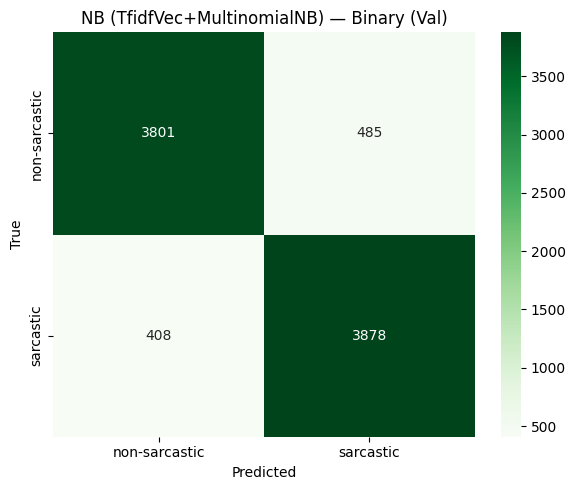

Saved: outputs/classical/naive_bayes/confusion_matrix_binary_val.png


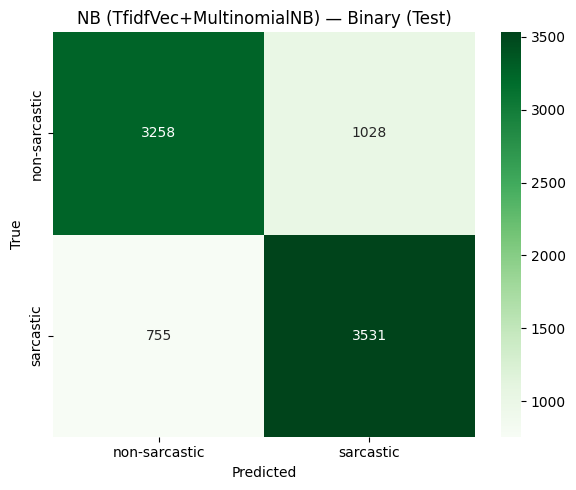

Saved: outputs/classical/naive_bayes/confusion_matrix_binary_test.png
All binary artifacts saved.


In [ ]:
# ── Save binary results ───────────────────────────────────────────────────────
cfg_bin = {
    "task": "binary", "best_model": best_name_bin,
    "best_params": best_gs_bin.best_params_, "cv_f1_macro": best_gs_bin.best_score_,
    "all_candidates": [
        {"model": name, "cv_f1_macro": gs.best_score_, "params": gs.best_params_}
        for name, gs in candidates_bin
    ]
}
with open(OUT_NB / "best_config_binary.json", "w") as f:
    json.dump(cfg_bin, f, indent=2)

all_m_bin = {"val": val_m_bin, "test": test_m_bin,
             "all_test_comparison": all_test_results_bin}
with open(OUT_NB / "metrics_binary.json", "w") as f:
    json.dump(all_m_bin, f, indent=2)

save_confusion_matrix(
    y_val, y_val_pred_bin, label_names_bin,
    OUT_NB / "confusion_matrix_binary_val.png",
    f"NB ({best_name_bin}) — Binary (Val)"
)
save_confusion_matrix(
    y_test, y_test_pred_bin, label_names_bin,
    OUT_NB / "confusion_matrix_binary_test.png",
    f"NB ({best_name_bin}) — Binary (Test)"
)

# Predictions
pred_val_bin = val_bin.copy()
pred_val_bin["predicted"] = y_val_pred_bin
pred_val_bin["correct"]   = (pred_val_bin["binary_label"] == pred_val_bin["predicted"]).astype(int)
pred_val_bin.to_csv(OUT_NB / "predictions_val_binary.csv", index=False)

pred_test_bin = test_bin.copy()
pred_test_bin["predicted"] = y_test_pred_bin
pred_test_bin["correct"]   = (pred_test_bin["binary_label"] == pred_test_bin["predicted"]).astype(int)
pred_test_bin.to_csv(OUT_NB / "predictions_test_binary.csv", index=False)

print("All binary artifacts saved.")

## Task B — Sarcasm Type Classification

In [ ]:
train_type, val_type, test_type = load_splits("type")

STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def enc(df): return [label2id[l] for l in df["type_label"]]

trainval_type = pd.concat([train_type, val_type], ignore_index=True)
X_tv_t   = trainval_type["text"].tolist()
y_tv_t   = enc(trainval_type)
grp_tv_t = trainval_type["group_id"].tolist()

X_val_t  = val_type["text"].tolist();  y_val_t  = enc(val_type)
X_test_t = test_type["text"].tolist(); y_test_t = enc(test_type)

print(f"Strategies: {STRATEGY_LABELS}")
print(f"Train+Val: {len(X_tv_t):,}  Val: {len(X_val_t):,}  Test: {len(X_test_t):,}")

Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']
Train+Val: 24,284  Val: 4,286  Test: 4,286


In [ ]:
print("=== Type: Comparing Vectorizer + NB Combinations ===")

gs_count_mnb_type = run_nb_grid(
    CountVectorizer, MultinomialNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "CountVectorizer + MultinomialNB"
)

gs_tfidf_mnb_type = run_nb_grid(
    TfidfVectorizer, MultinomialNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "TfidfVectorizer + MultinomialNB"
)

gs_count_cnb_type = run_nb_grid(
    CountVectorizer, ComplementNB, BASE_GRID,
    X_tv_t, y_tv_t, grp_tv_t,
    "CountVectorizer + ComplementNB  (for imbalance)"
)

=== Type: Comparing Vectorizer + NB Combinations ===
CountVectorizer + MultinomialNB                     CV F1=0.3821  params={'nb__alpha': 0.5, 'vec__min_df': 3, 'vec__ngram_range': (1, 2)}
TfidfVectorizer + MultinomialNB                     CV F1=0.3464  params={'nb__alpha': 0.1, 'vec__min_df': 5, 'vec__ngram_range': (1, 2)}
CountVectorizer + ComplementNB  (for imbalance)     CV F1=0.3797  params={'nb__alpha': 1.0, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}


In [ ]:
candidates_type = [
    ("CountVec+MultinomialNB", gs_count_mnb_type),
    ("TfidfVec+MultinomialNB", gs_tfidf_mnb_type),
    ("CountVec+ComplementNB",  gs_count_cnb_type),
]

best_name_type, best_gs_type = max(candidates_type, key=lambda x: x[1].best_score_)
print(f"Best type NB model: {best_name_type} (CV F1={best_gs_type.best_score_:.4f})")

print("\n--- All models on Test (Type Task) ---")
all_test_results_type = []
for name, gs in candidates_type:
    y_pred_t = gs.best_estimator_.predict(X_test_t)
    f1  = f1_score(y_test_t, y_pred_t, average="macro")
    acc = accuracy_score(y_test_t, y_pred_t)
    all_test_results_type.append({"model": name, "accuracy": acc, "f1_macro": f1})
    print(f"  {name:40s}: acc={acc:.4f}  macro-F1={f1:.4f}")

Best type NB model: CountVec+MultinomialNB (CV F1=0.3821)

--- All models on Test (Type Task) ---
  CountVec+MultinomialNB                  : acc=0.3945  macro-F1=0.3898
  TfidfVec+MultinomialNB                  : acc=0.3815  macro-F1=0.3455
  CountVec+ComplementNB                   : acc=0.3959  macro-F1=0.3911


[Val] Accuracy=0.7697  Macro-F1=0.7774  Weighted-F1=0.7695
                     precision    recall  f1-score   support

              irony       0.78      0.72      0.75       917
      overstatement       0.74      0.80      0.77       597
rhetorical_question       0.79      0.91      0.85       163
            sarcasm       0.80      0.78      0.79      1353
             satire       0.74      0.77      0.75       746
     understatement       0.76      0.76      0.76       510

           accuracy                           0.77      4286
          macro avg       0.77      0.79      0.78      4286
       weighted avg       0.77      0.77      0.77      4286

[Test] Accuracy=0.3945  Macro-F1=0.3898  Weighted-F1=0.3916
                     precision    recall  f1-score   support

              irony       0.33      0.29      0.31       915
      overstatement       0.40      0.39      0.40       606
rhetorical_question       0.49      0.40      0.44       169
            sarcasm    

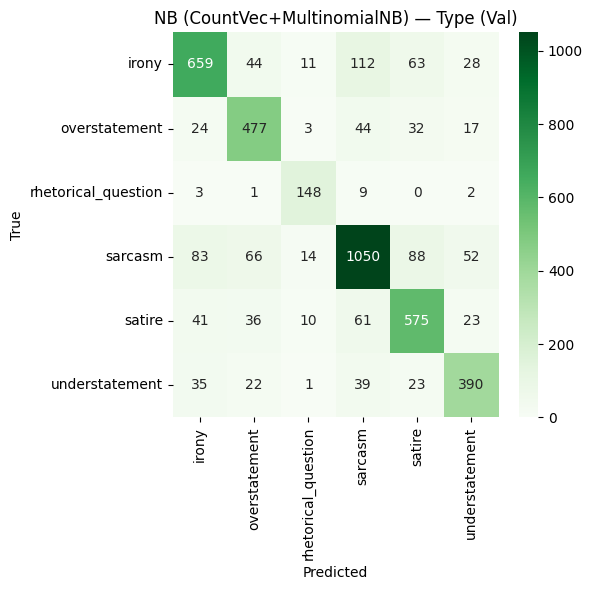

Saved: outputs/classical/naive_bayes/confusion_matrix_type_val.png


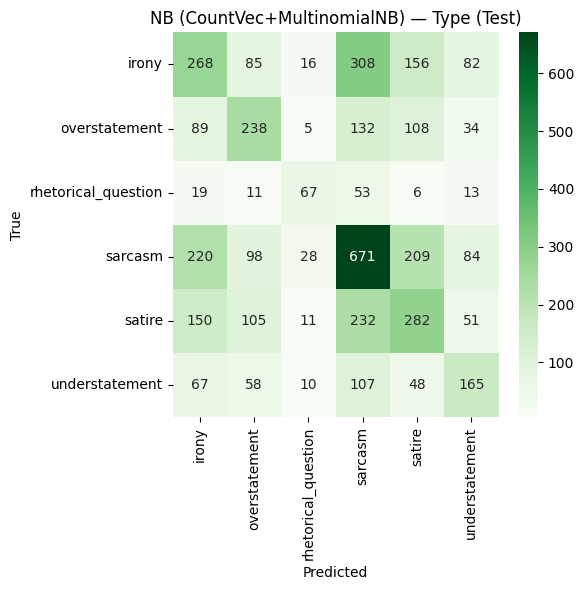

Saved: outputs/classical/naive_bayes/confusion_matrix_type_test.png
All type artifacts saved.


In [ ]:
best_model_type = best_gs_type.best_estimator_

val_m_type,  y_val_pred_type  = evaluate(best_model_type, X_val_t,  y_val_t,  STRATEGY_LABELS, "Val")
test_m_type, y_test_pred_type = evaluate(best_model_type, X_test_t, y_test_t, STRATEGY_LABELS, "Test")

# Save
cfg_type = {
    "task": "type", "best_model": best_name_type,
    "label_names": STRATEGY_LABELS, "label2id": label2id,
    "best_params": best_gs_type.best_params_, "cv_f1_macro": best_gs_type.best_score_,
}
with open(OUT_NB / "best_config_type.json", "w") as f:
    json.dump(cfg_type, f, indent=2)

all_m_type = {"val": val_m_type, "test": test_m_type,
              "all_test_comparison": all_test_results_type}
with open(OUT_NB / "metrics_type.json", "w") as f:
    json.dump(all_m_type, f, indent=2)

save_confusion_matrix(
    y_val_t, y_val_pred_type, STRATEGY_LABELS,
    OUT_NB / "confusion_matrix_type_val.png",
    f"NB ({best_name_type}) — Type (Val)"
)
save_confusion_matrix(
    y_test_t, y_test_pred_type, STRATEGY_LABELS,
    OUT_NB / "confusion_matrix_type_test.png",
    f"NB ({best_name_type}) — Type (Test)"
)

# Predictions with string labels
pred_val_type  = val_type.copy()
pred_test_type = test_type.copy()
for df, y_pred, y_true in [(pred_val_type, y_val_pred_type, y_val_t),
                            (pred_test_type, y_test_pred_type, y_test_t)]:
    df["predicted_label"] = [id2label[i] for i in y_pred]
    df["true_label"]      = [id2label[i] for i in y_true]
    df["correct"]         = (df["type_label"] == df["predicted_label"]).astype(int)

pred_val_type.to_csv( OUT_NB / "predictions_val_type.csv",  index=False)
pred_test_type.to_csv(OUT_NB / "predictions_test_type.csv", index=False)

print("All type artifacts saved.")

## Error Examples

In [ ]:
# ── Binary error examples ─────────────────────────────────────────────────────
err_bin = pred_test_bin[pred_test_bin["correct"] == 0].copy()
fp_bin  = err_bin[err_bin["binary_label"] == 0].head(10)  # predicted sarcastic, actually not
fn_bin  = err_bin[err_bin["binary_label"] == 1].head(10)  # predicted not-sarcastic, actually sarcastic

print(f"Binary errors on test: {len(err_bin)} total")
print(f"  False Positives (predicted sarcastic, actually not): {len(err_bin[err_bin['binary_label']==0])}")
print(f"  False Negatives (predicted not-sarcastic, actually sarcastic): {len(err_bin[err_bin['binary_label']==1])}")
print("\n--- Sample FP ---")
for _, row in fp_bin.iterrows():
    print(f"  [True=0, Pred=1] {row['text'][:100]}")
print("\n--- Sample FN ---")
for _, row in fn_bin.iterrows():
    print(f"  [True=1, Pred=0] {row['text'][:100]}")

Binary errors on test: 1783 total
  False Positives (predicted sarcastic, actually not): 1028
  False Negatives (predicted not-sarcastic, actually sarcastic): 755

--- Sample FP ---
  [True=0, Pred=1] Probability researchers note a coincidence where three coworkers wear the same shirt color.
  [True=0, Pred=1] The global-warming crisis contributed to a delightful mid-February afternoon.
  [True=0, Pred=1] Signs for the upcoming road section make it sound formidable or exciting.
  [True=0, Pred=1] A governor is too embarrassed to say which state he leads.
  [True=0, Pred=1] A man who plays devil's advocate may actually just want to be disagreeable.
  [True=0, Pred=1] Area dad watched a show about bigfoot last night.
  [True=0, Pred=1] Coroner's report cites systemic issues in Alton Sterling's death.
  [True=0, Pred=1] Preschool child asks to look at a classmate's notes on shapes.
  [True=0, Pred=1] Everyone in the coffee shop can see that the trainee is failing.
  [True=0, Pred=1] Thous

In [ ]:
# ── Type error examples ───────────────────────────────────────────────────────
err_type = pred_test_type[pred_test_type["correct"] == 0].copy()
print(f"Type errors on test: {len(err_type)} total")
print("\nConfusion pairs (true → predicted):")
conf_pairs = err_type.groupby(["type_label", "predicted_label"]).size().sort_values(ascending=False).head(10)
print(conf_pairs.to_string())

Type errors on test: 2595 total

Confusion pairs (true → predicted):
type_label      predicted_label
irony           sarcasm            308
satire          sarcasm            232
sarcasm         irony              220
                satire             209
irony           satire             156
satire          irony              150
overstatement   sarcasm            132
                satire             108
understatement  sarcasm            107
satire          overstatement      105


## Summary

In [ ]:
print("====== NAIVE BAYES RESULTS SUMMARY ======")
print()
print("Task A — Binary (Test):")
print(f"  Best model    : {best_name_bin}")
print(f"  Accuracy      : {test_m_bin['accuracy']:.4f}")
print(f"  Macro-F1      : {test_m_bin['f1_macro']:.4f}")
print(f"  Weighted-F1   : {test_m_bin['f1_weighted']:.4f}")
print()
print("Task B — Type (Test):")
print(f"  Best model    : {best_name_type}")
print(f"  Accuracy      : {test_m_type['accuracy']:.4f}")
print(f"  Macro-F1      : {test_m_type['f1_macro']:.4f}")
print(f"  Weighted-F1   : {test_m_type['f1_weighted']:.4f}")

====== NAIVE BAYES RESULTS SUMMARY ======

Task A — Binary (Test):
  Best model    : TfidfVec+MultinomialNB
  Accuracy      : 0.7920
  Macro-F1      : 0.7918
  Weighted-F1   : 0.7918

Task B — Type (Test):
  Best model    : CountVec+MultinomialNB
  Accuracy      : 0.3945
  Macro-F1      : 0.3898
  Weighted-F1   : 0.3916


---
# Part 4 — BERT / DistilBERT Classification

# Notebook 04 — BERT / DistilBERT Classification

**Purpose**: Fine-tune transformer models for sarcasm classification.
- Task A: Binary (sarcastic vs non-sarcastic)
- Task B: Sarcasm type (6-class, sarcastic only)

**Models**:
- `distilbert-base-uncased` (primary, fast)
- `bert-base-uncased` (optional, if compute allows)

**Prerequisite**: Run `01_data_preparation.ipynb` first.

**Outputs** in `outputs/bert/distilbert_binary/` and `outputs/bert/distilbert_type/`

## Configuration

In [ ]:
@dataclass
class TrainConfig:
    model_name   : str   = "distilbert-base-uncased"
    max_length   : int   = 128
    batch_size   : int   = 32
    lr           : float = 2e-5
    weight_decay : float = 0.01
    warmup_ratio : float = 0.1
    epochs       : int   = 10
    patience     : int   = 3       # early stopping patience
    seed         : int   = SEED
    task         : str   = "binary"  # 'binary' or 'type'
    class_weight_mode: str = "none"   # 'none', 'inverse', 'sqrt_inverse'
    checkpoint_every: int = 1         # save epoch checkpoint every N epochs
    binary_threshold_tuning: bool = True
    threshold_min: float = 0.30
    threshold_max: float = 0.70
    threshold_step: float = 0.02

# ── Config for binary task ────────────────────────────────────────────────────
CFG_BINARY = TrainConfig(
    model_name="distilbert-base-uncased",
    task="binary",
    batch_size=32,
    lr=2e-5,
    class_weight_mode="none",
    checkpoint_every=1,
    binary_threshold_tuning=True,
)

# ── Config for type task (current baseline uses inverse weighting) ───────────
CFG_TYPE = TrainConfig(
    model_name="distilbert-base-uncased",
    task="type",
    batch_size=32,
    lr=2e-5,
    class_weight_mode="inverse",
    checkpoint_every=1,
    binary_threshold_tuning=False,
)

print("Binary config:", CFG_BINARY)
print("Type config:  ", CFG_TYPE)



Binary config: TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='binary', class_weight_mode='none', checkpoint_every=1, binary_threshold_tuning=True, threshold_min=0.3, threshold_max=0.7, threshold_step=0.02)
Type config:   TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='type', class_weight_mode='inverse', checkpoint_every=1, binary_threshold_tuning=False, threshold_min=0.3, threshold_max=0.7, threshold_step=0.02)


## Dataset Class

In [ ]:
import torch
from torch.utils.data import Dataset

class HeadlineDataset(Dataset):
    """PyTorch Dataset for headline classification."""

    def __init__(
        self,
        texts: list[str],
        labels: list[int],
        tokenizer,
        max_length: int = 128,
    ):
        self.texts      = texts
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> dict:
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(self.labels[idx], dtype=torch.long),
        }

## Training and Evaluation Functions

In [ ]:
def compute_class_weights(
    y_train: list[int],
    num_classes: int,
    mode: str = "inverse",
    cap: float = 10.0,
) -> torch.Tensor:
    """
    Compute class weights for the type task.

    Modes:
      - 'none'         : all ones
      - 'inverse'      : N / (C * count_c)
      - 'sqrt_inverse' : sqrt(N / (C * count_c))
    """
    counts = np.bincount(y_train, minlength=num_classes).astype(float)
    counts = np.maximum(counts, 1.0)

    if mode == "none":
        weights = np.ones(num_classes, dtype=float)
    elif mode == "inverse":
        weights = len(y_train) / (num_classes * counts)
    elif mode == "sqrt_inverse":
        weights = np.sqrt(len(y_train) / (num_classes * counts))
    else:
        raise ValueError(f"Unsupported class_weight_mode={mode!r}")

    weights = np.clip(weights, 0, cap)
    return torch.tensor(weights, dtype=torch.float)


def summarize_class_weight_modes(
    y_train: list[int],
    label_names: list[str],
    modes: list[str] | None = None,
) -> pd.DataFrame:
    modes = modes or ["none", "inverse", "sqrt_inverse"]
    rows = []
    counts = np.bincount(y_train, minlength=len(label_names)).astype(int)
    for mode in modes:
        weights = compute_class_weights(y_train, len(label_names), mode=mode).numpy()
        for idx, (label, count, weight) in enumerate(zip(label_names, counts, weights)):
            rows.append({
                "mode": mode,
                "label_idx": int(idx),
                "label": str(label),
                "train_count": int(count),
                "weight": float(weight),
            })
    return pd.DataFrame(rows)


def _to_py(obj):
    if isinstance(obj, dict):
        return {k: _to_py(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_py(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def _state_dict_to_cpu(state_dict: dict) -> dict:
    cpu_state = {}
    for k, v in state_dict.items():
        cpu_state[k] = v.detach().cpu() if torch.is_tensor(v) else v
    return cpu_state


def compute_metrics_from_preds(y_true: list[int], y_pred: list[int]) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def find_best_binary_threshold(
    y_true: list[int],
    pos_probs: np.ndarray,
    threshold_min: float = 0.30,
    threshold_max: float = 0.70,
    threshold_step: float = 0.02,
) -> tuple[float, pd.DataFrame]:
    thresholds = np.arange(threshold_min, threshold_max + 1e-12, threshold_step)
    rows = []
    for thr in thresholds:
        preds = (pos_probs >= thr).astype(int)
        metrics = compute_metrics_from_preds(y_true, preds.tolist())
        rows.append({
            "threshold": float(thr),
            **{k: float(v) for k, v in metrics.items()},
        })
    sweep_df = pd.DataFrame(rows).sort_values(
        by=["f1_macro", "accuracy", "threshold"], ascending=[False, False, True]
    ).reset_index(drop=True)
    best_threshold = float(sweep_df.iloc[0]["threshold"])
    return best_threshold, sweep_df


def save_threshold_sweep_plot(sweep_df: pd.DataFrame, out_path: Path, title: str) -> None:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sweep_df["threshold"], sweep_df["f1_macro"], marker="o", label="Macro-F1")
    ax.plot(sweep_df["threshold"], sweep_df["accuracy"], marker="s", label="Accuracy")
    ax.set_xlabel("Decision threshold for sarcastic class")
    ax.set_ylabel("Metric value")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


def save_weights_only(model, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(_state_dict_to_cpu(model.state_dict()), path)
    print(f"Saved weights-only file: {path}")


def save_training_checkpoint(
    path: Path,
    model,
    optimizer,
    scheduler,
    epoch: int,
    best_val_f1: float,
    val_metrics: dict,
    cfg: TrainConfig,
    label_names: list[str],
) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    checkpoint = {
        "epoch": int(epoch),
        "model_name": cfg.model_name,
        "task": cfg.task,
        "num_labels": int(len(label_names)),
        "label_names": list(label_names),
        "config": dict(cfg.__dict__),
        "best_val_f1": float(best_val_f1),
        "val_metrics": _to_py(val_metrics),
        "model_state_dict": _state_dict_to_cpu(model.state_dict()),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
    }
    torch.save(checkpoint, path)
    print(f"Saved checkpoint: {path}")


def train_epoch(
    model, loader: DataLoader, optimizer, scheduler, criterion, device
) -> float:
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits

        loss = criterion(logits, labels)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def eval_epoch(
    model, loader: DataLoader, criterion, device, label_names: list[str]
) -> tuple[float, dict, list]:
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits
        loss    = criterion(logits, labels)

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    metrics = {
        "loss"            : avg_loss,
        "accuracy"        : accuracy_score(all_labels, all_preds),
        "f1_macro"        : f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_weighted"     : f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "precision_macro" : precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall_macro"    : recall_score(all_labels, all_preds, average="macro", zero_division=0),
    }
    return avg_loss, metrics, all_preds


@torch.no_grad()
def predict_probabilities(model, loader: DataLoader, device) -> np.ndarray:
    model.eval()
    all_probs = []
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        probs = torch.softmax(logits, dim=-1)
        all_probs.append(probs.detach().cpu())
    return torch.cat(all_probs, dim=0).numpy()


def save_confusion_matrix(y_true, y_pred, label_names, out_path, title=""):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(label_names)))
    fig, ax = plt.subplots(figsize=(max(6, len(label_names)), max(5, len(label_names))))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")



## Full Training Function

In [ ]:
import torch
import torch.nn as nn

from transformers import get_linear_schedule_with_warmup

def train_bert(
    cfg: TrainConfig,
    X_train: list[str], y_train: list[int],
    X_val:   list[str], y_val:   list[int],
    X_test:  list[str], y_test:  list[int],
    label_names: list[str],
    out_dir: Path,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> dict:
    """Full training loop with early stopping + checkpointing."""
    out_dir.mkdir(parents=True, exist_ok=True)
    checkpoints_dir = out_dir / "checkpoints"
    checkpoints_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path  = out_dir / "best.pt"
    last_ckpt_path  = out_dir / "last.pt"
    best_pth_path   = out_dir / "best_model.pth"
    final_pth_path  = out_dir / "final_model.pth"

    num_labels = len(label_names)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    print(f"Artifacts will be saved under: {out_dir}")

    with open(out_dir / "config.json", "w") as f:
        json.dump(cfg.__dict__, f, indent=2, default=str)
    print(f"Config saved to {out_dir / 'config.json'}")

    print(f"Loading tokenizer: {cfg.model_name}")
    tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)

    train_ds = HeadlineDataset(X_train, y_train, tokenizer, cfg.max_length)
    val_ds   = HeadlineDataset(X_val,   y_val,   tokenizer, cfg.max_length)
    test_ds  = HeadlineDataset(X_test,  y_test,  tokenizer, cfg.max_length)

    g = torch.Generator()
    g.manual_seed(cfg.seed)

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, generator=g)
    val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False)
    test_loader  = DataLoader(test_ds,  batch_size=cfg.batch_size, shuffle=False)

    print(f"Loading model: {cfg.model_name} ({num_labels} labels)")
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg.model_name, num_labels=num_labels
    ).to(device)

    class_weight_mode = getattr(cfg, "class_weight_mode", "none")
    if cfg.task == "type" and class_weight_mode != "none":
        cw = compute_class_weights(y_train, num_labels, mode=class_weight_mode).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
        print(f"Class weight mode: {class_weight_mode}")
        print(f"Class weights: {cw.detach().cpu().numpy().round(3)}")
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    total_steps  = len(train_loader) * cfg.epochs
    warmup_steps = int(total_steps * cfg.warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    best_val_f1  = -1.0
    patience_cnt = 0
    best_epoch   = 0
    train_log    = []

    for epoch in range(1, cfg.epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        _, val_metrics, _ = eval_epoch(model, val_loader, criterion, device, label_names)

        val_f1 = float(val_metrics["f1_macro"])
        log_row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            **{f"val_{k}": float(v) if isinstance(v, (np.floating, float, int, np.integer)) else v
               for k, v in val_metrics.items()}
        }
        train_log.append(log_row)

        print(
            f"Epoch {epoch:2d}/{cfg.epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_macro_f1={val_f1:.4f}"
        )

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1 = val_f1
            best_epoch = epoch
            patience_cnt = 0

            ckpt_dir = out_dir / "best_checkpoint"
            ckpt_dir.mkdir(parents=True, exist_ok=True)

            model.save_pretrained(ckpt_dir)
            tokenizer.save_pretrained(ckpt_dir)
            save_training_checkpoint(
                best_ckpt_path, model, optimizer, scheduler, epoch,
                best_val_f1, val_metrics, cfg, label_names
            )
            save_weights_only(model, best_pth_path)
            print(f"  ★ New best val macro-F1={val_f1:.4f} — best checkpoint updated")
        else:
            patience_cnt += 1

        save_training_checkpoint(
            last_ckpt_path, model, optimizer, scheduler, epoch,
            best_val_f1, val_metrics, cfg, label_names
        )

        if cfg.checkpoint_every > 0 and epoch % cfg.checkpoint_every == 0:
            epoch_ckpt_path = checkpoints_dir / f"checkpoint_epoch_{epoch:03d}.pt"
            save_training_checkpoint(
                epoch_ckpt_path, model, optimizer, scheduler, epoch,
                best_val_f1, val_metrics, cfg, label_names
            )

        if patience_cnt >= cfg.patience:
            print(f"  Early stopping at epoch {epoch} (patience={cfg.patience})")
            break

    save_weights_only(model, final_pth_path)

    log_df = pd.DataFrame(train_log)
    log_df.to_csv(out_dir / "training_log.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train loss", marker="o")
    axes[0].plot(log_df["epoch"], log_df["val_loss"], label="Val loss", marker="s")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{cfg.model_name} — Loss Curves ({cfg.task})")
    axes[0].legend()
    axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)

    axes[1].plot(log_df["epoch"], log_df["val_f1_macro"], label="Val macro-F1", marker="o")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Macro-F1")
    axes[1].set_title(f"{cfg.model_name} — Val Macro-F1 ({cfg.task})")
    axes[1].legend()
    axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(out_dir / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nLoading best checkpoint (epoch {best_epoch}, val macro-F1={best_val_f1:.4f})")
    best_model = AutoModelForSequenceClassification.from_pretrained(
        str(out_dir / "best_checkpoint")
    ).to(device)

    _, val_metrics_best,  val_preds  = eval_epoch(best_model, val_loader, criterion, device, label_names)
    _, test_metrics_best, test_preds = eval_epoch(best_model, test_loader, criterion, device, label_names)

    threshold_info = {
        "enabled": False,
        "selection_metric": None,
        "selected_threshold": 0.50,
        "search_range": None,
        "sweep_csv": None,
        "sweep_plot": None,
    }
    val_probs = None
    test_probs = None

    if cfg.task == "binary" and cfg.binary_threshold_tuning:
        val_probs = predict_probabilities(best_model, val_loader, device)
        test_probs = predict_probabilities(best_model, test_loader, device)
        pos_probs_val = val_probs[:, 1]
        pos_probs_test = test_probs[:, 1]

        best_threshold, sweep_df = find_best_binary_threshold(
            y_true=y_val,
            pos_probs=pos_probs_val,
            threshold_min=cfg.threshold_min,
            threshold_max=cfg.threshold_max,
            threshold_step=cfg.threshold_step,
        )

        val_preds = (pos_probs_val >= best_threshold).astype(int).tolist()
        test_preds = (pos_probs_test >= best_threshold).astype(int).tolist()

        val_metrics_best = {"loss": val_metrics_best["loss"], **compute_metrics_from_preds(y_val, val_preds)}
        test_metrics_best = {"loss": test_metrics_best["loss"], **compute_metrics_from_preds(y_test, test_preds)}

        sweep_csv_path = out_dir / "threshold_sweep_val.csv"
        sweep_df.sort_values("threshold").to_csv(sweep_csv_path, index=False)
        save_threshold_sweep_plot(
            sweep_df.sort_values("threshold"),
            out_dir / "threshold_sweep_val.png",
            f"{cfg.model_name} — Threshold sweep ({cfg.task})"
        )

        threshold_info = {
            "enabled": True,
            "selection_metric": "val_macro_f1",
            "selected_threshold": float(best_threshold),
            "search_range": {
                "min": float(cfg.threshold_min),
                "max": float(cfg.threshold_max),
                "step": float(cfg.threshold_step),
            },
            "sweep_csv": str(sweep_csv_path),
            "sweep_plot": str(out_dir / "threshold_sweep_val.png"),
        }

        print(
            f"Applied binary threshold tuning: threshold={best_threshold:.2f} "
            f"(selected on validation macro-F1)"
        )

    print("\n=== Val (best checkpoint) ===")
    print(classification_report(y_val,  val_preds,  target_names=label_names, zero_division=0))
    print("\n=== Test (best checkpoint) ===")
    print(classification_report(y_test, test_preds, target_names=label_names, zero_division=0))

    save_confusion_matrix(
        y_val, val_preds, label_names,
        out_dir / "confusion_matrix_val.png",
        f"{cfg.model_name} — {cfg.task} (Val)"
    )
    save_confusion_matrix(
        y_test, test_preds, label_names,
        out_dir / "confusion_matrix_test.png",
        f"{cfg.model_name} — {cfg.task} (Test)"
    )

    results = {
        "model": cfg.model_name,
        "task": cfg.task,
        "best_epoch": int(best_epoch),
        "best_val_f1_macro": float(best_val_f1),
        "decision_rule": threshold_info,
        "val": _to_py(val_metrics_best),
        "test": _to_py(test_metrics_best),
        "artifacts": {
            "best_checkpoint_pt": str(best_ckpt_path),
            "last_checkpoint_pt": str(last_ckpt_path),
            "best_model_pth": str(best_pth_path),
            "final_model_pth": str(final_pth_path),
            "epoch_checkpoints_dir": str(checkpoints_dir),
        },
    }

    with open(out_dir / "metrics.json", "w") as f:
        json.dump(results, f, indent=2, default=str)

    for split_name, df, y_true_list, y_pred_list, split_probs in [
        ("val",  val_df,  y_val,  val_preds,  val_probs),
        ("test", test_df, y_test, test_preds, test_probs),
    ]:
        out_pred = df.copy()
        out_pred["predicted"] = y_pred_list
        out_pred["predicted_label"] = [label_names[i] for i in y_pred_list]
        out_pred["correct"] = (np.array(y_true_list) == np.array(y_pred_list)).astype(int)
        if cfg.task == "binary" and split_probs is not None:
            out_pred["prob_non_sarcastic"] = split_probs[:, 0]
            out_pred["prob_sarcastic"] = split_probs[:, 1]
            out_pred["decision_threshold"] = threshold_info["selected_threshold"]
        out_pred.to_csv(out_dir / f"predictions_{split_name}.csv", index=False)
        print(f"Saved predictions_{split_name}.csv")

    print(f"\n=== DONE: {cfg.model_name} / {cfg.task} ===")
    print(f"  Test Accuracy   : {test_metrics_best['accuracy']:.4f}")
    print(f"  Test Macro-F1   : {test_metrics_best['f1_macro']:.4f}")
    print(f"  Test Weighted-F1: {test_metrics_best['f1_weighted']:.4f}")
    if threshold_info["enabled"]:
        print(f"  Threshold       : {threshold_info['selected_threshold']:.2f}")
    print(f"  Best checkpoint : {best_ckpt_path}")
    print(f"  Last checkpoint : {last_ckpt_path}")
    print(f"  Best weights    : {best_pth_path}")
    print(f"  Final weights   : {final_pth_path}")

    return results



In [ ]:
from dataclasses import replace

def run_seed_ablation(
    *,
    base_cfg: TrainConfig,
    variant_overrides: dict[str, dict],
    seeds: list[int],
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    label_names,
    out_root: Path,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for variant_name, overrides in variant_overrides.items():
        for seed in seeds:
            cfg = replace(base_cfg, seed=seed, **overrides)
            run_dir = out_root / f"{variant_name}_seed{seed}"

            print("=" * 100)
            print(f"Running variant={variant_name} | seed={seed}")

            res = train_bert(
                cfg=cfg,
                X_train=X_train, y_train=y_train,
                X_val=X_val, y_val=y_val,
                X_test=X_test, y_test=y_test,
                label_names=label_names,
                out_dir=run_dir,
                val_df=val_df,
                test_df=test_df,
            )

            rows.append({
                "variant": variant_name,
                "seed": seed,
                "model_name": cfg.model_name,
                "task": cfg.task,
                "class_weight_mode": cfg.class_weight_mode,
                "lr": cfg.lr,
                "batch_size": cfg.batch_size,
                "epochs": cfg.epochs,
                "patience": cfg.patience,
                "best_epoch": int(res["best_epoch"]),
                "val_macro_f1": float(res["val"]["f1_macro"]),
                "val_weighted_f1": float(res["val"]["f1_weighted"]),
                "val_accuracy": float(res["val"]["accuracy"]),
                "test_macro_f1": float(res["test"]["f1_macro"]),
                "test_weighted_f1": float(res["test"]["f1_weighted"]),
                "test_accuracy": float(res["test"]["accuracy"]),
                "run_dir": str(run_dir),
            })

    return pd.DataFrame(rows)


def summarize_ablation_runs(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby("variant", as_index=False)
          .agg(
              n_runs=("seed", "count"),
              val_macro_f1_mean=("val_macro_f1", "mean"),
              val_macro_f1_std=("val_macro_f1", "std"),
              test_macro_f1_mean=("test_macro_f1", "mean"),
              test_macro_f1_std=("test_macro_f1", "std"),
              test_weighted_f1_mean=("test_weighted_f1", "mean"),
              test_accuracy_mean=("test_accuracy", "mean"),
              best_epoch_mean=("best_epoch", "mean"),
          )
          .sort_values(by="test_macro_f1_mean", ascending=False)
          .reset_index(drop=True)
    )
    return summary

## Load Data

In [ ]:
# ── Binary splits ─────────────────────────────────────────────────────────────
train_bin = pd.read_csv(SPLITS / "train_binary.csv")
val_bin   = pd.read_csv(SPLITS / "val_binary.csv")
test_bin  = pd.read_csv(SPLITS / "test_binary.csv")

X_train_bin = train_bin["text"].tolist(); y_train_bin = train_bin["binary_label"].tolist()
X_val_bin   = val_bin["text"].tolist();   y_val_bin   = val_bin["binary_label"].tolist()
X_test_bin  = test_bin["text"].tolist();  y_test_bin  = test_bin["binary_label"].tolist()

label_names_bin = ["non-sarcastic", "sarcastic"]

print(f"Binary — Train: {len(X_train_bin):,}  Val: {len(X_val_bin):,}  Test: {len(X_test_bin):,}")

Binary — Train: 39,996  Val: 8,572  Test: 8,572


In [ ]:
# ── Type splits ───────────────────────────────────────────────────────────────
train_type = pd.read_csv(SPLITS / "train_type.csv")
val_type   = pd.read_csv(SPLITS / "val_type.csv")
test_type  = pd.read_csv(SPLITS / "test_type.csv")

STRATEGY_LABELS = sorted(train_type["type_label"].unique())
label2id = {lab: i for i, lab in enumerate(STRATEGY_LABELS)}
id2label = {i: lab for lab, i in label2id.items()}

def enc(df): return [label2id[l] for l in df["type_label"]]

X_train_type = train_type["text"].tolist(); y_train_type = enc(train_type)
X_val_type   = val_type["text"].tolist();   y_val_type   = enc(val_type)
X_test_type  = test_type["text"].tolist();  y_test_type  = enc(test_type)

print(f"Type   — Train: {len(X_train_type):,}  Val: {len(X_val_type):,}  Test: {len(X_test_type):,}")
print(f"Strategies: {STRATEGY_LABELS}")

Type   — Train: 19,998  Val: 4,286  Test: 4,286
Strategies: ['irony', 'overstatement', 'rhetorical_question', 'sarcasm', 'satire', 'understatement']


## Train DistilBERT — Binary Task

Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/config.json
Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best_model.pth
  ★ New best val macro-F1=0.9385 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.0256 | val_loss=0.3513 | val_acc=0.9378 | val_macro_f1=0.9378
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/checkpoints/checkpoint_epoch_005.pt
Epoch  6/10 | train_loss=0.0144 | val_loss=0.3968 | val_acc=0.9391 | val_macro_f1=0.9391


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best_model.pth
  ★ New best val macro-F1=0.9391 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/checkpoints/checkpoint_epoch_006.pt
Epoch  7/10 | train_loss=0.0103 | val_loss=0.4242 | val_acc=0.9411 | val_macro_f1=0.9411


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best_model.pth
  ★ New best val macro-F1=0.9411 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/checkpoints/checkpoint_epoch_007.pt
Epoch  8/10 | train_loss=0.0060 | val_loss=0.4870 | val_acc=0.9364 | val_macro_f1=0.9364
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/checkpoints/checkpoint_epoch_008.pt
Epoch  9/10 | train_loss=0.0047 | val_loss=0.5122 | val_acc=0.9379 | val_macro_f1=0.9379
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/check

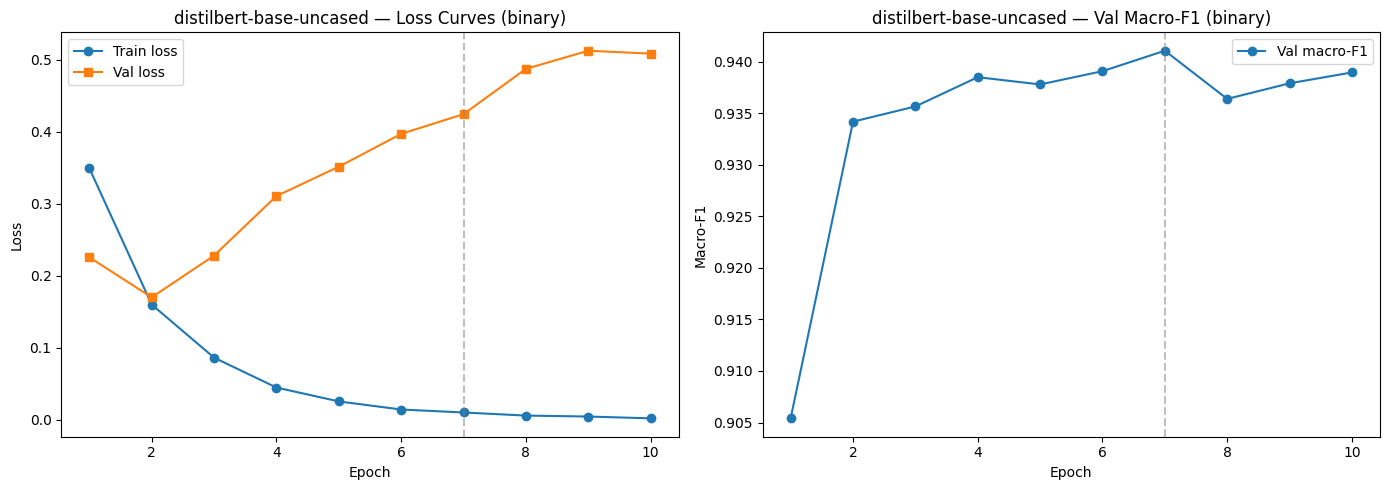


Loading best checkpoint (epoch 7, val macro-F1=0.9411)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

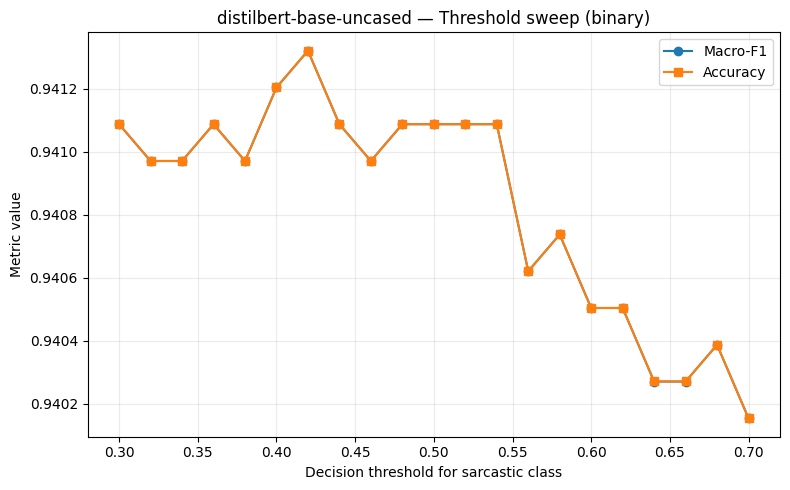

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/threshold_sweep_val.png
Applied binary threshold tuning: threshold=0.42 (selected on validation macro-F1)

=== Val (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.94      0.94      4286
    sarcastic       0.94      0.94      0.94      4286

     accuracy                           0.94      8572
    macro avg       0.94      0.94      0.94      8572
 weighted avg       0.94      0.94      0.94      8572


=== Test (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.94      0.94      0.94      4286
    sarcastic       0.94      0.94      0.94      4286

     accuracy                           0.94      8572
    macro avg       0.94      0.94      0.94      8572
 weighted avg       0.94      0.94      0.94      8572



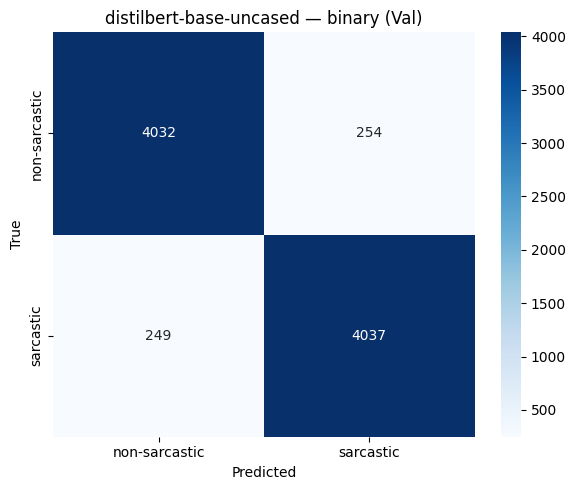

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/confusion_matrix_val.png


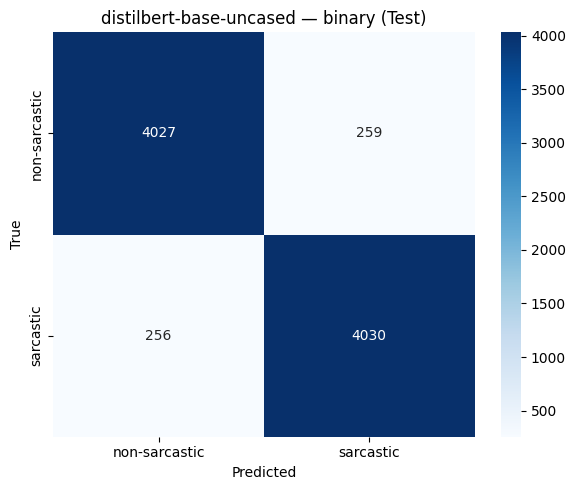

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / binary ===
  Test Accuracy   : 0.9399
  Test Macro-F1   : 0.9399
  Test Weighted-F1: 0.9399
  Threshold       : 0.42
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_binary/final_model.pth


In [ ]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
import torch
from torch.utils.data import Dataset, DataLoader


results_distilbert_binary = train_bert(
    cfg        = CFG_BINARY,
    X_train    = X_train_bin, y_train = y_train_bin,
    X_val      = X_val_bin,   y_val   = y_val_bin,
    X_test     = X_test_bin,  y_test  = y_test_bin,
    label_names= label_names_bin,
    out_dir    = BERT_OUT / "distilbert_binary",
    val_df     = val_bin,
    test_df    = test_bin,
)

## Train DistilBERT — Type Task

Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/config.json
Loading tokenizer: distilbert-base-uncased
Loading model: distilbert-base-uncased (6 labels)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5366 | val_loss=1.2710 | val_acc=0.4218 | val_macro_f1=0.4322


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best_model.pth
  ★ New best val macro-F1=0.4811 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.5958 | val_loss=1.5696 | val_acc=0.4543 | val_macro_f1=0.4867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best_model.pth
  ★ New best val macro-F1=0.4867 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/checkpoints/checkpoint_epoch_005.pt
Epoch  6/10 | train_loss=0.4524 | val_loss=1.7630 | val_acc=0.4540 | val_macro_f1=0.4874


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best_model.pth
  ★ New best val macro-F1=0.4874 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/checkpoints/checkpoint_epoch_006.pt
Epoch  7/10 | train_loss=0.3535 | val_loss=1.9612 | val_acc=0.4452 | val_macro_f1=0.4794
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/checkpoints/checkpoint_epoch_007.pt
Epoch  8/10 | train_loss=0.2742 | val_loss=2.1139 | val_acc=0.4431 | val_macro_f1=0.4743
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/checkpoints/checkpoin

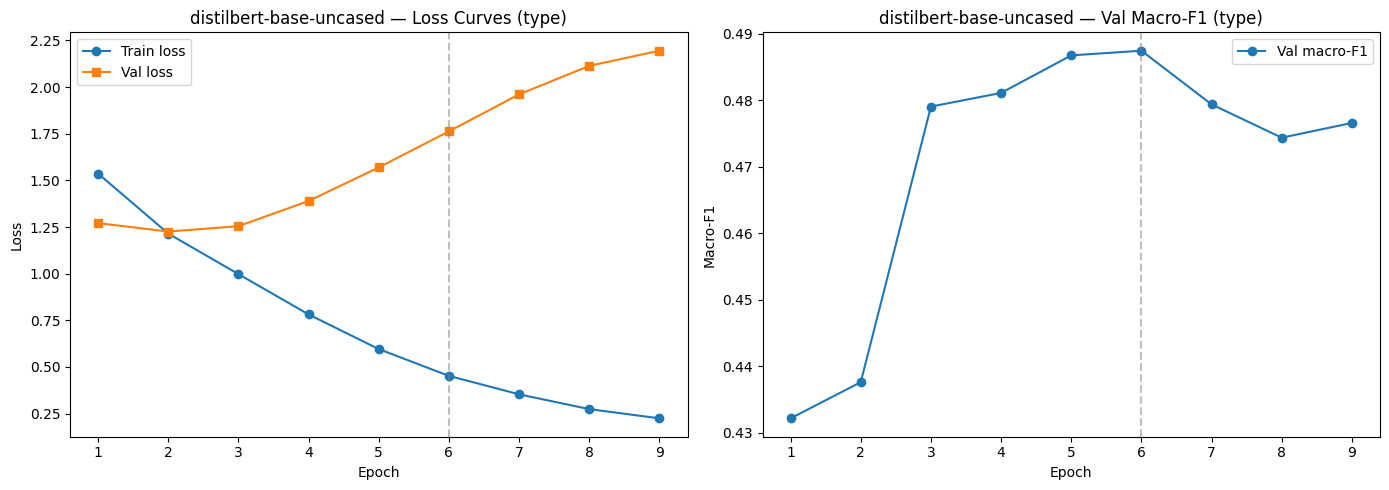


Loading best checkpoint (epoch 6, val macro-F1=0.4874)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.34      0.38      0.36       917
      overstatement       0.48      0.45      0.47       597
rhetorical_question       0.67      0.82      0.73       163
            sarcasm       0.52      0.50      0.51      1353
             satire       0.39      0.39      0.39       746
     understatement       0.48      0.44      0.46       510

           accuracy                           0.45      4286
          macro avg       0.48      0.50      0.49      4286
       weighted avg       0.46      0.45      0.45      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.36      0.41      0.38       915
      overstatement       0.46      0.45      0.46       606
rhetorical_question       0.64      0.74      0.69       169
            sarcasm       0.51      0.49      0.50      1310
             satir

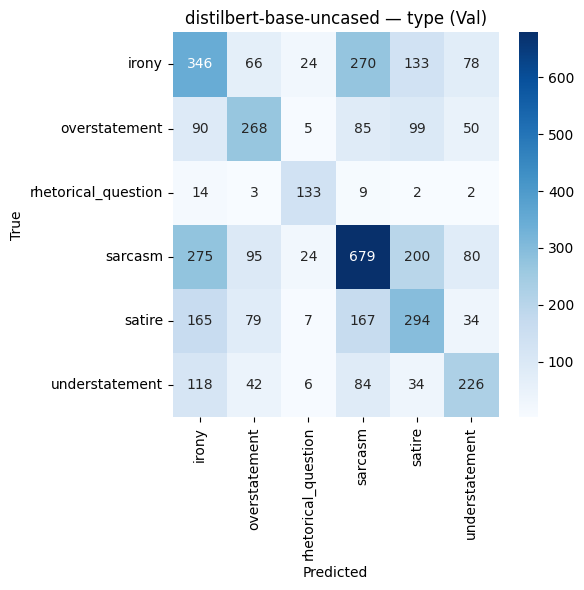

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/confusion_matrix_val.png


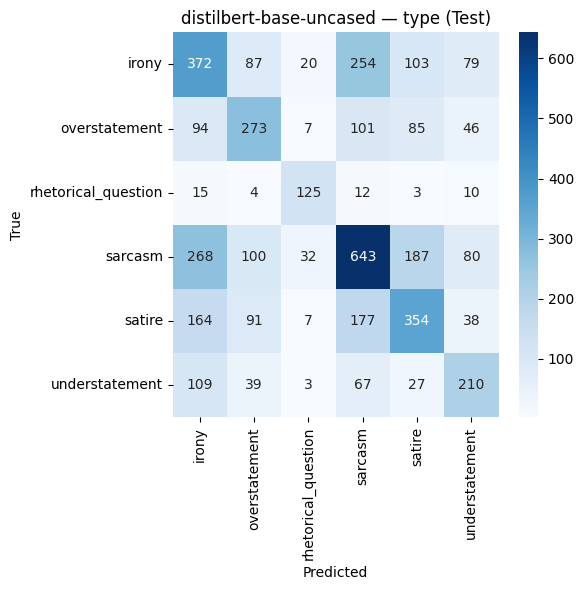

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4613
  Test Macro-F1   : 0.4887
  Test Weighted-F1: 0.4617
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type/final_model.pth


In [ ]:
results_distilbert_type = train_bert(
    cfg        = CFG_TYPE,
    X_train    = X_train_type, y_train = y_train_type,
    X_val      = X_val_type,   y_val   = y_val_type,
    X_test     = X_test_type,  y_test  = y_test_type,
    label_names= STRATEGY_LABELS,
    out_dir    = BERT_OUT / "distilbert_type",
    val_df     = val_type,
    test_df    = test_type,
)

### Iteration 2 — Type-task loss-weighting ablation

This ablation changes **only** the type-task class-weighting scheme while holding the encoder, batch size, learning rate, max length, early stopping, scheduler, and split fixed.

Modes tested:
- `none`
- `inverse`
- `sqrt_inverse`


In [ ]:
TYPE_WEIGHT_SUMMARY = summarize_class_weight_modes(
    y_train=y_train_type,
    label_names=STRATEGY_LABELS,
    modes=["none", "inverse", "sqrt_inverse"],
)
display(TYPE_WEIGHT_SUMMARY)



,mode,label_idx,label,train_count,weight
0,none,0,irony,4307,1.000000
1,none,1,overstatement,2807,1.000000
2,none,2,rhetorical_question,709,1.000000
3,none,3,sarcasm,6169,1.000000
4,none,4,satire,3673,1.000000
5,none,5,understatement,2333,1.000000
6,inverse,0,irony,4307,0.773857
7,inverse,1,overstatement,2807,1.187389
8,inverse,2,rhetorical_question,709,4.700987
9,inverse,3,sarcasm,6169,0.540282


In [ ]:
TYPE_WEIGHTING_CONFIGS = {
    "none": TrainConfig(
        model_name="distilbert-base-uncased",
        task="type",
        batch_size=CFG_TYPE.batch_size,
        lr=CFG_TYPE.lr,
        weight_decay=CFG_TYPE.weight_decay,
        warmup_ratio=CFG_TYPE.warmup_ratio,
        epochs=CFG_TYPE.epochs,
        patience=CFG_TYPE.patience,
        seed=CFG_TYPE.seed,
        class_weight_mode="none",
        checkpoint_every=CFG_TYPE.checkpoint_every,
        binary_threshold_tuning=False,
    ),
    "inverse": TrainConfig(
        model_name="distilbert-base-uncased",
        task="type",
        batch_size=CFG_TYPE.batch_size,
        lr=CFG_TYPE.lr,
        weight_decay=CFG_TYPE.weight_decay,
        warmup_ratio=CFG_TYPE.warmup_ratio,
        epochs=CFG_TYPE.epochs,
        patience=CFG_TYPE.patience,
        seed=CFG_TYPE.seed,
        class_weight_mode="inverse",
        checkpoint_every=CFG_TYPE.checkpoint_every,
        binary_threshold_tuning=False,
    ),
    "sqrt_inverse": TrainConfig(
        model_name="distilbert-base-uncased",
        task="type",
        batch_size=CFG_TYPE.batch_size,
        lr=CFG_TYPE.lr,
        weight_decay=CFG_TYPE.weight_decay,
        warmup_ratio=CFG_TYPE.warmup_ratio,
        epochs=CFG_TYPE.epochs,
        patience=CFG_TYPE.patience,
        seed=CFG_TYPE.seed,
        class_weight_mode="sqrt_inverse",
        checkpoint_every=CFG_TYPE.checkpoint_every,
        binary_threshold_tuning=False,
    ),
}

TYPE_WEIGHTING_CONFIGS


{'none': TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='type', class_weight_mode='none', checkpoint_every=1, binary_threshold_tuning=False, threshold_min=0.3, threshold_max=0.7, threshold_step=0.02),
 'inverse': TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='type', class_weight_mode='inverse', checkpoint_every=1, binary_threshold_tuning=False, threshold_min=0.3, threshold_max=0.7, threshold_step=0.02),
 'sqrt_inverse': TrainConfig(model_name='distilbert-base-uncased', max_length=128, batch_size=32, lr=2e-05, weight_decay=0.01, warmup_ratio=0.1, epochs=10, patience=3, seed=42, task='type', class_weight_mode='sqrt_inverse', checkpoint_every=1, binary_threshold_tuning=False, threshold_min=0.3, threshold_max=0.7, threshold_step=0.02)}

Running type weighting ablation: none
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/config.json
Loading tokenizer: distilbert-base-uncased
Loading model: distilbert-base-uncased (6 labels)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/10 | train_loss=1.5413 | val_loss=1.3232 | val_acc=0.4568 | val_macro_f1=0.4682


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best_model.pth
  ★ New best val macro-F1=0.4682 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2639 | val_loss=1.3033 | val_acc=0.4582 | val_macro_f1=0.4664
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=1.0517 | val_loss=1.3190 | val_acc=0.4687 | val_macro_f1=0.5043


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best_model.pth
  ★ New best val macro-F1=0.5043 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.8189 | val_loss=1.4607 | val_acc=0.4631 | val_macro_f1=0.4945
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.5946 | val_loss=1.6725 | val_acc=0.4587 | val_macro_f1=0.4981
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
Saved checkpoi

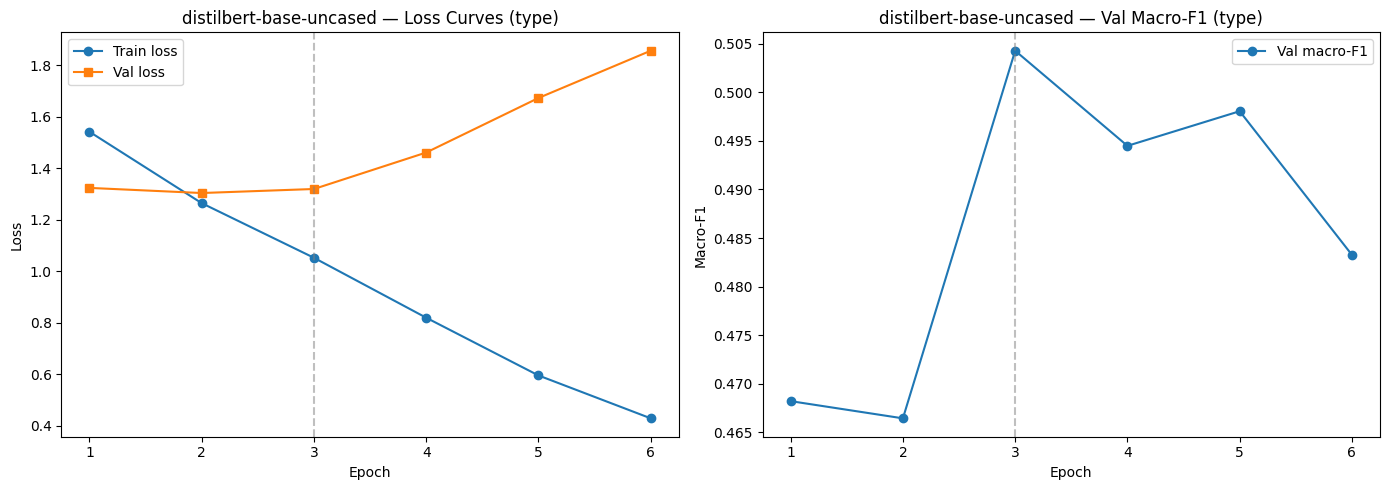


Loading best checkpoint (epoch 3, val macro-F1=0.5043)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.35      0.40      0.37       917
      overstatement       0.52      0.46      0.49       597
rhetorical_question       0.67      0.85      0.75       163
            sarcasm       0.52      0.51      0.51      1353
             satire       0.41      0.44      0.42       746
     understatement       0.54      0.43      0.48       510

           accuracy                           0.47      4286
          macro avg       0.50      0.51      0.50      4286
       weighted avg       0.47      0.47      0.47      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.40      0.38       915
      overstatement       0.50      0.48      0.49       606
rhetorical_question       0.64      0.73      0.68       169
            sarcasm       0.51      0.52      0.51      1310
             satir

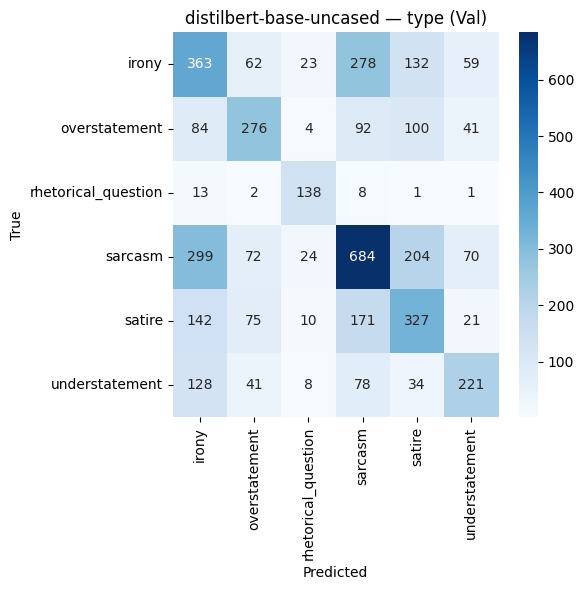

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/confusion_matrix_val.png


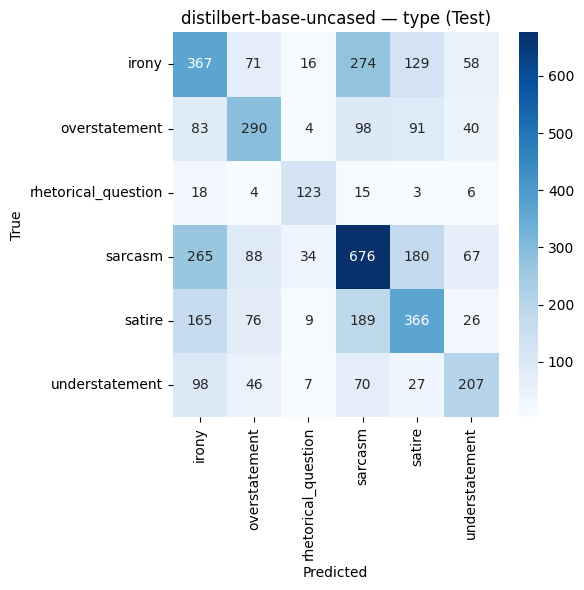

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4734
  Test Macro-F1   : 0.5001
  Test Weighted-F1: 0.4736
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/final_model.pth
Running type weighting ablation: inverse
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/config.json
Loading tokenizer: distilbert-base-unc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5271 | val_loss=1.2660 | val_acc=0.4204 | val_macro_f1=0.4300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best_model.pth
  ★ New best val macro-F1=0.4300 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2073 | val_loss=1.2269 | val_acc=0.4382 | val_macro_f1=0.4517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best_model.pth
  ★ New best val macro-F1=0.4517 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=0.9907 | val_loss=1.2714 | val_acc=0.4503 | val_macro_f1=0.4896


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best_model.pth
  ★ New best val macro-F1=0.4896 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.7751 | val_loss=1.3891 | val_acc=0.4515 | val_macro_f1=0.4860
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.5881 | val_loss=1.5740 | val_acc=0.4538 | val_macro_f1=0.4869
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/l

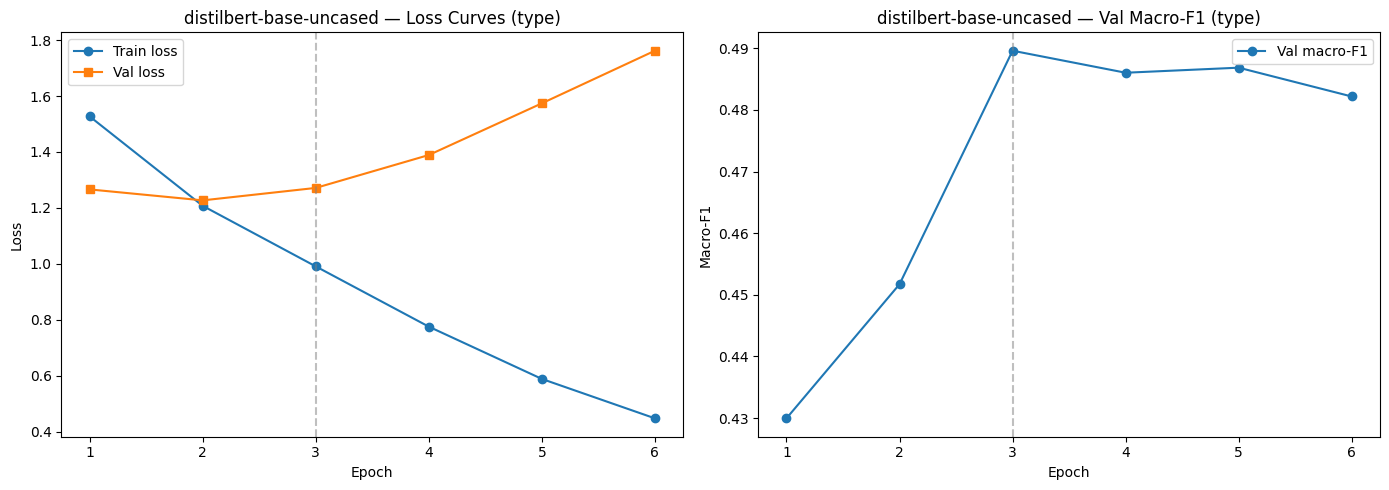


Loading best checkpoint (epoch 3, val macro-F1=0.4896)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.34      0.36      0.35       917
      overstatement       0.47      0.50      0.49       597
rhetorical_question       0.62      0.88      0.73       163
            sarcasm       0.56      0.41      0.47      1353
             satire       0.38      0.48      0.42       746
     understatement       0.46      0.49      0.48       510

           accuracy                           0.45      4286
          macro avg       0.47      0.52      0.49      4286
       weighted avg       0.46      0.45      0.45      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.40      0.39       915
      overstatement       0.48      0.51      0.49       606
rhetorical_question       0.62      0.78      0.69       169
            sarcasm       0.55      0.41      0.47      1310
             satir

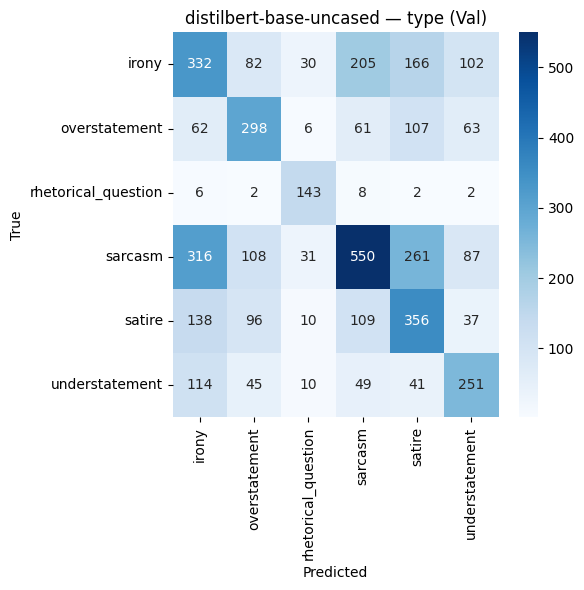

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/confusion_matrix_val.png


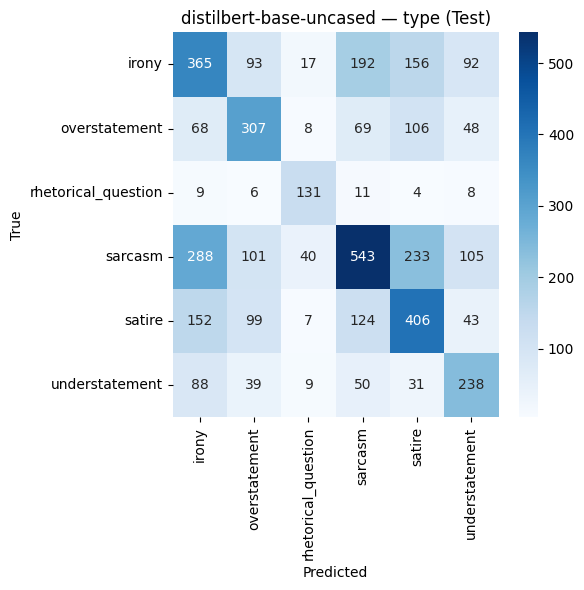

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4643
  Test Macro-F1   : 0.4965
  Test Weighted-F1: 0.4638
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_inverse/final_model.pth
Running type weighting ablation: sqrt_inverse
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/config.json
Loading 

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: sqrt_inverse
Class weights: [0.88  1.09  2.168 0.735 0.953 1.195]
Epoch  1/10 | train_loss=1.5584 | val_loss=1.3322 | val_acc=0.4386 | val_macro_f1=0.4416


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best_model.pth
  ★ New best val macro-F1=0.4416 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2693 | val_loss=1.2992 | val_acc=0.4498 | val_macro_f1=0.4590


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best_model.pth
  ★ New best val macro-F1=0.4590 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=1.0586 | val_loss=1.3181 | val_acc=0.4666 | val_macro_f1=0.4996


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best_model.pth
  ★ New best val macro-F1=0.4996 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.8250 | val_loss=1.4371 | val_acc=0.4655 | val_macro_f1=0.4952
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.6137 | val_loss=1.6246 | val_acc=0.4627 | val_macro_f1=0.4919
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/di

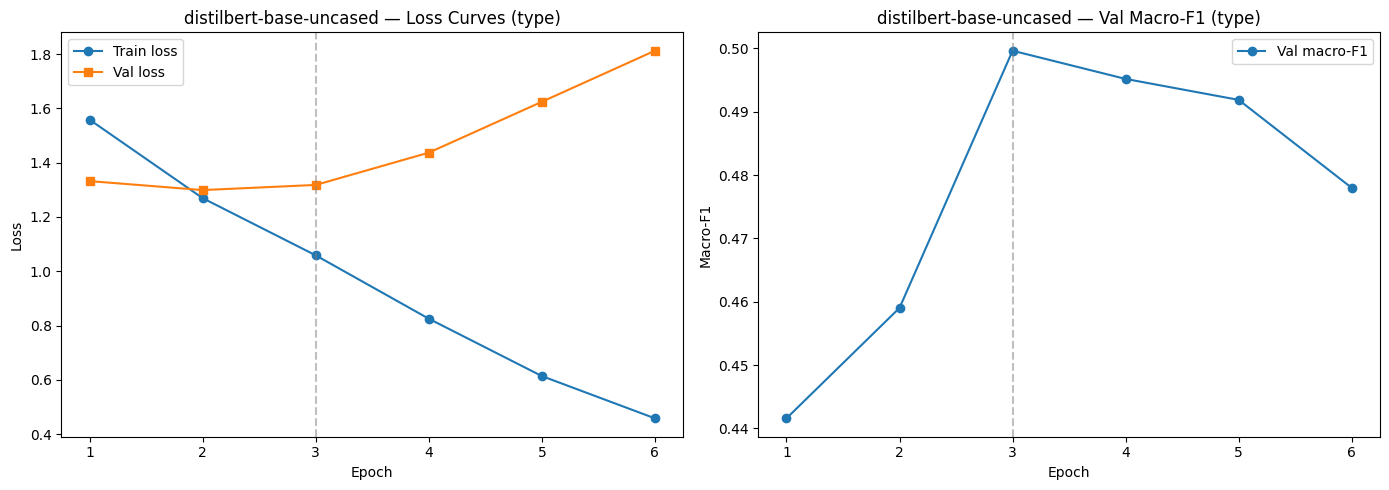


Loading best checkpoint (epoch 3, val macro-F1=0.4996)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.35      0.39      0.37       917
      overstatement       0.48      0.52      0.50       597
rhetorical_question       0.60      0.89      0.71       163
            sarcasm       0.56      0.46      0.50      1353
             satire       0.41      0.45      0.43       746
     understatement       0.51      0.46      0.48       510

           accuracy                           0.47      4286
          macro avg       0.48      0.53      0.50      4286
       weighted avg       0.47      0.47      0.47      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.43      0.40       915
      overstatement       0.44      0.52      0.48       606
rhetorical_question       0.59      0.80      0.68       169
            sarcasm       0.53      0.44      0.48      1310
             satir

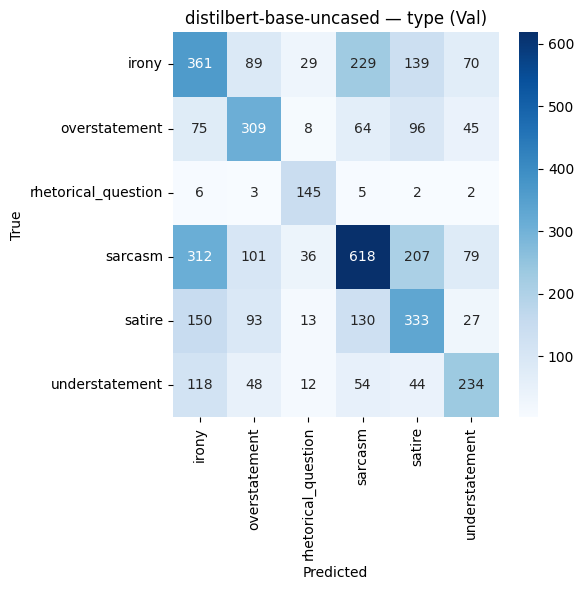

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/confusion_matrix_val.png


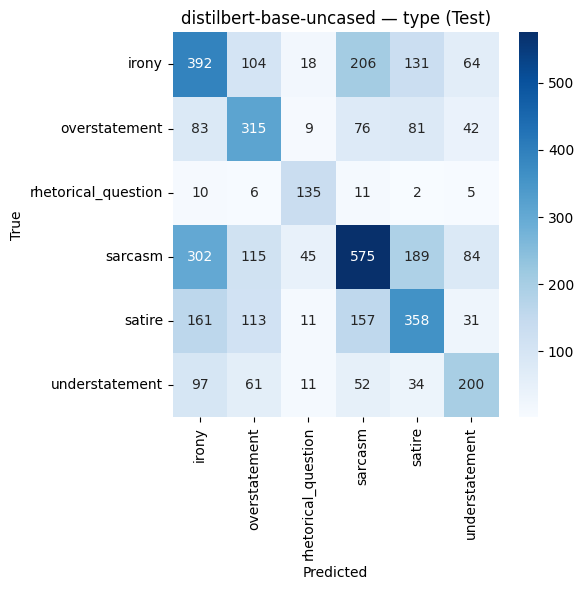

Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4608
  Test Macro-F1   : 0.4886
  Test Weighted-F1: 0.4605
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_sqrt_inverse/final_model.pth


{'none': {'model': 'distilbert-base-uncased',
  'task': 'type',
  'best_epoch': 3,
  'best_val_f1_macro': 0.5042745775486162,
  'decision_rule': {'enabled': False,
   'selection_metric': None,
   'selected_threshold': 0.5,
   'search_range': None,
   'sweep_csv': None,
   'sweep_plot': None},
  'val': {'loss': 1.3189793620536576,
   'accuracy': 0.4687354176388241,
   'f1_macro': 0.5042745775486162,
   'f1_weighted': 0.4693470101229207,
   'precision_macro': 0.5014643573428353,
   'recall_macro': 0.5136679581995298},
  'test': {'loss': 1.3162092659900437,
   'accuracy': 0.473401773215119,
   'f1_macro': 0.5000501197893831,
   'f1_weighted': 0.473631114936015,
   'precision_macro': 0.49894151642173723,
   'recall_macro': 0.503143367356751},
  'artifacts': {'best_checkpoint_pt': '/content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/best.pt',
   'last_checkpoint_pt': '/content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/last.pt',
   'best_model_pth': '/c

In [ ]:
type_weighting_results = {}

for mode, cfg in TYPE_WEIGHTING_CONFIGS.items():
    print("=" * 100)
    print(f"Running type weighting ablation: {mode}")
    out_dir = BERT_OUT / f"distilbert_type_weight_{mode}"
    type_weighting_results[mode] = train_bert(
        cfg        = cfg,
        X_train    = X_train_type, y_train = y_train_type,
        X_val      = X_val_type,   y_val   = y_val_type,
        X_test     = X_test_type,  y_test  = y_test_type,
        label_names= STRATEGY_LABELS,
        out_dir    = out_dir,
        val_df     = val_type,
        test_df    = test_type,
    )

type_weighting_results


In [ ]:
type_weighting_summary = (
    pd.DataFrame([
        {
            "mode": mode,
            "val_macro_f1": float(res["val"]["f1_macro"]),
            "val_weighted_f1": float(res["val"]["f1_weighted"]),
            "val_accuracy": float(res["val"]["accuracy"]),
            "test_macro_f1": float(res["test"]["f1_macro"]),
            "test_weighted_f1": float(res["test"]["f1_weighted"]),
            "test_accuracy": float(res["test"]["accuracy"]),
            "best_epoch": int(res["best_epoch"]),
        }
        for mode, res in type_weighting_results.items()
    ])
    .sort_values(by=["test_macro_f1", "val_macro_f1"], ascending=False)
    .reset_index(drop=True)
)

display(type_weighting_summary)
type_weighting_summary.to_csv(BERT_OUT / "distilbert_type_weighting_ablation_summary.csv", index=False)
print("Saved:", BERT_OUT / "distilbert_type_weighting_ablation_summary.csv")


,mode,val_macro_f1,val_weighted_f1,val_accuracy,test_macro_f1,test_weighted_f1,test_accuracy,best_epoch
0,none,0.504275,0.469347,0.468735,0.500050,0.473631,0.473402,3
1,inverse,0.489612,0.449951,0.450303,0.496491,0.463760,0.464302,3
2,sqrt_inverse,0.499648,0.466879,0.466636,0.488636,0.460455,0.460803,3


Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weighting_ablation_summary.csv


### Iteration 3 — Multi-seed confirmation of type-task weighting

This section confirms whether the apparent one-seed advantage of `class_weight_mode="none"` over `inverse` is real or just seed noise.

Only these two modes are compared:
- `none`
- `inverse`

All other settings are held fixed.

In [ ]:
TYPE_WEIGHT_CONFIRM_SEEDS = [42, 1337, 2027]

TYPE_WEIGHT_CONFIRM_VARIANTS = {
    "distilbert_type_weight_none": {
        "model_name": "distilbert-base-uncased",
        "task": "type",
        "class_weight_mode": "none",
        "binary_threshold_tuning": False,
    },
    "distilbert_type_weight_inverse": {
        "model_name": "distilbert-base-uncased",
        "task": "type",
        "class_weight_mode": "inverse",
        "binary_threshold_tuning": False,
    },
}

Running variant=distilbert_type_weight_none | seed=42
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/config.json
Loading tokenizer: distilbert-base-uncased
Loading model: distilbert-base-uncased (6 labels)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/10 | train_loss=1.5466 | val_loss=1.3222 | val_acc=0.4529 | val_macro_f1=0.4619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best_model.pth
  ★ New best val macro-F1=0.4619 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2570 | val_loss=1.2982 | val_acc=0.4664 | val_macro_f1=0.4724


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best_model.pth
  ★ New best val macro-F1=0.4724 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=1.0412 | val_loss=1.3377 | val_acc=0.4757 | val_macro_f1=0.5022


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best_model.pth
  ★ New best val macro-F1=0.5022 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.7987 | val_loss=1.4966 | val_acc=0.4615 | val_macro_f1=0.4917
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_

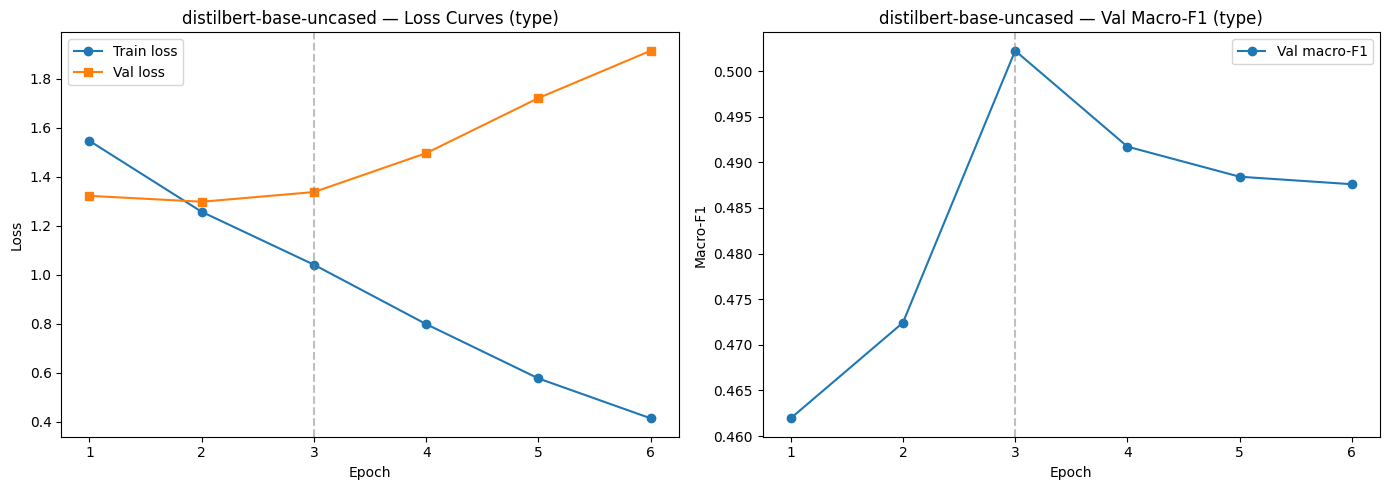


Loading best checkpoint (epoch 3, val macro-F1=0.5022)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.38      0.38       917
      overstatement       0.51      0.46      0.48       597
rhetorical_question       0.61      0.87      0.71       163
            sarcasm       0.53      0.53      0.53      1353
             satire       0.42      0.44      0.43       746
     understatement       0.54      0.44      0.48       510

           accuracy                           0.48      4286
          macro avg       0.50      0.52      0.50      4286
       weighted avg       0.48      0.48      0.47      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.39      0.38       915
      overstatement       0.49      0.47      0.48       606
rhetorical_question       0.62      0.76      0.68       169
            sarcasm       0.51      0.52      0.51      1310
             satir

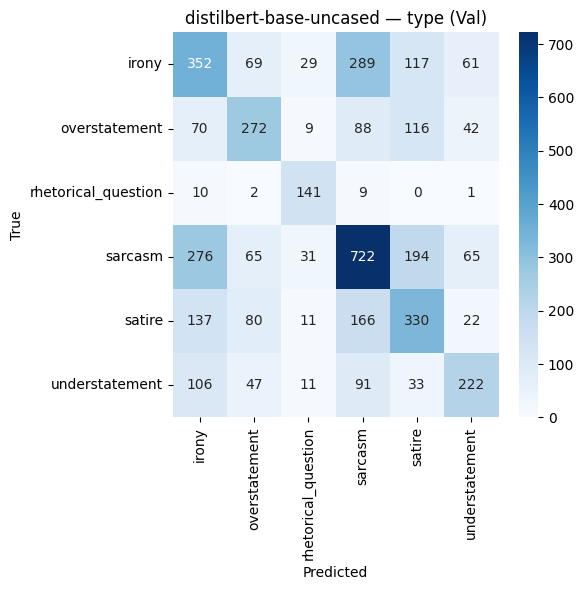

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/confusion_matrix_val.png


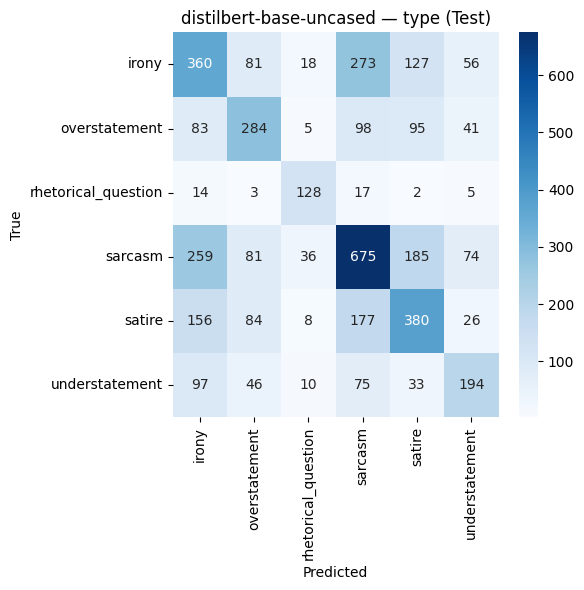

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4715
  Test Macro-F1   : 0.4960
  Test Weighted-F1: 0.4711
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed42/final_model.pth
Running variant=distilbert_type_weight_none | seed=1337
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/seeded

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/10 | train_loss=1.5345 | val_loss=1.3396 | val_acc=0.4494 | val_macro_f1=0.4645


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best_model.pth
  ★ New best val macro-F1=0.4645 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2645 | val_loss=1.2933 | val_acc=0.4676 | val_macro_f1=0.4860


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best_model.pth
  ★ New best val macro-F1=0.4860 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=1.0523 | val_loss=1.3346 | val_acc=0.4736 | val_macro_f1=0.4976


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best_model.pth
  ★ New best val macro-F1=0.4976 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.8260 | val_loss=1.4921 | val_acc=0.4652 | val_macro_f1=0.4965
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/checkpoints/checkpoint_epoch_004.pt
Epoch  5

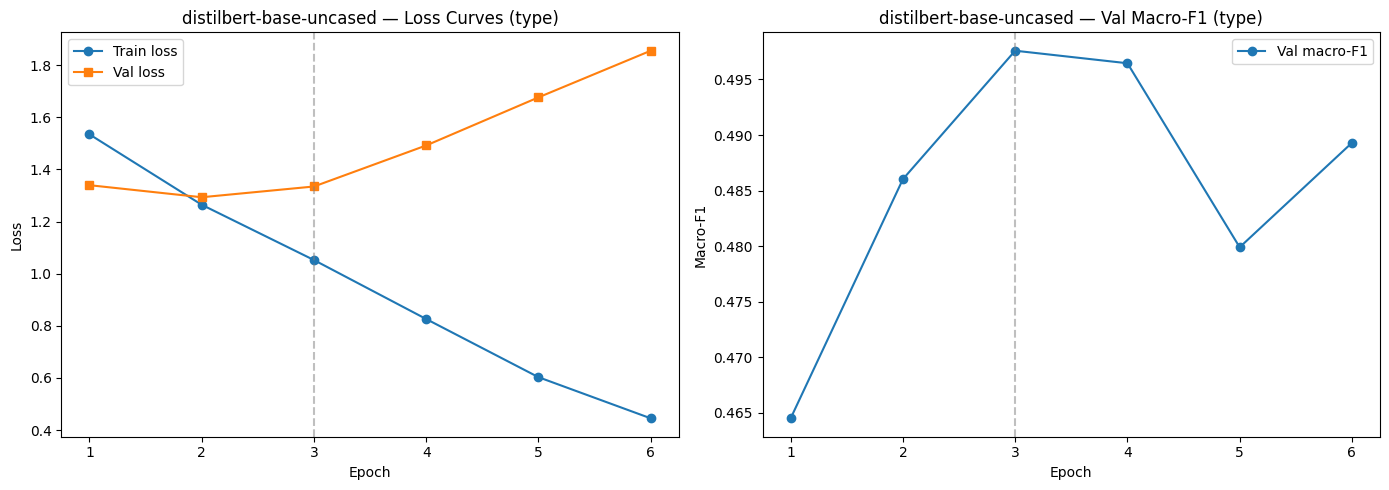


Loading best checkpoint (epoch 3, val macro-F1=0.4976)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.39      0.28      0.33       917
      overstatement       0.44      0.55      0.49       597
rhetorical_question       0.63      0.86      0.73       163
            sarcasm       0.50      0.57      0.53      1353
             satire       0.45      0.37      0.41       746
     understatement       0.51      0.48      0.50       510

           accuracy                           0.47      4286
          macro avg       0.49      0.52      0.50      4286
       weighted avg       0.47      0.47      0.46      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.41      0.31      0.35       915
      overstatement       0.43      0.55      0.49       606
rhetorical_question       0.63      0.76      0.69       169
            sarcasm       0.50      0.57      0.53      1310
             satir

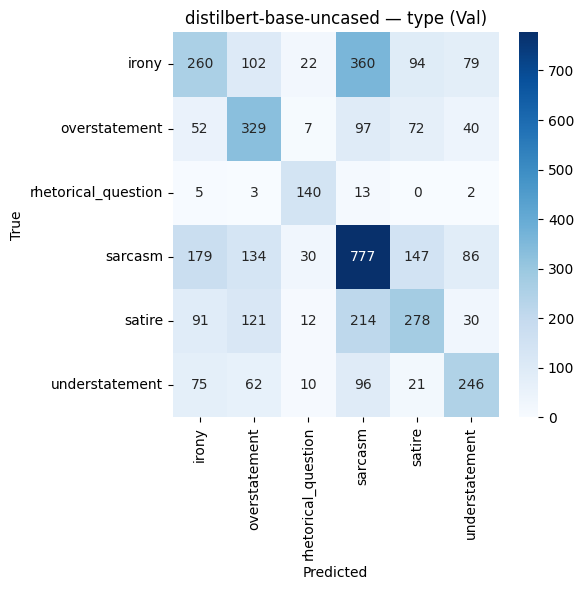

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/confusion_matrix_val.png


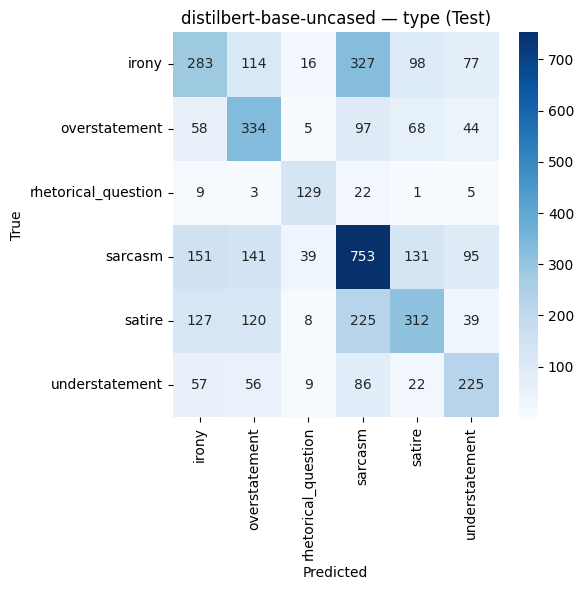

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4750
  Test Macro-F1   : 0.4945
  Test Weighted-F1: 0.4681
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed1337/final_model.pth
Running variant=distilbert_type_weight_none | seed=2027
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/b

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/10 | train_loss=1.5437 | val_loss=1.3200 | val_acc=0.4575 | val_macro_f1=0.4619


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best_model.pth
  ★ New best val macro-F1=0.4619 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2708 | val_loss=1.2863 | val_acc=0.4757 | val_macro_f1=0.4972


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best_model.pth
  ★ New best val macro-F1=0.4972 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=1.0577 | val_loss=1.3298 | val_acc=0.4713 | val_macro_f1=0.4910
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/checkpoints/checkpoint_epoch_003.pt
Epoch  4

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best_model.pth
  ★ New best val macro-F1=0.5001 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.6059 | val_loss=1.6501 | val_acc=0.4568 | val_macro_f1=0.4907
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/checkpoints/checkpoint_epoch_005.pt
Epoch  6

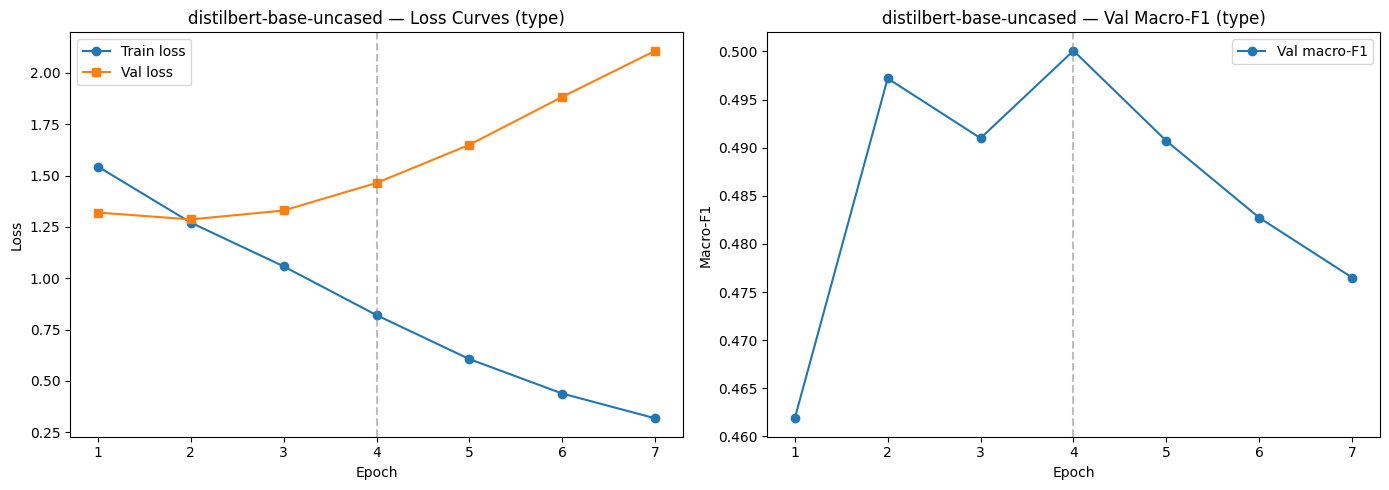


Loading best checkpoint (epoch 4, val macro-F1=0.5001)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.37      0.37       917
      overstatement       0.44      0.55      0.49       597
rhetorical_question       0.77      0.73      0.75       163
            sarcasm       0.51      0.48      0.50      1353
             satire       0.39      0.43      0.41       746
     understatement       0.56      0.43      0.48       510

           accuracy                           0.46      4286
          macro avg       0.51      0.50      0.50      4286
       weighted avg       0.47      0.46      0.46      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.39      0.38      0.38       915
      overstatement       0.42      0.53      0.47       606
rhetorical_question       0.71      0.66      0.68       169
            sarcasm       0.52      0.48      0.50      1310
             satir

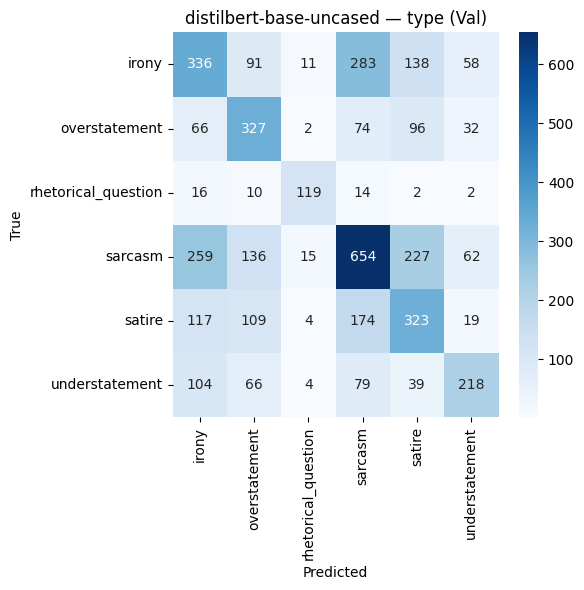

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/confusion_matrix_val.png


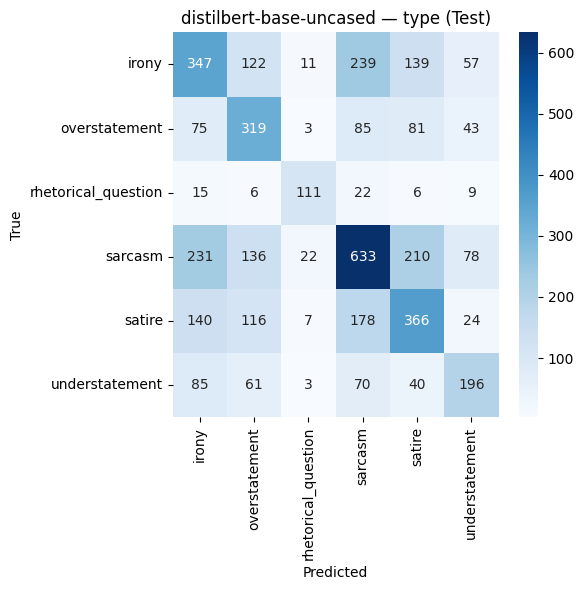

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4601
  Test Macro-F1   : 0.4872
  Test Weighted-F1: 0.4605
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_none_seed2027/final_model.pth
Running variant=distilbert_type_weight_inverse | seed=42
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5326 | val_loss=1.2848 | val_acc=0.4193 | val_macro_f1=0.4293


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best_model.pth
  ★ New best val macro-F1=0.4293 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=1.2176 | val_loss=1.2398 | val_acc=0.4144 | val_macro_f1=0.4226
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/checkpoints/checkpoint_epoch_002.pt
Ep

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best_model.pth
  ★ New best val macro-F1=0.4872 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.7957 | val_loss=1.4025 | val_acc=0.4519 | val_macro_f1=0.4885


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best_model.pth
  ★ New best val macro-F1=0.4885 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.6112 | val_loss=1.5790 | val_acc=0.4447 | val_macro_f1=0.4745
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/checkpoints/checkpoint_epoch_005.pt
Ep

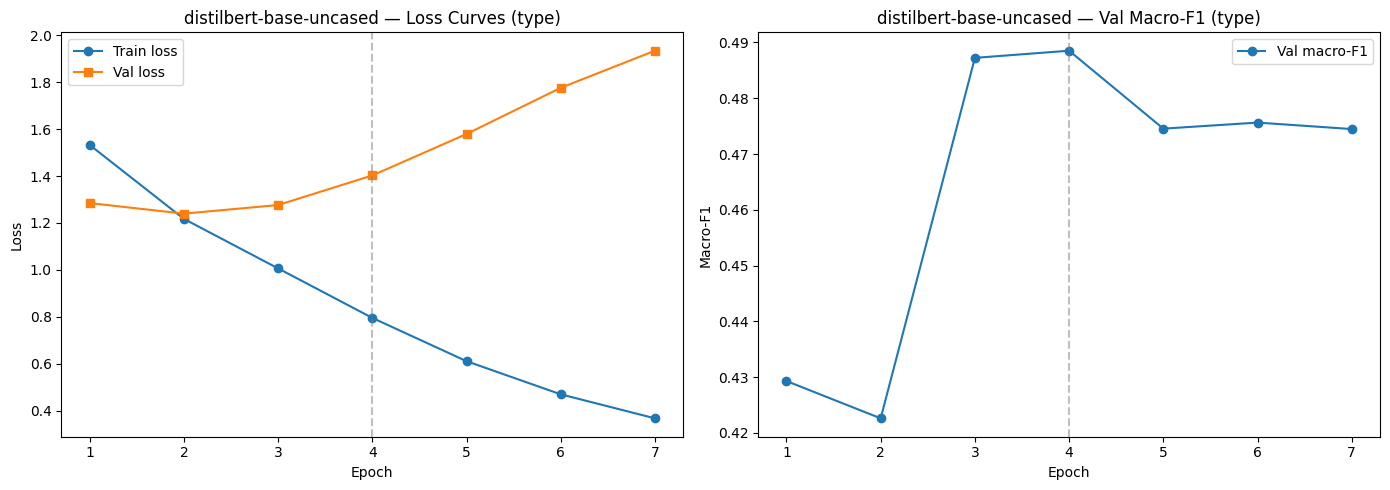


Loading best checkpoint (epoch 4, val macro-F1=0.4885)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.33      0.35       917
      overstatement       0.43      0.52      0.47       597
rhetorical_question       0.68      0.81      0.74       163
            sarcasm       0.56      0.43      0.49      1353
             satire       0.38      0.46      0.42       746
     understatement       0.41      0.52      0.46       510

           accuracy                           0.45      4286
          macro avg       0.48      0.51      0.49      4286
       weighted avg       0.46      0.45      0.45      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.33      0.35       915
      overstatement       0.43      0.53      0.48       606
rhetorical_question       0.65      0.72      0.68       169
            sarcasm       0.54      0.42      0.47      1310
             satir

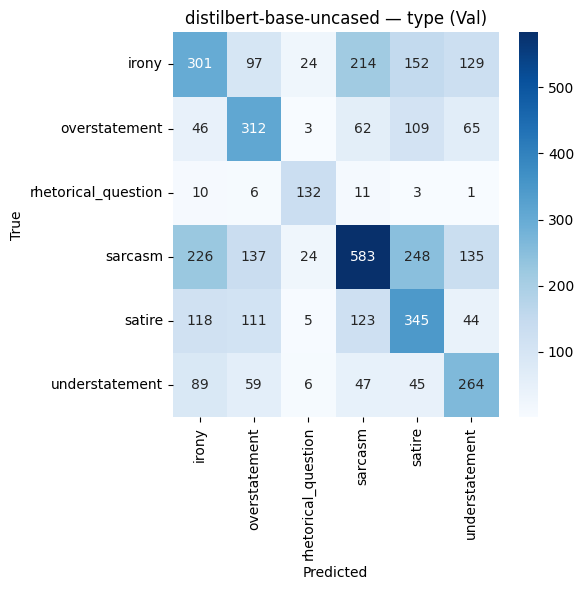

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/confusion_matrix_val.png


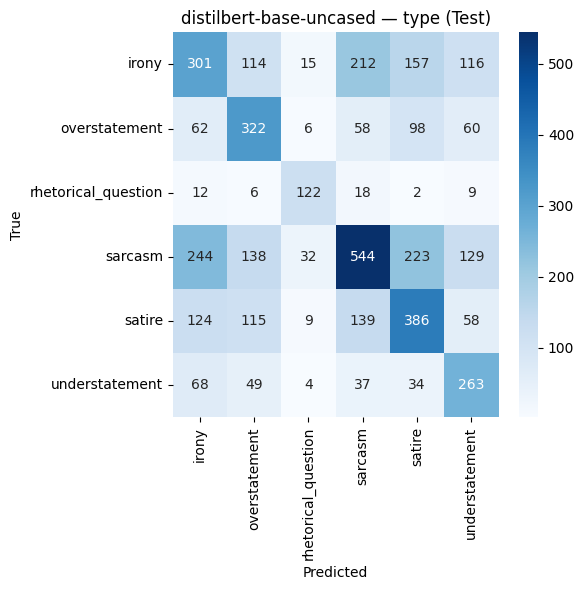

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4522
  Test Macro-F1   : 0.4845
  Test Weighted-F1: 0.4500
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed42/final_model.pth
Running variant=distilbert_type_weight_inverse | seed=1337
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/o

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5250 | val_loss=1.2735 | val_acc=0.4151 | val_macro_f1=0.4417


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best_model.pth
  ★ New best val macro-F1=0.4740 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.7937 | val_loss=1.3946 | val_acc=0.4461 | val_macro_f1=0.4817


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best_model.pth
  ★ New best val macro-F1=0.4817 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.6016 | val_loss=1.5423 | val_acc=0.4540 | val_macro_f1=0.4809
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/checkpoints/checkpoint_epo

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best_model.pth
  ★ New best val macro-F1=0.4843 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/checkpoints/checkpoint_epoch_007.pt
Epoch  8/10 | train_loss=0.2852 | val_loss=2.0900 | val_acc=0.4435 | val_macro_f1=0.4795
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/checkpoints/checkpoint_epo

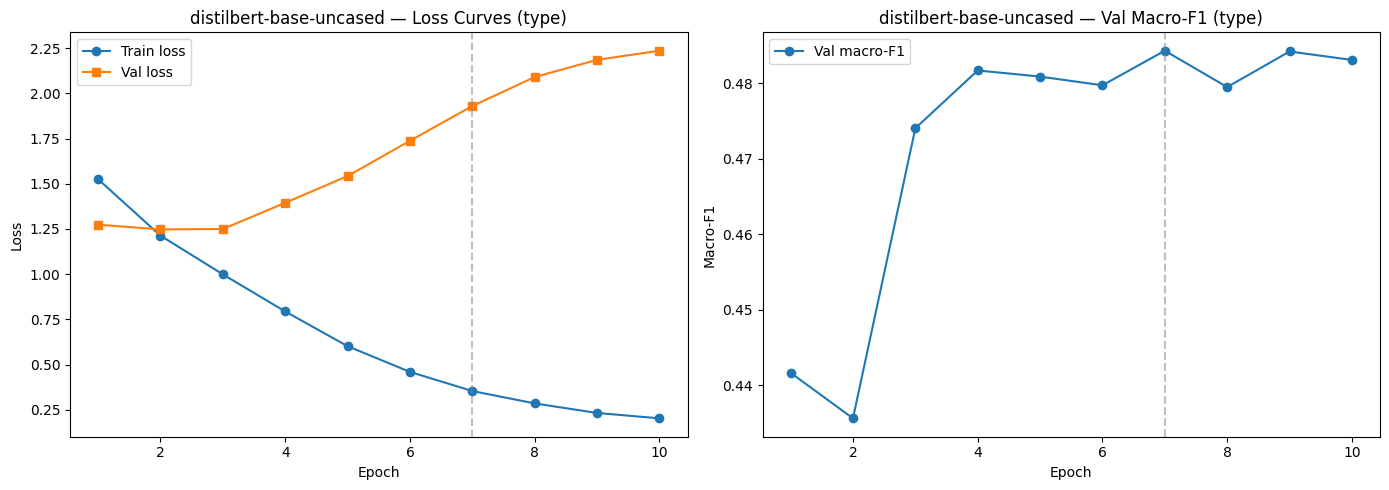


Loading best checkpoint (epoch 7, val macro-F1=0.4843)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.34      0.50      0.40       917
      overstatement       0.47      0.46      0.46       597
rhetorical_question       0.66      0.82      0.73       163
            sarcasm       0.53      0.42      0.47      1353
             satire       0.41      0.35      0.38       746
     understatement       0.51      0.43      0.46       510

           accuracy                           0.45      4286
          macro avg       0.49      0.50      0.48      4286
       weighted avg       0.46      0.45      0.45      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.34      0.50      0.40       915
      overstatement       0.47      0.48      0.47       606
rhetorical_question       0.64      0.72      0.67       169
            sarcasm       0.51      0.42      0.46      1310
             satir

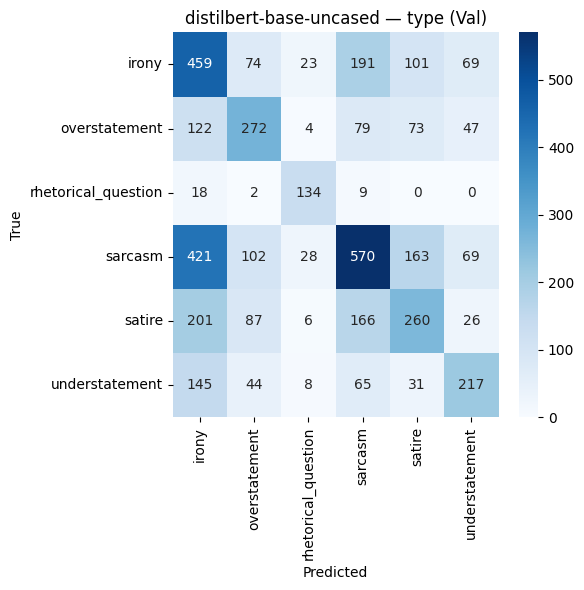

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/confusion_matrix_val.png


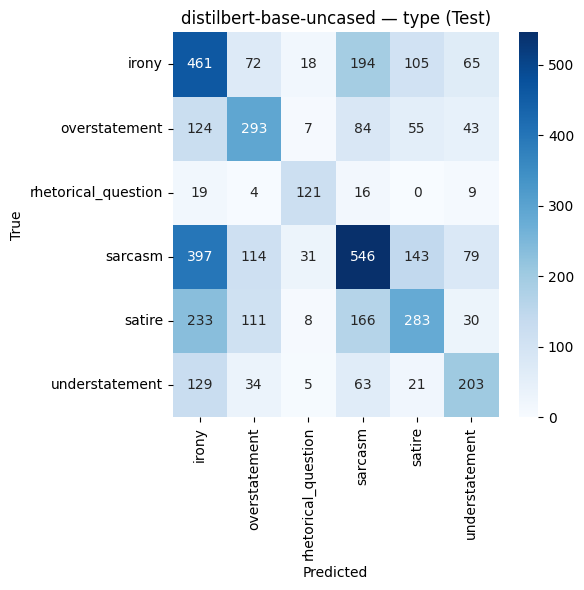

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4449
  Test Macro-F1   : 0.4776
  Test Weighted-F1: 0.4455
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed1337/final_model.pth
Running variant=distilbert_type_weight_inverse | seed=2027
Using device: cuda
Artifacts will be saved under: /content/drive/MyDriv

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5284 | val_loss=1.2819 | val_acc=0.4069 | val_macro_f1=0.4467


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best_model.pth
  ★ New best val macro-F1=0.4478 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=0.9988 | val_loss=1.2648 | val_acc=0.4526 | val_macro_f1=0.4809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best_model.pth
  ★ New best val macro-F1=0.4809 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.7808 | val_loss=1.3969 | val_acc=0.4540 | val_macro_f1=0.4864


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best_model.pth
  ★ New best val macro-F1=0.4864 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.5963 | val_loss=1.5568 | val_acc=0.4496 | val_macro_f1=0.4820
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/checkpoints/checkpoint_epo

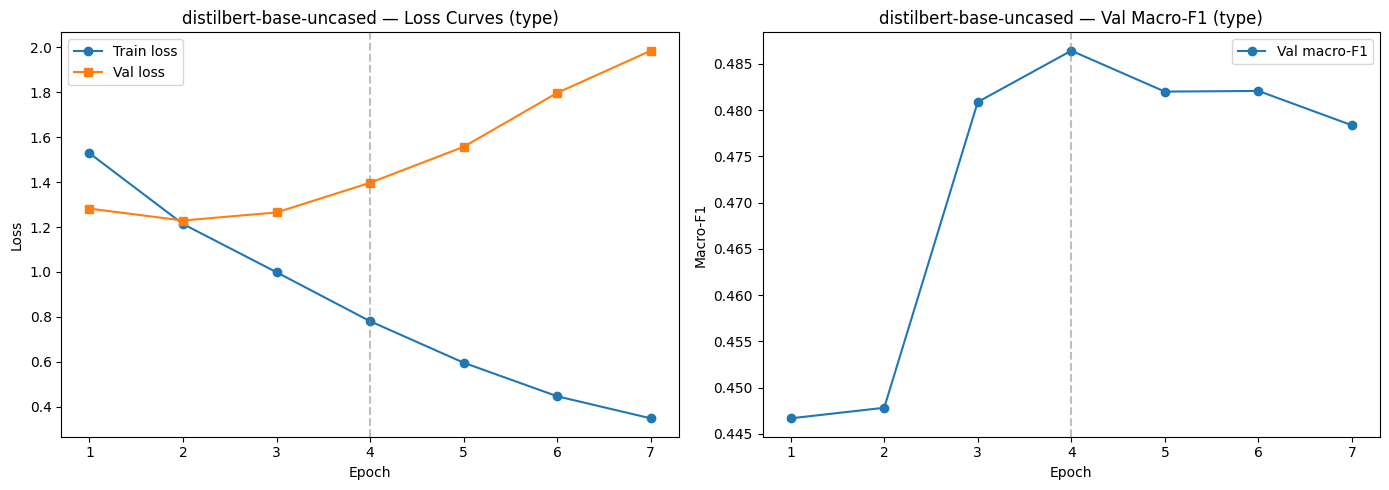


Loading best checkpoint (epoch 4, val macro-F1=0.4864)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.37      0.34      0.35       917
      overstatement       0.40      0.55      0.47       597
rhetorical_question       0.63      0.86      0.73       163
            sarcasm       0.55      0.45      0.49      1353
             satire       0.45      0.39      0.42       746
     understatement       0.41      0.52      0.46       510

           accuracy                           0.45      4286
          macro avg       0.47      0.52      0.49      4286
       weighted avg       0.46      0.45      0.45      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.35      0.36       915
      overstatement       0.39      0.57      0.46       606
rhetorical_question       0.60      0.74      0.66       169
            sarcasm       0.53      0.42      0.47      1310
             satir

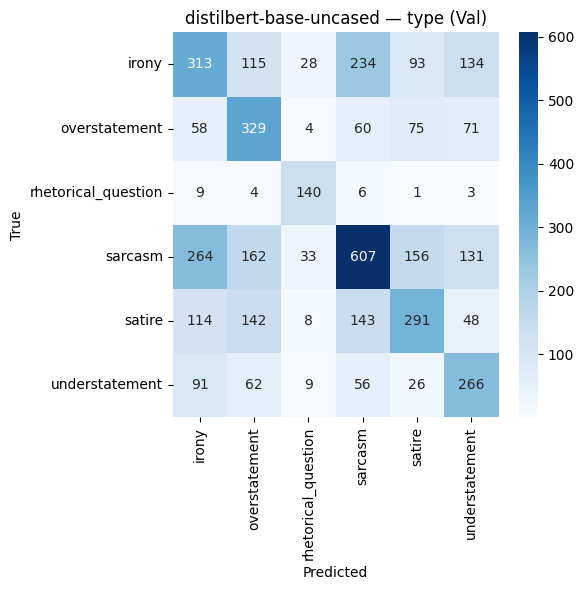

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/confusion_matrix_val.png


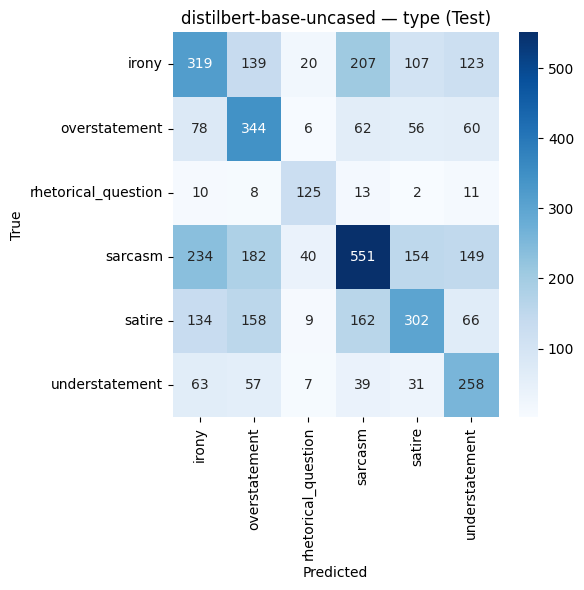

Saved: /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4431
  Test Macro-F1   : 0.4711
  Test Weighted-F1: 0.4405
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/seeded_weight_ablation/distilbert_type_weight_inverse_seed2027/final_model.pth


,variant,seed,model_name,task,class_weight_mode,lr,batch_size,epochs,patience,best_epoch,val_macro_f1,val_weighted_f1,val_accuracy,test_macro_f1,test_weighted_f1,test_accuracy,run_dir
0,distilbert_type_weight_none,42,distilbert-base-uncased,type,none,0.00002,32,10,3,3,0.502227,0.474463,0.475735,0.495995,0.471084,0.471535,/content/drive/MyDrive/cs4248/outputs/bert/see...
1,distilbert_type_weight_none,1337,distilbert-base-uncased,type,none,0.00002,32,10,3,3,0.497589,0.464981,0.473635,0.494535,0.468135,0.475035,/content/drive/MyDrive/cs4248/outputs/bert/see...
2,distilbert_type_weight_none,2027,distilbert-base-uncased,type,none,0.00002,32,10,3,4,0.500076,0.461957,0.461269,0.487199,0.460467,0.460103,/content/drive/MyDrive/cs4248/outputs/bert/see...
3,distilbert_type_weight_inverse,42,distilbert-base-uncased,type,inverse,0.00002,32,10,3,4,0.488520,0.450893,0.451937,0.484536,0.450020,0.452170,/content/drive/MyDrive/cs4248/outputs/bert/see...
4,distilbert_type_weight_inverse,1337,distilbert-base-uncased,type,inverse,0.00002,32,10,3,7,0.484307,0.447045,0.446104,0.477601,0.445497,0.444937,/content/drive/MyDrive/cs4248/outputs/bert/see...
5,distilbert_type_weight_inverse,2027,distilbert-base-uncased,type,inverse,0.00002,32,10,3,4,0.486421,0.451719,0.454036,0.471110,0.440511,0.443070,/content/drive/MyDrive/cs4248/outputs/bert/see...


Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_confirm_runs.csv


In [ ]:
type_weight_confirm_runs = run_seed_ablation(
    base_cfg=CFG_TYPE,
    variant_overrides=TYPE_WEIGHT_CONFIRM_VARIANTS,
    seeds=TYPE_WEIGHT_CONFIRM_SEEDS,
    X_train=X_train_type, y_train=y_train_type,
    X_val=X_val_type, y_val=y_val_type,
    X_test=X_test_type, y_test=y_test_type,
    label_names=STRATEGY_LABELS,
    out_root=BERT_OUT / "seeded_weight_ablation",
    val_df=val_type,
    test_df=test_type,
)

display(type_weight_confirm_runs)
type_weight_confirm_runs.to_csv(
    BERT_OUT / "distilbert_type_weight_confirm_runs.csv",
    index=False,
)
print("Saved:", BERT_OUT / "distilbert_type_weight_confirm_runs.csv")

In [ ]:
type_weight_confirm_summary = summarize_ablation_runs(type_weight_confirm_runs)
display(type_weight_confirm_summary)
type_weight_confirm_summary.to_csv(
    BERT_OUT / "distilbert_type_weight_confirm_summary.csv",
    index=False,
)
print("Saved:", BERT_OUT / "distilbert_type_weight_confirm_summary.csv")

,variant,n_runs,val_macro_f1_mean,val_macro_f1_std,test_macro_f1_mean,test_macro_f1_std,test_weighted_f1_mean,test_accuracy_mean,best_epoch_mean
0,distilbert_type_weight_none,3,0.499964,0.002321,0.492577,0.004714,0.466562,0.468891,3.333333
1,distilbert_type_weight_inverse,3,0.486416,0.002106,0.477749,0.006714,0.445343,0.446726,5.000000


Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_confirm_summary.csv


### Iteration 4 — BERT-base type with no class weights

Run this only if the multi-seed DistilBERT comparison shows that `class_weight_mode="none"` is the better setting.

In [ ]:
CFG_BERT_TYPE_NONE = TrainConfig(
    model_name="bert-base-uncased",
    task="type",
    batch_size=16,
    lr=2e-5,
    class_weight_mode="none",
    checkpoint_every=1,
    binary_threshold_tuning=False,
)

# Run only if DistilBERT multi-seed confirmation supports "none"
# results_bert_type_none = train_bert(
#     cfg=CFG_BERT_TYPE_NONE,
#     X_train=X_train_type, y_train=y_train_type,
#     X_val=X_val_type, y_val=y_val_type,
#     X_test=X_test_type, y_test=y_test_type,
#     label_names=STRATEGY_LABELS,
#     out_dir=BERT_OUT / "bert_base_type_weight_none",
#     val_df=val_type,
#     test_df=test_type,
# )

## (Optional) BERT-base — Binary Task

Run only if compute allows. Comment out if not needed.

Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/config.json
Loading tokenizer: bert-base-uncased
Loading model: bert-base-uncased (2 labels)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/10 | train_loss=0.3223 | val_loss=0.2197 | val_acc=0.9255 | val_macro_f1=0.9254


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best_model.pth
  ★ New best val macro-F1=0.9254 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_001.pt
Epoch  2/10 | train_loss=0.1618 | val_loss=0.1761 | val_acc=0.9389 | val_macro_f1=0.9389


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best_model.pth
  ★ New best val macro-F1=0.9389 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=0.0874 | val_loss=0.2924 | val_acc=0.9370 | val_macro_f1=0.9369
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.0395 | val_loss=0.3134 | val_acc=0.9489 | val_macro_f1=0.9489


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best_model.pth
  ★ New best val macro-F1=0.9489 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.0206 | val_loss=0.4040 | val_acc=0.9396 | val_macro_f1=0.9395
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_005.pt
Epoch  6/10 | train_loss=0.0139 | val_loss=0.3815 | val_acc=0.9403 | val_macro_f1=0.9402
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/c

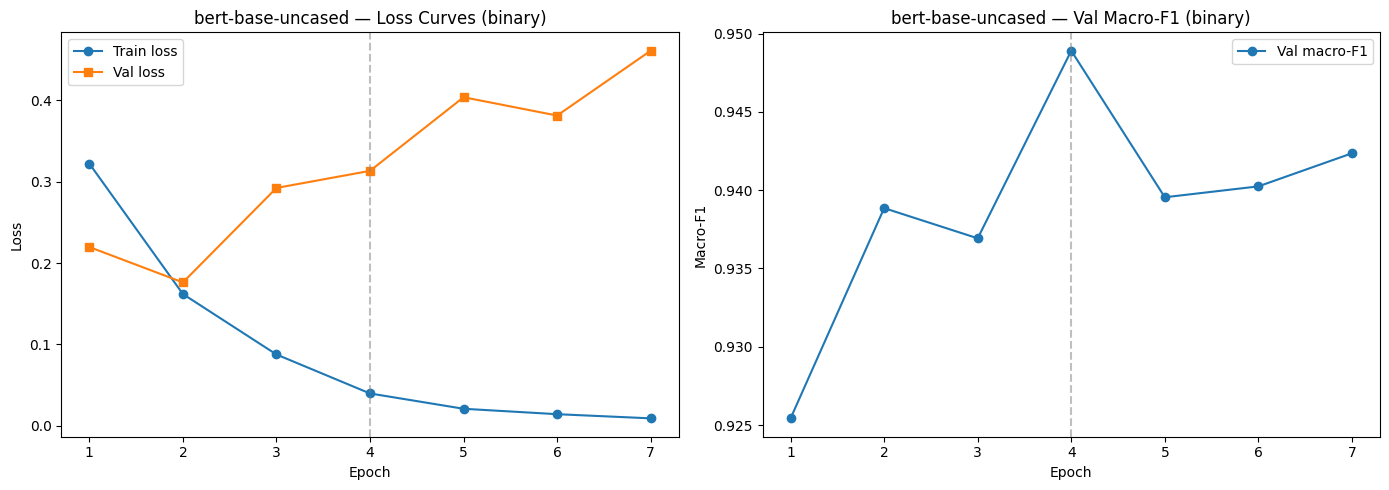


Loading best checkpoint (epoch 4, val macro-F1=0.9489)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

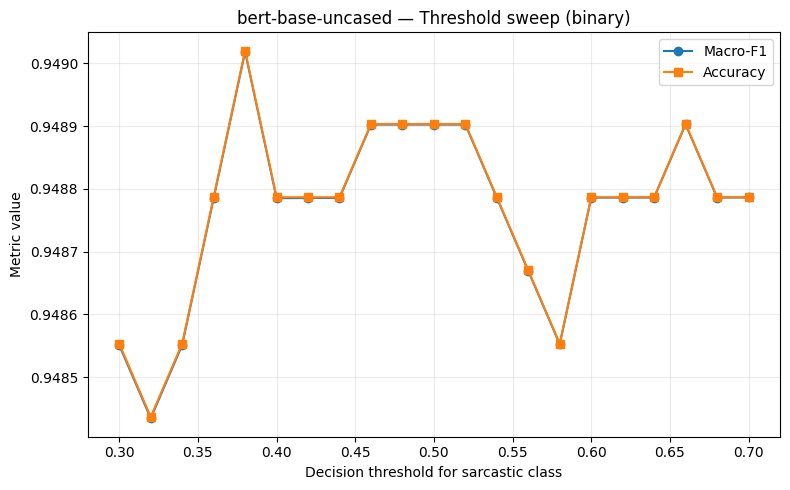

Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/threshold_sweep_val.png
Applied binary threshold tuning: threshold=0.38 (selected on validation macro-F1)

=== Val (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.95      0.94      0.95      4286
    sarcastic       0.94      0.95      0.95      4286

     accuracy                           0.95      8572
    macro avg       0.95      0.95      0.95      8572
 weighted avg       0.95      0.95      0.95      8572


=== Test (best checkpoint) ===
               precision    recall  f1-score   support

non-sarcastic       0.96      0.94      0.95      4286
    sarcastic       0.94      0.96      0.95      4286

     accuracy                           0.95      8572
    macro avg       0.95      0.95      0.95      8572
 weighted avg       0.95      0.95      0.95      8572



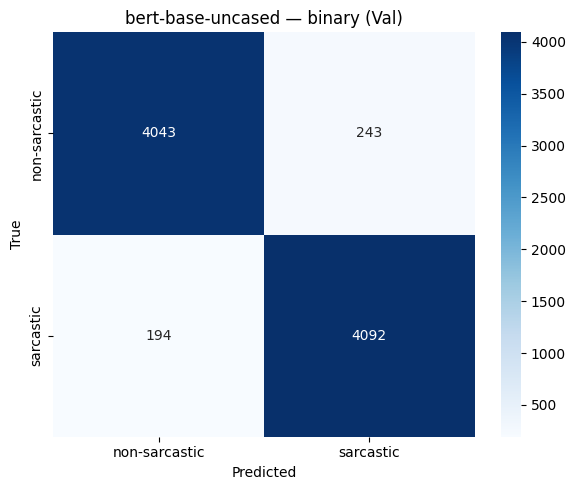

Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/confusion_matrix_val.png


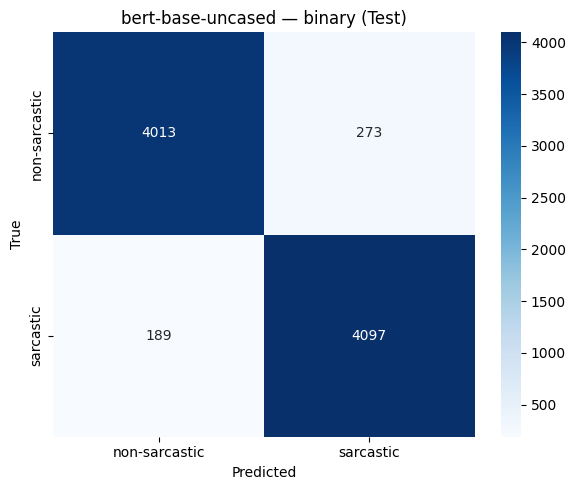

Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: bert-base-uncased / binary ===
  Test Accuracy   : 0.9461
  Test Macro-F1   : 0.9461
  Test Weighted-F1: 0.9461
  Threshold       : 0.38
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/final_model.pth


In [ ]:
# Uncomment to run BERT-base (requires more GPU memory and time)

CFG_BERT_BINARY = TrainConfig(
    model_name="bert-base-uncased",
    task="binary",
    batch_size=16,  # smaller batch for bert-base
    lr=2e-5,
)

results_bert_binary = train_bert(
    cfg         = CFG_BERT_BINARY,
    X_train     = X_train_bin, y_train = y_train_bin,
    X_val       = X_val_bin,   y_val   = y_val_bin,
    X_test      = X_test_bin,  y_test  = y_test_bin,
    label_names = label_names_bin,
    out_dir     = BERT_OUT / "bert_base_binary",
    val_df      = val_bin,
    test_df     = test_bin,
)

# print("BERT-base is commented out. Uncomment cells above to run.")

## (Optional) BERT-base — Type Task

Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/config.json
Loading tokenizer: bert-base-uncased
Loading model: bert-base-uncased (6 labels)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Class weight mode: inverse
Class weights: [0.774 1.187 4.701 0.54  0.907 1.429]
Epoch  1/10 | train_loss=1.5170 | val_loss=1.2682 | val_acc=0.4050 | val_macro_f1=0.4212


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best_model.pth
  ★ New best val macro-F1=0.4705 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/checkpoints/checkpoint_epoch_002.pt
Epoch  3/10 | train_loss=0.8595 | val_loss=1.3210 | val_acc=0.4743 | val_macro_f1=0.5066


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best_model.pth
  ★ New best val macro-F1=0.5066 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/checkpoints/checkpoint_epoch_003.pt
Epoch  4/10 | train_loss=0.5573 | val_loss=1.5921 | val_acc=0.4769 | val_macro_f1=0.5125


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best_model.pth
  ★ New best val macro-F1=0.5125 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/checkpoints/checkpoint_epoch_004.pt
Epoch  5/10 | train_loss=0.3542 | val_loss=1.9810 | val_acc=0.4692 | val_macro_f1=0.5013
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/checkpoints/checkpoint_epoch_005.pt
Epoch  6/10 | train_loss=0.2156 | val_loss=2.3848 | val_acc=0.4538 | val_macro_f1=0.4919
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/checkpoints/checkpoint_epoch_

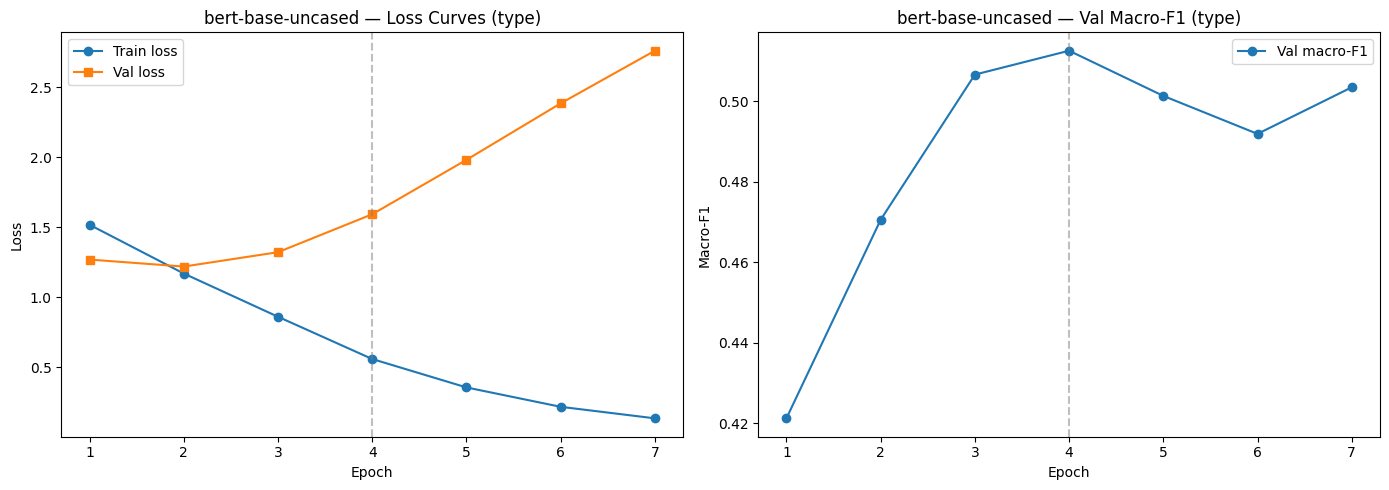


Loading best checkpoint (epoch 4, val macro-F1=0.5125)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.36      0.48      0.41       917
      overstatement       0.55      0.50      0.53       597
rhetorical_question       0.65      0.85      0.74       163
            sarcasm       0.54      0.48      0.51      1353
             satire       0.43      0.38      0.40       746
     understatement       0.52      0.46      0.49       510

           accuracy                           0.48      4286
          macro avg       0.51      0.52      0.51      4286
       weighted avg       0.49      0.48      0.48      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.36      0.48      0.41       915
      overstatement       0.51      0.47      0.49       606
rhetorical_question       0.64      0.70      0.67       169
            sarcasm       0.51      0.47      0.49      1310
             satir

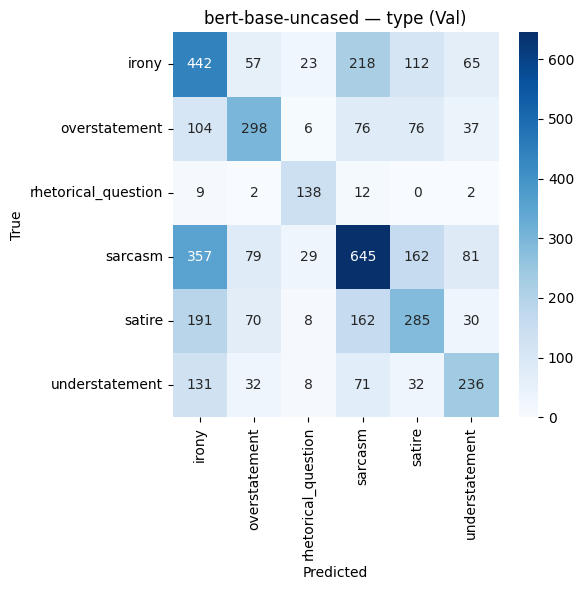

Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/confusion_matrix_val.png


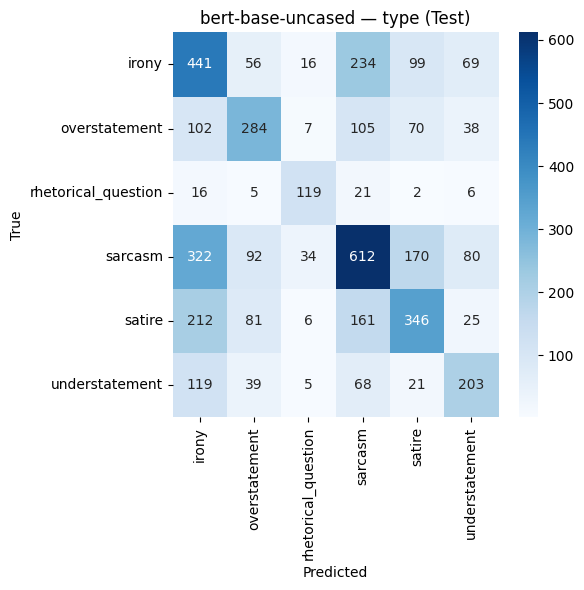

Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: bert-base-uncased / type ===
  Test Accuracy   : 0.4678
  Test Macro-F1   : 0.4954
  Test Weighted-F1: 0.4693
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/bert_base_type/final_model.pth


In [ ]:
CFG_BERT_TYPE = TrainConfig(
    model_name="bert-base-uncased",
    task="type",
    batch_size=16,
    lr=2e-5,
    class_weight_mode="inverse",
)

results_bert_type = train_bert(
    cfg         = CFG_BERT_TYPE,
    X_train     = X_train_type, y_train = y_train_type,
    X_val       = X_val_type,   y_val   = y_val_type,
    X_test      = X_test_type,  y_test  = y_test_type,
    label_names = STRATEGY_LABELS,
    out_dir     = BERT_OUT / "bert_base_type",
    val_df      = val_type,
    test_df     = test_type,
)

# print("BERT-base type task is commented out. Uncomment to run.")



## Summary

In [ ]:
print("====== BERT RESULTS SUMMARY ======")
print()
print("DistilBERT — Binary (Test):")
print(f"  Accuracy   : {results_distilbert_binary['test']['accuracy']:.4f}")
print(f"  Macro-F1   : {results_distilbert_binary['test']['f1_macro']:.4f}")
print(f"  Weighted-F1: {results_distilbert_binary['test']['f1_weighted']:.4f}")
print()
print("DistilBERT — Type (Test):")
print(f"  Accuracy   : {results_distilbert_type['test']['accuracy']:.4f}")
print(f"  Macro-F1   : {results_distilbert_type['test']['f1_macro']:.4f}")
print(f"  Weighted-F1: {results_distilbert_type['test']['f1_weighted']:.4f}")
print()
print("Artifacts saved in outputs/bert/distilbert_binary/ and outputs/bert/distilbert_type/")

====== BERT RESULTS SUMMARY ======

DistilBERT — Binary (Test):
  Accuracy   : 0.9399
  Macro-F1   : 0.9399
  Weighted-F1: 0.9399

DistilBERT — Type (Test):
  Accuracy   : 0.4613
  Macro-F1   : 0.4887
  Weighted-F1: 0.4617

Artifacts saved in outputs/bert/distilbert_binary/ and outputs/bert/distilbert_type/


In [ ]:
def evaluate_predictions_by_source(
    pred_csv: str | Path,
    *,
    true_col: str,
    pred_col: str,
    source_col: str = "is_generated",
) -> pd.DataFrame:
    df = pd.read_csv(pred_csv)

    slices = {
        "overall": df,
        "original_only": df[df[source_col] == 0].copy(),
        "generated_only": df[df[source_col] == 1].copy(),
    }

    rows = []
    for slice_name, sub in slices.items():
        y_true = sub[true_col].tolist()
        y_pred = sub[pred_col].tolist()

        rows.append({
            "slice": slice_name,
            "n": len(sub),
            "accuracy": accuracy_score(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
            "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        })

    return pd.DataFrame(rows)

# Check overfitting/underfitting

In [ ]:
# ============================================================
# Parameter count + data-size comparison
# ============================================================

import gc
import pandas as pd
from transformers import AutoConfig, AutoModelForSequenceClassification

EXPERIMENTS = [
    {
        "run_name": "distilbert_binary",
        "model_name": "distilbert-base-uncased",
        "num_labels": 2,
        "task": "binary",
        "train_n": len(X_train_bin),
        "val_n": len(X_val_bin),
        "test_n": len(X_test_bin),
    },
    {
        "run_name": "distilbert_type",
        "model_name": "distilbert-base-uncased",
        "num_labels": 6,
        "task": "type",
        "train_n": len(X_train_type),
        "val_n": len(X_val_type),
        "test_n": len(X_test_type),
    },
    {
        "run_name": "bert_base_binary",
        "model_name": "bert-base-uncased",
        "num_labels": 2,
        "task": "binary",
        "train_n": len(X_train_bin),
        "val_n": len(X_val_bin),
        "test_n": len(X_test_bin),
    },
    {
        "run_name": "bert_base_type",
        "model_name": "bert-base-uncased",
        "num_labels": 6,
        "task": "type",
        "train_n": len(X_train_type),
        "val_n": len(X_val_type),
        "test_n": len(X_test_type),
    },
]

def count_params_for_model(model_name: str, num_labels: int):
    # Build from config only. No pretrained weights download needed just to count params.
    cfg = AutoConfig.from_pretrained(model_name, num_labels=num_labels)
    model = AutoModelForSequenceClassification.from_config(cfg)

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # crude memory estimate for fp32 params only
    param_mem_mb = total_params * 4 / (1024 ** 2)

    del model
    gc.collect()

    return total_params, trainable_params, param_mem_mb


rows = []
for exp in EXPERIMENTS:
    total_params, trainable_params, param_mem_mb = count_params_for_model(
        exp["model_name"],
        exp["num_labels"],
    )

    rows.append({
        "run_name": exp["run_name"],
        "model_name": exp["model_name"],
        "task": exp["task"],
        "num_labels": exp["num_labels"],
        "train_n": exp["train_n"],
        "val_n": exp["val_n"],
        "test_n": exp["test_n"],
        "total_params": total_params,
        "trainable_params": trainable_params,
        "params_millions": total_params / 1e6,
        "fp32_param_mem_mb": param_mem_mb,
        "params_per_train_example": total_params / exp["train_n"],
        "train_examples_per_million_params": exp["train_n"] / (total_params / 1e6),
    })

param_df = pd.DataFrame(rows).sort_values(["task", "params_millions"])
display(param_df)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

,run_name,model_name,task,num_labels,train_n,val_n,test_n,total_params,trainable_params,params_millions,fp32_param_mem_mb,params_per_train_example,train_examples_per_million_params
0,distilbert_binary,distilbert-base-uncased,binary,2,39996,8572,8572,66955010,66955010,66.955010,255.413094,1674.042654,597.356344
2,bert_base_binary,bert-base-uncased,binary,2,39996,8572,8572,109483778,109483778,109.483778,417.647469,2737.368187,365.314394
1,distilbert_type,distilbert-base-uncased,type,6,19998,4286,4286,66958086,66958086,66.958086,255.424828,3348.239124,298.664451
3,bert_base_type,bert-base-uncased,type,6,19998,4286,4286,109486854,109486854,109.486854,417.659203,5474.890189,182.652065


---
# Part 5 — Error Analysis & Model Comparison

# Notebook 05 — Error Analysis & Model Comparison

**Purpose**:
1. Compare all models on both tasks
2. Analyze errors (binary + type)
3. Generate final comparison report

**Prerequisite**: Run notebooks 01–04 first.

**Outputs**:
- `outputs/reports/model_comparison.md`
- `outputs/reports/error_analysis.md`
- `outputs/reports/error_examples_binary.csv`
- `outputs/reports/error_examples_type.csv`

## 1. Load All Metrics

In [ ]:
from pathlib import Path
import json

# Reuse the artifact root defined earlier in the notebook.
ROOT = Path(globals().get("ROOT", Path.cwd()))
OUTPUTS = ROOT / "outputs"
CLASSICAL = OUTPUTS / "classical"
BERT_OUT = OUTPUTS / "bert"

print("ROOT (artifacts):", ROOT)
if "LOCAL_ROOT" in globals():
    print("LOCAL_ROOT (data):", LOCAL_ROOT)
print("OUTPUTS exists:", OUTPUTS.exists())
print("CLASSICAL exists:", CLASSICAL.exists())
print("BERT_OUT exists:", BERT_OUT.exists())

def load_metrics(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    try:
        rel = path.relative_to(ROOT)
    except Exception:
        rel = path
    print(f"  [WARNING] Not found: {rel}")
    return None

# --- All metrics ---
tfidf_lr_binary = load_metrics(CLASSICAL / "tfidf_lr" / "metrics_binary.json")
tfidf_lr_type   = load_metrics(CLASSICAL / "tfidf_lr" / "metrics_type.json")
nb_binary       = load_metrics(CLASSICAL / "naive_bayes" / "metrics_binary.json")
nb_type         = load_metrics(CLASSICAL / "naive_bayes" / "metrics_type.json")
distilbert_bin  = load_metrics(BERT_OUT / "distilbert_binary" / "metrics.json")
distilbert_type = load_metrics(BERT_OUT / "distilbert_type"   / "metrics.json")
bert_base_bin   = load_metrics(BERT_OUT / "bert_base_binary"  / "metrics.json")  # optional
bert_base_type  = load_metrics(BERT_OUT / "bert_base_type"    / "metrics.json")  # optional

print("\nMetrics loaded (None = not yet run):")
for name, m in [
    ("TF-IDF+LR binary", tfidf_lr_binary),
    ("TF-IDF+LR type", tfidf_lr_type),
    ("NB binary", nb_binary),
    ("NB type", nb_type),
    ("DistilBERT binary", distilbert_bin),
    ("DistilBERT type", distilbert_type),
    ("BERT-base binary", bert_base_bin),
    ("BERT-base type", bert_base_type),
]:
    print(f"  {name}: {'✓' if m else '✗'}")


ROOT (artifacts): /content/drive/MyDrive/cs4248
LOCAL_ROOT (data): /content
OUTPUTS exists: True
CLASSICAL exists: True
BERT_OUT exists: True

Metrics loaded (None = not yet run):
  TF-IDF+LR binary: ✓
  TF-IDF+LR type: ✓
  NB binary: ✓
  NB type: ✓
  DistilBERT binary: ✓
  DistilBERT type: ✓
  BERT-base binary: ✓
  BERT-base type: ✓


## 2. Model Comparison Tables

In [ ]:
def extract_test_metrics(metrics_dict: dict | None, split: str = "test") -> dict:
    """Extract test-split metrics from a metrics dict, handling different formats."""
    if metrics_dict is None:
        return {"accuracy": None, "f1_macro": None, "f1_weighted": None,
                "precision_macro": None, "recall_macro": None}
    test_m = metrics_dict.get(split, metrics_dict)  # BERT format uses 'test' key directly
    return {
        "accuracy"        : test_m.get("accuracy"),
        "f1_macro"        : test_m.get("f1_macro"),
        "f1_weighted"     : test_m.get("f1_weighted"),
        "precision_macro" : test_m.get("precision_macro"),
        "recall_macro"    : test_m.get("recall_macro"),
    }


binary_rows = []
type_rows   = []

model_map_bin = [
    ("TF-IDF + LR",   tfidf_lr_binary),
    ("Naive Bayes",   nb_binary),
    ("DistilBERT",    distilbert_bin),
    ("BERT-base",     bert_base_bin),
]

model_map_type = [
    ("TF-IDF + LR",   tfidf_lr_type),
    ("Naive Bayes",   nb_type),
    ("DistilBERT",    distilbert_type),
    ("BERT-base",     bert_base_type),
]

for name, m in model_map_bin:
    row = {"Model": name}
    row.update(extract_test_metrics(m))
    binary_rows.append(row)

for name, m in model_map_type:
    row = {"Model": name}
    row.update(extract_test_metrics(m))
    type_rows.append(row)

binary_comp = pd.DataFrame(binary_rows).set_index("Model")
type_comp   = pd.DataFrame(type_rows).set_index("Model")

print("=== BINARY TASK — Test Metrics ===")
print(binary_comp.to_string(float_format=lambda x: f"{x:.4f}" if x is not None else "N/A"))
print()
print("=== TYPE TASK — Test Metrics ===")
print(type_comp.to_string(float_format=lambda x: f"{x:.4f}" if x is not None else "N/A"))

=== BINARY TASK — Test Metrics ===
             accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
Model                                                                      
TF-IDF + LR    0.8187    0.8187       0.8187           0.8187        0.8187
Naive Bayes    0.7920    0.7918       0.7918           0.7932        0.7920
DistilBERT     0.9399    0.9399       0.9399           0.9399        0.9399
BERT-base      0.9461    0.9461       0.9461           0.9463        0.9461

=== TYPE TASK — Test Metrics ===
             accuracy  f1_macro  f1_weighted  precision_macro  recall_macro
Model                                                                      
TF-IDF + LR    0.3920    0.3986       0.3915           0.3851        0.4206
Naive Bayes    0.3945    0.3898       0.3916           0.3997        0.3827
DistilBERT     0.4613    0.4887       0.4617           0.4834        0.4958
BERT-base      0.4678    0.4954       0.4693           0.4984        0.4974


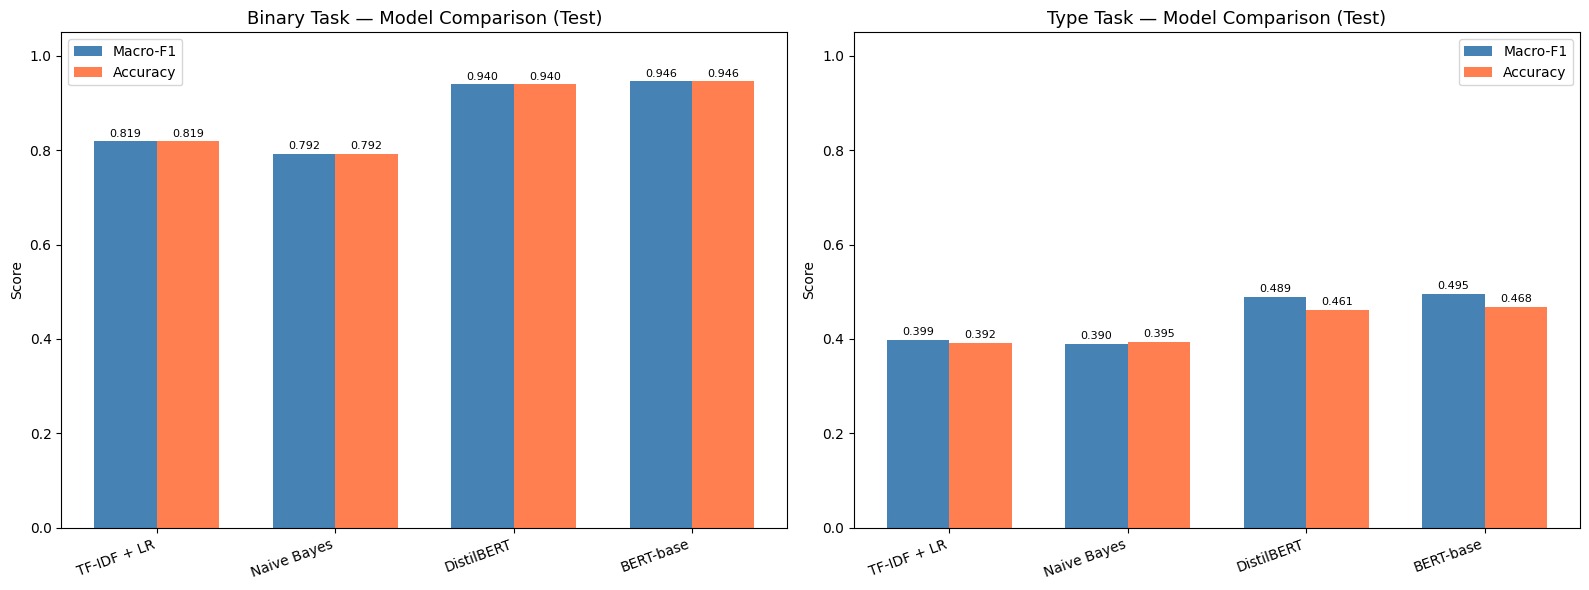

Saved: outputs/reports/model_comparison_chart.png


In [ ]:
# ── Comparison bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, comp, title in [
    (axes[0], binary_comp, "Binary Task"),
    (axes[1], type_comp,   "Type Task"),
]:
    valid = comp.dropna(subset=["f1_macro"])
    if len(valid) == 0:
        ax.set_title(f"{title} — No data")
        continue
    models  = valid.index.tolist()
    f1_vals = valid["f1_macro"].tolist()
    acc_vals = valid["accuracy"].tolist()
    x = range(len(models))
    w = 0.35
    bars1 = ax.bar([i - w/2 for i in x], f1_vals,  w, label="Macro-F1",  color="steelblue")
    bars2 = ax.bar([i + w/2 for i in x], acc_vals, w, label="Accuracy",  color="coral")
    ax.set_xticks(list(x)); ax.set_xticklabels(models, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(f"{title} — Model Comparison (Test)", fontsize=13)
    ax.legend()
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.3f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/reports/model_comparison_chart.png")

## 3. Error Analysis — Binary Task

In [ ]:
def load_predictions(path: Path) -> pd.DataFrame | None:
    if path.exists():
        return pd.read_csv(path)
    print(f"  [WARNING] Not found: {path}")
    return None


# Use best available binary model predictions for error analysis
# Priority: BERT > TF-IDF+LR > NB
pred_paths_bin = [
    ("DistilBERT",  BERT_OUT / "distilbert_binary" / "predictions_test.csv"),
    ("TF-IDF + LR", CLASSICAL / "tfidf_lr" / "predictions_test_binary.csv"),
    ("Naive Bayes", CLASSICAL / "naive_bayes" / "predictions_test_binary.csv"),
]

error_source_bin = None
error_model_bin  = None
for model_name, path in pred_paths_bin:
    df = load_predictions(path)
    if df is not None:
        error_source_bin = df
        error_model_bin  = model_name
        print(f"Using {model_name} predictions for binary error analysis")
        break

if error_source_bin is None:
    print("No binary predictions found. Run at least one model first.")

Using DistilBERT predictions for binary error analysis


In [ ]:
if error_source_bin is not None:
    pred_col = "predicted" if "predicted" in error_source_bin.columns else "predicted_id"
    true_col = "binary_label"
    err_bin  = error_source_bin[error_source_bin["correct"] == 0].copy()

    # Categorize
    fp_bin = err_bin[err_bin[true_col] == 0].copy()  # False Positives (predicted sarcastic)
    fn_bin = err_bin[err_bin[true_col] == 1].copy()  # False Negatives (predicted not-sarcastic)

    print(f"Total binary test errors: {len(err_bin)}")
    print(f"  False Positives (non-sarcastic predicted as sarcastic) : {len(fp_bin)}")
    print(f"  False Negatives (sarcastic predicted as non-sarcastic)  : {len(fn_bin)}")

    # Select 20+ errors: mix of FP and FN
    n_each = 12
    sample_fp = fp_bin.head(n_each)
    sample_fn = fn_bin.head(n_each)
    error_sample_bin = pd.concat([sample_fp, sample_fn], ignore_index=True)
    error_sample_bin["error_type"] = ["FP"] * len(sample_fp) + ["FN"] * len(sample_fn)

    print(f"\nError sample size: {len(error_sample_bin)} examples")
    print("\n--- False Positives (non-sarcastic → predicted sarcastic) ---")
    for _, row in sample_fp.iterrows():
        print(f"  {row['text']}")

    print("\n--- False Negatives (sarcastic → predicted non-sarcastic) ---")
    for _, row in sample_fn.iterrows():
        print(f"  {row['text']}")

Total binary test errors: 515
  False Positives (non-sarcastic predicted as sarcastic) : 259
  False Negatives (sarcastic predicted as non-sarcastic)  : 256

Error sample size: 24 examples

--- False Positives (non-sarcastic → predicted sarcastic) ---
  The global-warming crisis contributed to a delightful mid-February afternoon.
  Slovenian eighth-graders outperform U.S. students in science, surprising themselves.
  Denny's launches omelet with 3,000 spider eggs
  Study shows 83% of web content is unsuitable for humans
  Aphasia study discovers that empty fullness is facilitated by happy yellow ideas
  Cindy Crawford will have pure silk flowing from her backside.
  Kerry's face shows joy over the latest polls.
  New roommate excited to bring extensive household maintenance experience to apartment.
  Only you have been invited to Dave's debate party, which is considered creepy.
  Ophthalmologist recommends eye rest before surgery
  Cat experiences minor choking incident
  The ruthless 

In [ ]:
if error_source_bin is not None:
    # Failure mode categorization (heuristic rules)
    def categorize_binary_error(text: str, error_type: str) -> str:
        text_lower = text.lower()
        if "?" in text and error_type == "FP":
            return "rhetorical_phrasing"
        if any(w in text_lower for w in ["report", "study", "survey", "finds", "shows"]):
            return "neutral_reporting_style_confused"
        if any(w in text_lower for w in ["best", "great", "amazing", "wonderful", "perfect"]):
            return "positive_framing_confused"
        if "onion" in text_lower:
            return "domain_leak"
        if len(text.split()) <= 5:
            return "very_short_text"
        return "lexical_ambiguity"

    error_sample_bin["failure_mode"] = error_sample_bin.apply(
        lambda r: categorize_binary_error(r["text"], r["error_type"]), axis=1
    )

    print("Failure mode distribution:")
    print(error_sample_bin["failure_mode"].value_counts())

    # Save
    error_sample_bin.to_csv(REPORTS_DIR / "error_examples_binary.csv", index=False)
    print("\nSaved: outputs/reports/error_examples_binary.csv")

Failure mode distribution:
failure_mode
lexical_ambiguity                   16
neutral_reporting_style_confused     6
very_short_text                      2
Name: count, dtype: int64

Saved: outputs/reports/error_examples_binary.csv


In [ ]:
binary_source_report = evaluate_predictions_by_source(
    BERT_OUT / "bert_base_binary" / "predictions_test.csv",
    true_col="binary_label",
    pred_col="predicted",
)

display(binary_source_report)
binary_source_report.to_csv(BERT_OUT / "bert_base_binary_source_report.csv", index=False)
print("Saved:", BERT_OUT / "bert_base_binary_source_report.csv")

,slice,n,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,overall,8572,0.946104,0.946098,0.946098,0.946275,0.946104
1,original_only,4286,0.915072,0.914999,0.915148,0.915101,0.916586
2,generated_only,4286,0.977135,0.977080,0.977147,0.976690,0.977696


Saved: /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary_source_report.csv


## 4. Error Analysis — Type Task

In [ ]:
pred_paths_type = [
    ("DistilBERT",  BERT_OUT / "distilbert_type" / "predictions_test.csv"),
    ("TF-IDF + LR", CLASSICAL / "tfidf_lr" / "predictions_test_type.csv"),
    ("Naive Bayes", CLASSICAL / "naive_bayes" / "predictions_test_type.csv"),
]

error_source_type = None
error_model_type  = None
for model_name, path in pred_paths_type:
    df = load_predictions(path)
    if df is not None:
        error_source_type = df
        error_model_type  = model_name
        print(f"Using {model_name} predictions for type error analysis")
        break

if error_source_type is None:
    print("No type predictions found.")

Using DistilBERT predictions for type error analysis


In [ ]:
if error_source_type is not None:
    err_type = error_source_type[error_source_type["correct"] == 0].copy()

    # Identify label columns
    true_col_type = "type_label"
    pred_col_type = "predicted_label" if "predicted_label" in err_type.columns else "predicted"

    print(f"Total type errors: {len(err_type)}")
    print("\nTop confusion pairs (true → predicted):")
    if pred_col_type in err_type.columns:
        pairs = err_type.groupby([true_col_type, pred_col_type]).size().sort_values(ascending=False).head(15)
        print(pairs.to_string())

    # Sample 20+ errors
    error_sample_type = err_type.sample(min(25, len(err_type)), random_state=42)

    print(f"\nError sample size: {len(error_sample_type)} examples")
    print("\n--- Sample type misclassifications ---")
    display_cols = ["text", true_col_type]
    if pred_col_type in error_sample_type.columns:
        display_cols.append(pred_col_type)
    for _, row in error_sample_type.head(15).iterrows():
        true_l = row[true_col_type]
        pred_l = row.get(pred_col_type, "?")
        print(f"  [True={true_l:20s}  Pred={pred_l:20s}] {row['text'][:90]}")

Total type errors: 2309

Top confusion pairs (true → predicted):
type_label      predicted_label
sarcasm         irony              268
irony           sarcasm            254
sarcasm         satire             187
satire          sarcasm            177
                irony              164
understatement  irony              109
irony           satire             103
overstatement   sarcasm            101
sarcasm         overstatement      100
overstatement   irony               94
satire          overstatement       91
irony           overstatement       87
overstatement   satire              85
sarcasm         understatement      80
irony           understatement      79

Error sample size: 25 examples

--- Sample type misclassifications ---
  [True=satire                Pred=irony               ] Kim K shares baptism photos—because nothing says sacred like a social media post.
  [True=satire                Pred=irony               ] 'why can i never seem to say the right thing?' wee

In [ ]:
if error_source_type is not None:
    def categorize_type_error(text: str, true_label: str, pred_label: str) -> str:
        """Heuristic failure mode categorization for type task."""
        text_lower = text.lower()
        # Strategy overlap: sarcasm ↔ irony ↔ satire are frequently confused
        overlap_pairs = {
            frozenset({"sarcasm", "irony"}),
            frozenset({"sarcasm", "satire"}),
            frozenset({"irony", "satire"}),
        }
        if frozenset({true_label, pred_label}) in overlap_pairs:
            return "strategy_semantic_overlap"
        if "rhetorical_question" in [true_label, pred_label]:
            if "?" in text:
                return "rhetorical_vs_other_with_question"
            return "rhetorical_without_question_mark"
        if true_label in ["overstatement", "understatement"] and pred_label in ["sarcasm", "irony"]:
            return "scale_confusion_with_sarcasm"
        if "report" in text_lower or "according" in text_lower:
            return "generation_artifact_formal_phrasing"
        return "lexical_ambiguity"

    if pred_col_type in error_sample_type.columns:
        error_sample_type["failure_mode"] = error_sample_type.apply(
            lambda r: categorize_type_error(r["text"], r[true_col_type], r[pred_col_type]),
            axis=1
        )
        print("Failure mode distribution:")
        print(error_sample_type["failure_mode"].value_counts())

    error_sample_type.to_csv(REPORTS_DIR / "error_examples_type.csv", index=False)
    print("\nSaved: outputs/reports/error_examples_type.csv")

Failure mode distribution:
failure_mode
strategy_semantic_overlap            15
lexical_ambiguity                     6
scale_confusion_with_sarcasm          3
rhetorical_vs_other_with_question     1
Name: count, dtype: int64

Saved: outputs/reports/error_examples_type.csv


In [ ]:
BEST_TYPE_RUN_DIR = BERT_OUT / "distilbert_type_weight_none"  # update after winner is decided

type_source_report = evaluate_predictions_by_source(
    BEST_TYPE_RUN_DIR / "predictions_test.csv",
    true_col="type_label",
    pred_col="predicted_label",
)

display(type_source_report)
type_source_report.to_csv(BEST_TYPE_RUN_DIR / "source_report_test.csv", index=False)
print("Saved:", BEST_TYPE_RUN_DIR / "source_report_test.csv")

,slice,n,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro
0,overall,4286,0.473402,0.500050,0.473631,0.498942,0.503143
1,original_only,2015,0.451613,0.448902,0.450993,0.478861,0.428989
2,generated_only,2271,0.492734,0.510530,0.492021,0.506422,0.516928


Saved: /content/drive/MyDrive/cs4248/outputs/bert/distilbert_type_weight_none/source_report_test.csv


### Iteration 5 — Small recipe sweep for the best type setup

Run this only after the weighting decision is settled.
This sweep is intentionally small and changes only the training recipe.

In [ ]:
TYPE_RECIPE_VARIANTS = {
    "type_best_lr1e5_ep6_pat2": {
        "lr": 1e-5,
        "epochs": 6,
        "patience": 2,
    },
    "type_best_lr2e5_ep6_pat2": {
        "lr": 2e-5,
        "epochs": 6,
        "patience": 2,
    },
    "type_best_lr3e5_ep6_pat2": {
        "lr": 3e-5,
        "epochs": 6,
        "patience": 2,
    },
}

Running variant=type_best_lr1e5_ep6_pat2 | seed=42
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42
Config saved to /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/config.json
Loading tokenizer: distilbert-base-uncased
Loading model: distilbert-base-uncased (6 labels)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/6 | train_loss=1.5576 | val_loss=1.3510 | val_acc=0.4470 | val_macro_f1=0.4426


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best_model.pth
  ★ New best val macro-F1=0.4739 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/checkpoints/checkpoint_epoch_002.pt
Epoch  3/6 | train_loss=1.1895 | val_loss=1.2862 | val_acc=0.4769 | val_macro_f1=0.5074


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best_model.pth
  ★ New best val macro-F1=0.5074 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/checkpoints/checkpoint_epoch_003.pt
Epoch  4/6 | train_loss=1.0963 | val_loss=1.3005 | val_acc=0.4792 | val_macro_f1=0.5082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best_model.pth
  ★ New best val macro-F1=0.5082 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/checkpoints/checkpoint_epoch_004.pt
Epoch  5/6 | train_loss=1.0248 | val_loss=1.3286 | val_acc=0.4788 | val_macro_f1=0.5053
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/checkpoints/checkpoint_epoch_005.pt
Epoch  6/6 | train_loss=0.9794 | val_loss=1.3400 | val_acc=0.4760 | v

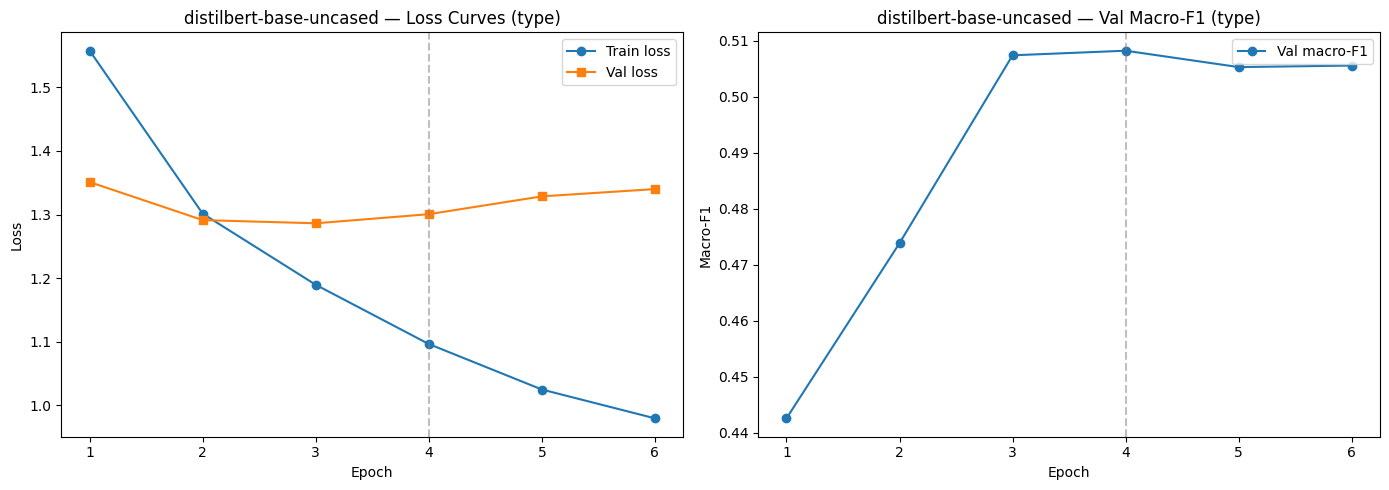


Loading best checkpoint (epoch 4, val macro-F1=0.5082)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


=== Val (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.36      0.34      0.35       917
      overstatement       0.52      0.45      0.48       597
rhetorical_question       0.72      0.83      0.77       163
            sarcasm       0.51      0.61      0.56      1353
             satire       0.43      0.38      0.41       746
     understatement       0.51      0.47      0.49       510

           accuracy                           0.48      4286
          macro avg       0.51      0.51      0.51      4286
       weighted avg       0.47      0.48      0.47      4286


=== Test (best checkpoint) ===
                     precision    recall  f1-score   support

              irony       0.38      0.35      0.36       915
      overstatement       0.50      0.44      0.47       606
rhetorical_question       0.71      0.70      0.71       169
            sarcasm       0.48      0.60      0.54      1310
             satir

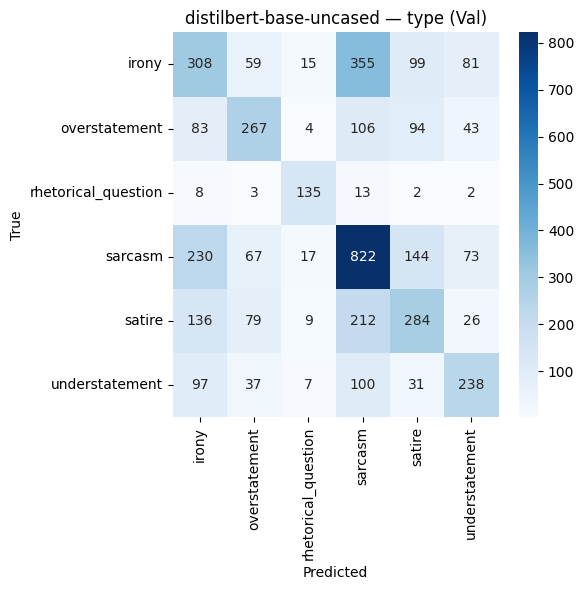

Saved: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/confusion_matrix_val.png


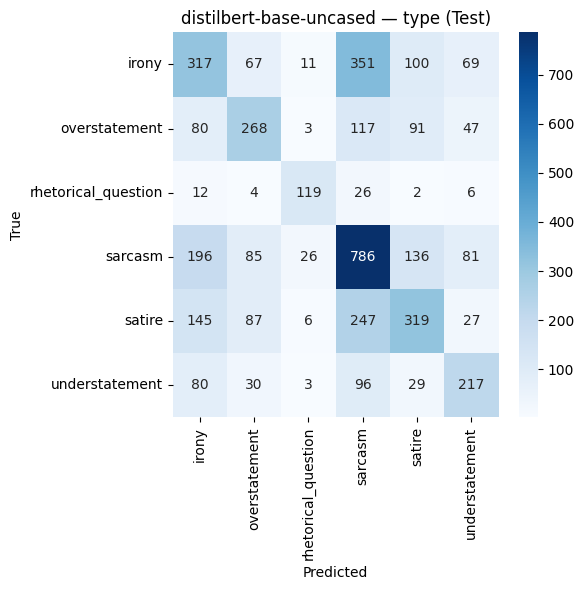

Saved: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/confusion_matrix_test.png
Saved predictions_val.csv
Saved predictions_test.csv

=== DONE: distilbert-base-uncased / type ===
  Test Accuracy   : 0.4727
  Test Macro-F1   : 0.4962
  Test Weighted-F1: 0.4684
  Best checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best.pt
  Last checkpoint : /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/last.pt
  Best weights    : /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/best_model.pth
  Final weights   : /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr1e5_ep6_pat2_seed42/final_model.pth
Running variant=type_best_lr2e5_ep6_pat2 | seed=42
Using device: cuda
Artifacts will be saved under: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr2e5_ep6_pat2_seed42
C

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch  1/6 | train_loss=1.5081 | val_loss=1.2973 | val_acc=0.4699 | val_macro_f1=0.4809


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr2e5_ep6_pat2_seed42/best.pt
Saved weights-only file: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr2e5_ep6_pat2_seed42/best_model.pth
  ★ New best val macro-F1=0.4809 — best checkpoint updated
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr2e5_ep6_pat2_seed42/last.pt
Saved checkpoint: /content/drive/MyDrive/cs4248/outputs/bert/type_recipe_sweep/type_best_lr2e5_ep6_pat2_seed42/checkpoints/checkpoint_epoch_001.pt
Epoch  2/6 | train_loss=1.2303 | val_loss=1.2919 | val_acc=0.4715 | val_macro_f1=0.4761


KeyboardInterrupt: 

In [ ]:
# Example usage after best type weighting is chosen:
BEST_TYPE_CFG = replace(CFG_TYPE, class_weight_mode="none")

type_recipe_runs = run_seed_ablation(
    base_cfg=BEST_TYPE_CFG,
    variant_overrides=TYPE_RECIPE_VARIANTS,
    seeds=[42],  # first-pass screening only
    X_train=X_train_type, y_train=y_train_type,
    X_val=X_val_type, y_val=y_val_type,
    X_test=X_test_type, y_test=y_test_type,
    label_names=STRATEGY_LABELS,
    out_root=BERT_OUT / "type_recipe_sweep",
    val_df=val_type,
    test_df=test_type,
)

display(type_recipe_runs)
summarize_ablation_runs(type_recipe_runs)

## 5. Generate Final Reports

In [ ]:
def fmt(v) -> str:
    """Format a metric value for markdown."""
    if v is None:
        return "N/A"
    return f"{v:.4f}"


def build_model_comparison_md() -> str:
    lines = []
    lines.append("# Model Comparison Report")
    lines.append("")
    lines.append("> Auto-generated from outputs of notebooks 02–04.")
    lines.append("")

    # Binary task table
    lines.append("## Task A — Binary Classification (Test Set)")
    lines.append("")
    lines.append("| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |")
    lines.append("|-------|----------|--------------|------------|------------|--------------|")
    for name, m in model_map_bin:
        r = extract_test_metrics(m)
        lines.append(
            f"| {name} | {fmt(r['accuracy'])} | {fmt(r['precision_macro'])} | "
            f"{fmt(r['recall_macro'])} | {fmt(r['f1_macro'])} | {fmt(r['f1_weighted'])} |"
        )
    lines.append("")
    lines.append("_Primary metric: Macro-F1. Best value bolded (manually after review)._")
    lines.append("")

    # Type task table
    lines.append("## Task B — Sarcasm Type Classification (Test Set)")
    lines.append("")
    lines.append("| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |")
    lines.append("|-------|----------|--------------|------------|------------|--------------|")
    for name, m in model_map_type:
        r = extract_test_metrics(m)
        lines.append(
            f"| {name} | {fmt(r['accuracy'])} | {fmt(r['precision_macro'])} | "
            f"{fmt(r['recall_macro'])} | {fmt(r['f1_macro'])} | {fmt(r['f1_weighted'])} |"
        )
    lines.append("")

    # Recommendation
    lines.append("## Recommendation")
    lines.append("")

    # Find best binary model
    best_bin_name, best_bin_f1 = "N/A", -1
    for name, m in model_map_bin:
        r = extract_test_metrics(m)
        if r["f1_macro"] is not None and r["f1_macro"] > best_bin_f1:
            best_bin_f1 = r["f1_macro"]
            best_bin_name = name

    best_type_name, best_type_f1 = "N/A", -1
    for name, m in model_map_type:
        r = extract_test_metrics(m)
        if r["f1_macro"] is not None and r["f1_macro"] > best_type_f1:
            best_type_f1 = r["f1_macro"]
            best_type_name = name

    lines.append(f"### Best model for Binary Task: **{best_bin_name}** (Macro-F1 = {fmt(best_bin_f1)})")
    lines.append("")
    lines.append(f"### Best model for Type Task: **{best_type_name}** (Macro-F1 = {fmt(best_type_f1)})")
    lines.append("")
    lines.append("### Trade-offs")
    lines.append("")
    lines.append("| Aspect | TF-IDF + LR | Naive Bayes | DistilBERT |")
    lines.append("|--------|------------|-------------|-----------|")
    lines.append("| Training speed | Fast (minutes) | Very fast (seconds) | Slow (hours) |")
    lines.append("| Inference speed | Very fast | Very fast | Moderate |")
    lines.append("| Interpretability | High (feature weights) | High (log-probs) | Low (black-box) |")
    lines.append("| Handles context | No | No | Yes (self-attention) |")
    lines.append("| Handles rare words | Via TF-IDF | Via smoothing | Via sub-word tokenization |")
    lines.append("| GPU required | No | No | Recommended |")
    lines.append("")
    lines.append("**Deployment recommendation**: Use TF-IDF+LR if real-time speed and interpretability are priorities.")
    lines.append("Use DistilBERT for maximum accuracy when GPU inference is available.")

    return "\n".join(lines)


comparison_md = build_model_comparison_md()
with open(REPORTS_DIR / "model_comparison.md", "w", encoding="utf-8") as f:
    f.write(comparison_md)

print("Saved: outputs/reports/model_comparison.md")
print("\nPreview:")
print(comparison_md[:2000])

Saved: outputs/reports/model_comparison.md

Preview:
# Model Comparison Report

> Auto-generated from outputs of notebooks 02–04.

## Task A — Binary Classification (Test Set)

| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |
|-------|----------|--------------|------------|------------|--------------|
| TF-IDF + LR | 0.8187 | 0.8187 | 0.8187 | 0.8187 | 0.8187 |
| Naive Bayes | 0.7920 | 0.7932 | 0.7920 | 0.7918 | 0.7918 |
| DistilBERT | 0.9399 | 0.9399 | 0.9399 | 0.9399 | 0.9399 |
| BERT-base | 0.9461 | 0.9463 | 0.9461 | 0.9461 | 0.9461 |

_Primary metric: Macro-F1. Best value bolded (manually after review)._

## Task B — Sarcasm Type Classification (Test Set)

| Model | Accuracy | Precision (M) | Recall (M) | F1 (Macro) | F1 (Weighted) |
|-------|----------|--------------|------------|------------|--------------|
| TF-IDF + LR | 0.3920 | 0.3851 | 0.4206 | 0.3986 | 0.3915 |
| Naive Bayes | 0.3945 | 0.3997 | 0.3827 | 0.3898 | 0.3916 |
| DistilBERT | 0.4613 |

In [ ]:
def build_error_analysis_md() -> str:
    lines = []
    lines.append("# Error Analysis Report")
    lines.append("")
    lines.append("> Auto-generated from model predictions. Examples drawn from test set.")
    lines.append("")

    # ── Binary ────────────────────────────────────────────────────────────────
    lines.append("## Task A — Binary Classification Errors")
    lines.append("")

    if error_source_bin is not None:
        err_df = error_source_bin[error_source_bin["correct"] == 0]
        n_fp = len(err_df[err_df["binary_label"] == 0])
        n_fn = len(err_df[err_df["binary_label"] == 1])
        lines.append(f"**Model**: {error_model_bin}  |  **Total errors**: {len(err_df):,}  |  FP: {n_fp:,}  |  FN: {n_fn:,}")
        lines.append("")
        lines.append("### Failure Mode Summary")
        lines.append("")
        lines.append("| Failure Mode | Description |")
        lines.append("|-------------|-------------|")
        lines.append("| Lexical ambiguity | Sarcasm/irony requires pragmatic context beyond lexical cues |")
        lines.append("| Neutral reporting style confused | Formal generated text mimics neutral news, but still classified as sarcastic |")
        lines.append("| Positive framing confused | Genuine positive news shares superlative vocabulary with ironic praise |")
        lines.append("| Rhetorical phrasing | Questions that look rhetorical but are literal |")
        lines.append("| Very short text | Too little context for confident classification |")
        lines.append("")
        lines.append("### False Positive Examples (Non-sarcastic predicted as sarcastic)")
        lines.append("")
        fp_examples = error_source_bin[
            (error_source_bin["correct"] == 0) & (error_source_bin["binary_label"] == 0)
        ].head(10)
        for _, row in fp_examples.iterrows():
            lines.append(f"- `{row['text']}`")
        lines.append("")
        lines.append("### False Negative Examples (Sarcastic predicted as non-sarcastic)")
        lines.append("")
        fn_examples = error_source_bin[
            (error_source_bin["correct"] == 0) & (error_source_bin["binary_label"] == 1)
        ].head(10)
        for _, row in fn_examples.iterrows():
            lines.append(f"- `{row['text']}`")
    else:
        lines.append("_Binary predictions not available. Run at least one model._")

    lines.append("")

    # ── Type ──────────────────────────────────────────────────────────────────
    lines.append("## Task B — Sarcasm Type Classification Errors")
    lines.append("")

    if error_source_type is not None:
        err_df_t = error_source_type[error_source_type["correct"] == 0]
        lines.append(f"**Model**: {error_model_type}  |  **Total errors**: {len(err_df_t):,}")
        lines.append("")
        lines.append("### Failure Mode Summary")
        lines.append("")
        lines.append("| Failure Mode | Description |")
        lines.append("|-------------|-------------|")
        lines.append("| Strategy semantic overlap | sarcasm/irony/satire share similar surface forms; labels conflated |")
        lines.append("| Scale confusion | overstatement/understatement confused with sarcasm due to exaggeration cues |")
        lines.append("| Rhetorical vs. other | rhetorical_question confused with irony/sarcasm when ? is absent |")
        lines.append("| Generation artifact | formal paraphrase style shifts text away from original strategy markers |")
        lines.append("| Lexical ambiguity | strategy relies on world knowledge rather than surface vocabulary |")
        lines.append("")
        lines.append("### Key Insight")
        lines.append("")
        lines.append("The primary failure mode is **strategy semantic overlap**: sarcasm, irony, and satire")
        lines.append("are conceptually related and frequently share similar linguistic surface patterns.")
        lines.append("The label `sarcasm` as a strategy within a sarcasm dataset introduces circularity.")
        lines.append("The `rhetorical_question` class is syntactically distinctive (ends with ?) and should")
        lines.append("be easier to classify; errors in this class suggest the classifier may ignore punctuation.")
        lines.append("")
        lines.append("### Sample Misclassifications")
        lines.append("")
        sample_t = error_source_type[error_source_type["correct"] == 0].head(20)
        true_c = "type_label"
        pred_c = "predicted_label" if "predicted_label" in sample_t.columns else "predicted"
        for _, row in sample_t.iterrows():
            true_l = row[true_c]
            pred_l = row.get(pred_c, "?")
            lines.append(f"- **True**: {true_l} | **Pred**: {pred_l} | `{row['text'][:100]}`")
    else:
        lines.append("_Type predictions not available. Run at least one model._")

    lines.append("")
    lines.append("## Summary of Observations")
    lines.append("")
    lines.append("1. **Binary task** is relatively tractable — TheOnion writing style has strong lexical signatures")
    lines.append("2. **Generated headlines** (is_generated=1) may fool classifiers trained mainly on original text")
    lines.append("3. **Type task** is fundamentally harder because strategies are not mutually exclusive")
    lines.append("4. **Class imbalance** (rhetorical_question = 3.7%) is a significant challenge")
    lines.append("5. **BERT** should better capture contextual incongruence; classical models rely on surface vocabulary")

    return "\n".join(lines)


error_md = build_error_analysis_md()
with open(REPORTS_DIR / "error_analysis.md", "w", encoding="utf-8") as f:
    f.write(error_md)

print("Saved: outputs/reports/error_analysis.md")

Saved: outputs/reports/error_analysis.md


In [ ]:
print("====== ERROR ANALYSIS COMPLETE ======")
print()
print("Saved artifacts:")
for p in sorted(REPORTS_DIR.iterdir()):
    print(f"  {p.relative_to(ROOT)}")
print()
print("Pipeline complete. See outputs/reports/model_comparison.md for final results.")

====== ERROR ANALYSIS COMPLETE ======

Saved artifacts:
  outputs/reports/error_analysis.md
  outputs/reports/error_examples_binary.csv
  outputs/reports/error_examples_type.csv
  outputs/reports/model_comparison.md
  outputs/reports/model_comparison_chart.png

Pipeline complete. See outputs/reports/model_comparison.md for final results.


In [ ]:
# Optional sync cell:
# - If outputs are already being written directly into Google Drive, this cell
#   just reports the location and does nothing.
# - If outputs are local, it copies them into /content/drive/MyDrive/cs4248/outputs.

from pathlib import Path
import os
import shutil

outputs_dir = Path(globals().get("ROOT", Path.cwd())) / "outputs"

if str(outputs_dir).startswith("/content/drive/"):
    print(f"Outputs are already stored in Google Drive: {outputs_dir}")
else:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

    target_root = Path("/content/drive/MyDrive") / globals().get("GOOGLE_DRIVE_PROJECT_DIR", "cs4248")
    target_root.mkdir(parents=True, exist_ok=True)
    dst = target_root / "outputs"

    if not outputs_dir.exists():
        raise FileNotFoundError(f"Missing source folder: {outputs_dir}")

    shutil.copytree(outputs_dir, dst, dirs_exist_ok=True)
    print(f"Copied '{outputs_dir}' to:")
    print(dst)


Outputs are already stored in Google Drive: /content/drive/MyDrive/cs4248/outputs


# Clean up Google Drive

In [ ]:
# from pathlib import Path

# # ============================================================
# # CONFIG
# # ============================================================

# DRY_RUN = True           # True = preview only
# CONFIRM_DELETE = False   # Must be True when DRY_RUN = False

# # Files that must never be deleted
# KEEP_FILE_NAMES = {
#     "best.pt",
#     "best_model.pth",
#     "metrics.json",
#     "config.json",
#     "training_log.csv",
#     "threshold_sweep_val.csv",
#     "threshold_sweep_val.png",
# }

# # Directories that must never be deleted or traversed
# KEEP_DIR_NAMES = {
#     "best_checkpoint",
# }

# # Exact stale checkpoint artifacts allowed to be deleted
# DELETE_FILE_NAMES = {
#     "last.pt",
#     "final_model.pth",
# }

# DELETE_PREFIXES = (
#     "checkpoint_epoch_",
# )

# DELETE_SUFFIXES = (
#     ".pt",
# )


# # ============================================================
# # DRIVE + ROOT DETECTION
# # ============================================================

# def ensure_drive_mounted() -> None:
#     """Mount Google Drive if available and not already mounted."""
#     drive_root = Path("/content/drive")
#     if drive_root.exists():
#         return

#     try:
#         from google.colab import drive  # type: ignore
#         drive.mount("/content/drive", force_remount=False)
#     except Exception as e:
#         raise RuntimeError(
#             "Google Drive is not mounted and could not be mounted automatically."
#         ) from e


# def candidate_artifact_roots() -> list[Path]:
#     """
#     Build candidate BERT artifact roots from notebook globals first,
#     then from common Colab Drive paths.
#     """
#     candidates: list[Path] = []

#     # 1) Best option: reuse notebook globals if they already exist
#     if "BERT_OUT" in globals():
#         try:
#             candidates.append(Path(globals()["BERT_OUT"]).resolve())
#         except Exception:
#             pass

#     if "OUTPUTS" in globals():
#         try:
#             candidates.append((Path(globals()["OUTPUTS"]) / "bert").resolve())
#         except Exception:
#             pass

#     if "ROOT" in globals():
#         try:
#             candidates.append((Path(globals()["ROOT"]) / "outputs" / "bert").resolve())
#         except Exception:
#             pass

#     # 2) Common default used earlier in your notebook
#     try:
#         project_dir = globals().get("GOOGLE_DRIVE_PROJECT_DIR", "cs4248")
#         candidates.append(
#             (Path("/content/drive/MyDrive") / project_dir / "outputs" / "bert").resolve()
#         )
#     except Exception:
#         pass

#     # 3) Fallback common guesses
#     fallback_roots = [
#         Path("/content/drive/MyDrive/cs4248/outputs/bert"),
#         Path("/content/drive/MyDrive/CS4248/outputs/bert"),
#         Path("/content/drive/MyDrive/project/outputs/bert"),
#     ]
#     candidates.extend([p.resolve() for p in fallback_roots])

#     # Deduplicate while preserving order
#     seen = set()
#     unique_candidates = []
#     for p in candidates:
#         if str(p) not in seen:
#             unique_candidates.append(p)
#             seen.add(str(p))

#     return unique_candidates


# def resolve_artifact_root() -> Path:
#     """
#     Pick the first existing candidate root.
#     If none exist, print all tried paths and fail clearly.
#     """
#     ensure_drive_mounted()

#     candidates = candidate_artifact_roots()

#     print("Candidate artifact roots checked:")
#     for p in candidates:
#         print(f" - {p} {'[FOUND]' if p.exists() else '[missing]'}")

#     for p in candidates:
#         if p.exists() and p.is_dir():
#             print(f"\nUsing ARTIFACT_ROOT: {p}")
#             return p

#     raise FileNotFoundError(
#         "Could not find a valid BERT artifact root.\n"
#         "Check whether earlier notebook cells that define ROOT / OUTPUTS / BERT_OUT were run,\n"
#         "or set ARTIFACT_ROOT manually to the correct experiment directory."
#     )


# ARTIFACT_ROOT = resolve_artifact_root()


# # ============================================================
# # SAFETY HELPERS
# # ============================================================

# def assert_safe_root(root: Path) -> None:
#     """Hard safety checks so cleanup cannot wander outside the intended Drive subtree."""
#     if not root.exists():
#         raise FileNotFoundError(f"ARTIFACT_ROOT does not exist: {root}")

#     if not root.is_dir():
#         raise NotADirectoryError(f"ARTIFACT_ROOT is not a directory: {root}")

#     allowed_drive_root = Path("/content/drive/MyDrive").resolve()

#     try:
#         root.relative_to(allowed_drive_root)
#     except ValueError:
#         raise RuntimeError(
#             f"Refusing to operate outside Google Drive.\n"
#             f"Resolved root: {root}\n"
#             f"Allowed prefix: {allowed_drive_root}"
#         )

#     if root == allowed_drive_root:
#         raise RuntimeError(
#             "Refusing to operate on /content/drive/MyDrive directly. "
#             "Set or resolve the specific experiment directory instead."
#         )


# def is_within_root(path: Path, root: Path) -> bool:
#     """Return True only if path is inside root."""
#     try:
#         path.resolve().relative_to(root.resolve())
#         return True
#     except ValueError:
#         return False


# def is_protected_path(path: Path) -> bool:
#     """Never delete inside protected directories like best_checkpoint/."""
#     return any(part in KEEP_DIR_NAMES for part in path.parts)


# def should_delete_file(path: Path) -> bool:
#     """
#     Delete only explicitly approved stale checkpoint artifacts.
#     Everything else is preserved.
#     """
#     if not path.is_file():
#         return False

#     name = path.name

#     # Always keep explicitly whitelisted files
#     if name in KEEP_FILE_NAMES:
#         return False

#     # Never delete inside protected directories
#     if is_protected_path(path):
#         return False

#     # Delete exact known stale files
#     if name in DELETE_FILE_NAMES:
#         return True

#     # Delete checkpoint_epoch_XXX.pt files
#     if name.startswith(DELETE_PREFIXES) and name.endswith(".pt"):
#         return True

#     # Delete *.pt files only inside a directory literally named "checkpoints"
#     if path.parent.name == "checkpoints" and path.suffix in DELETE_SUFFIXES:
#         return True

#     return False


# # ============================================================
# # CLEANUP LOGIC
# # ============================================================

# def collect_deletions(root: Path):
#     files_to_delete = []
#     checkpoint_dirs_to_check = set()

#     for path in root.rglob("*"):
#         resolved = path.resolve()

#         # Extra safety: refuse anything outside root
#         if not is_within_root(resolved, root):
#             print(f"[SKIP OUTSIDE ROOT] {resolved}")
#             continue

#         if should_delete_file(resolved):
#             files_to_delete.append(resolved)

#             if resolved.parent.name == "checkpoints":
#                 checkpoint_dirs_to_check.add(resolved.parent)

#     return sorted(files_to_delete), sorted(checkpoint_dirs_to_check)


# def print_cleanup_plan(root: Path, files_to_delete: list[Path]) -> None:
#     total_bytes = sum(p.stat().st_size for p in files_to_delete if p.exists())
#     total_mb = total_bytes / (1024 ** 2)

#     print("\n" + "=" * 80)
#     print("Checkpoint cleanup plan")
#     print("=" * 80)
#     print(f"Artifact root         : {root}")
#     print(f"Files matched         : {len(files_to_delete)}")
#     print(f"Estimated space freed : {total_mb:.2f} MB")
#     print(f"Dry run               : {DRY_RUN}")
#     print()

#     if not files_to_delete:
#         print("No matching stale checkpoint files found.")
#         return

#     for p in files_to_delete:
#         print(f"- {p}")


# def execute_cleanup(root: Path, files_to_delete: list[Path], dirs_to_check: list[Path]) -> None:
#     if DRY_RUN:
#         print("\nDRY_RUN=True -> nothing deleted.")
#         return

#     if not CONFIRM_DELETE:
#         raise RuntimeError(
#             "Refusing to delete because CONFIRM_DELETE is False. "
#             "Set CONFIRM_DELETE=True only after reviewing the dry run."
#         )

#     print("\nDeleting files...\n")
#     for p in files_to_delete:
#         if not is_within_root(p, root):
#             print(f"[SKIP OUTSIDE ROOT] {p}")
#             continue

#         try:
#             p.unlink()
#             print(f"[DELETED] {p}")
#         except Exception as e:
#             print(f"[WARN] Failed to delete {p}: {e}")

#     print("\nRemoving empty checkpoint directories...\n")
#     for d in dirs_to_check:
#         if not is_within_root(d, root):
#             print(f"[SKIP OUTSIDE ROOT] {d}")
#             continue

#         try:
#             if d.exists() and d.is_dir() and not any(d.iterdir()):
#                 d.rmdir()
#                 print(f"[REMOVED EMPTY DIR] {d}")
#         except Exception as e:
#             print(f"[WARN] Failed to remove directory {d}: {e}")

#     print("\nCleanup complete.")


# # ============================================================
# # RUN
# # ============================================================

# assert_safe_root(ARTIFACT_ROOT)

# files_to_delete, dirs_to_check = collect_deletions(ARTIFACT_ROOT)
# print_cleanup_plan(ARTIFACT_ROOT, files_to_delete)
# execute_cleanup(ARTIFACT_ROOT, files_to_delete, dirs_to_check)

Candidate artifact roots checked:
 - /content/drive/MyDrive/cs4248/outputs/bert [FOUND]
 - /content/drive/MyDrive/CS4248/outputs/bert [FOUND]
 - /content/drive/MyDrive/project/outputs/bert [missing]

Using ARTIFACT_ROOT: /content/drive/MyDrive/cs4248/outputs/bert

Checkpoint cleanup plan
Artifact root         : /content/drive/MyDrive/cs4248/outputs/bert
Files matched         : 127
Estimated space freed : 96479.40 MB
Dry run               : False

- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_001.pt
- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_002.pt
- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_003.pt
- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_004.pt
- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_binary/checkpoints/checkpoint_epoch_005.pt
- /content/drive/MyDrive/cs4248/outputs/bert/bert_base_bina